In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections.abc import Callable

In [2]:
def sort_eigenvalues(eigenvalues: np.ndarray,eigenvectors: np.ndarray) -> np.ndarray:
    """Sort eigenvalues in ascending order."""
    # eigenvectors *= np.conjugate(eigenvectors[0, :])/np.absolute(eigenvectors[0,:])#np.array([np.absolute(eigenvectors[0,i]) for i in range(eigenvectors.shape[1])]) # Normalize the eigenvectors
    comb = np.column_stack((eigenvalues.T, eigenvectors.T))
    # return comb
    # sorted_comb = sorted(comb, key=lambda x: np.abs(x[0]))
    sorted_comb = sorted(comb, key=lambda x: x[0])
    return np.array(sorted_comb)

In [3]:
from multiprocessing import Pool
from functools import partial

# def real_index(index,index_range,index_number,base):
#         real = []
        
#         for i in range(index_number-1):
#             if type(index_range[i]) is list:
#                 if not isinstance(index_range[i][0], int):
#                     raise ValueError("Index range must be a list of integers or a list of a tuple of integers.")
#                 projected_range = index_range[i][1] - index_range[i][0]
#             else:
#                 projected_range = index_range[i]
#             real.append(index//projected_range+base[i])
#             index = index-real[i]*projected_range
#         real.append(index+base[-1])
#         return real

def real_index(index,mat_range,index_number,base):
        real = np.zeros(index_number,dtype=np.int16)
        real[-1] = index%mat_range[-1]+base[-1]
        index = index//mat_range[-1]

        for i in range(1,index_number):
            real[-1-i] = index%mat_range[-1-i]+base[-1-i]
            index = index//mat_range[-1-i]
        # print(index)
        return real

def matrix_index(index,index_range,index_number):
        real = []
        
        for i in range(index_number-1):
            if type(index_range[i]) is list:
                if not isinstance(index_range[i][0], int):
                    raise ValueError("Index range must be a list of integers or a list of a tuple of integers.")
                projected_range = index_range[i][1] - index_range[i][0]
            else:
                projected_range = index_range[i]
            real.append(index//projected_range)
            index = index-real[i]*projected_range
        real.append(index)
        return real

def wrapper(function,mat_range,index_number,base,args,x):
        # print(args)
        # print(real_index(x,mat_range,index_number,base))
        return function(*real_index(x,mat_range,index_number,base),*args)

def total_range(index_range):
    """Calculate the total range based on the index range."""
    ranges = []
    bases = []
    tot_range = 1
    for i in index_range:
        if type(i) is list:
            if not isinstance(i[0], int):
                raise ValueError("Index range must be a list of integers or a list of a tuple of integers.")
            else:
                 tot_range *= i[1]-i[0]
                 ranges.append(i[1]-i[0])
                 bases.append(i[0])
        else:
            tot_range *= i
            ranges.append(i)
            bases.append(0)
    return tot_range, ranges, bases


def parallel_for(index_range,function,*args,chunk=1):
    index_number = len(index_range)
    tot_range = 1
    tot_range, virtual_range, base = total_range(index_range)
    # print("index protperties: ",tot_range, virtual_range, base)
    
    return parallelizer(tot_range,function,index_range,index_number,virtual_range,base,chunk,*args)

    

def parallelizer(i_range,function,index_range,index_number,mat_range,base,chunk,*args):
    po = Pool(28)
    if not args:
         args=[0]
    # print(type(function))
    # print(mat_range)
    result = po.imap(partial(wrapper,function,mat_range,index_number,base,args),np.arange(i_range),chunksize=chunk)
    first_val = next(result)
    try:
         shape = first_val.shape
    except:
         try:
            shape = [len(first_val)]
         except:
              shape = []
    out = np.zeros([*mat_range,*shape],dtype=type(first_val))
    # print('first value: ',first_val)
    out[*real_index(0,mat_range,index_number,np.zeros(index_number,dtype=np.int16))] = first_val
    for index, res in enumerate(result,start=1):
        # print(index,real_index(index,mat_range,index_number,np.zeros(index_number,dtype=np.int16)),res)
        out[*real_index(index,mat_range,index_number,np.zeros(index_number,dtype=np.int16))] = res
        # print(real_index(index,index_range,index_number),res)
    return out


def function(i,j,base):
    # j = i%2
    # i= i//2
    print("func_arg",i,j,base)
    return i+base,j+base

def additional_wrap(i,j,base):
     i+=10
     j+=10
     return function(i,j,base)
# index_range = [3,3]

parallel_for([[0,2],[-1,2]],function,chunk=1)
# real_index(np.arange(9),[3,3],2,[0,0])

func_argfunc_argfunc_argfunc_argfunc_argfunc_arg     0 1101  0   1-10 1-1  0   000 00




0


array([[[np.int16(0), np.int16(-1)],
        [np.int16(0), np.int16(0)],
        [np.int16(0), np.int16(1)]],

       [[np.int16(1), np.int16(-1)],
        [np.int16(1), np.int16(0)],
        [np.int16(1), np.int16(1)]]], dtype=object)

In [12]:
# interaction and lattice definition

# BASE_A = np.zeros(3)
# BASE_B = np.array([1/np.sqrt(3),0,0])
# LATTICE_VECTOR_2 = np.array([0,1,0])
# LATTICE_VECTOR_1 = 1/2*np.array([np.sqrt(3),1,0])
# LATTICE_VECTOR_1_ALTERNATIVE = np.sqrt(3)*np.array([1,0,0])

# REZI_2 = 2*np.pi/np.sqrt(3)*np.array([-1,np.sqrt(3),0])   
# REZI_1 = 4*np.pi/np.sqrt(3)*np.array([1,0,0])
# # alternative can't be used, gives wrong results
# REZI_1_ALTERNATIVE = 2*np.pi/np.sqrt(3)*np.array([1,0,0])
# REZI_2_ALTERNATIVE = 2*np.pi*np.array([0,1,0])


def bare_interaction(Delta_R_vec: np.ndarray, i: int, j: int, interaction_radius: float) -> float:
    """Calculate the bare interaction between two dipoles."""
    # Delta_R_vec /= 5
    Del_R = np.linalg.norm(Delta_R_vec)
    # if Del_R > np.sqrt(3)+0.01:
    # if Del_R > 1.01:
    if Del_R >interaction_radius+0.01:
        return 0
    potential = 0
    if i == j:
        potential += 3/ Del_R**5
        if i == 2:
            potential += 6/ Del_R**5
    potential -= 15/Del_R**7 *Delta_R_vec[i] * Delta_R_vec[j]
    return potential


def d_1(e,a,d):
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    A = 12*(1/r1**5+1/r2**5-7*15*(a**2*e**2/r1**9+e**2/r2**9))
    B = 15*(a*e/r1**7-e/r2**7)
    res =  B**2*(1-d**2)/(A**2*d**2+B**2*(1-d**2))
    return A, B, np.sqrt(res)

def interaction_rotated(DelR,i,j,interaction_radius):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    d2 = 0.9
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0
    Am, Bm, d1 = d_1(DelR[1],DelR[0],d2)
    if i==j:
        A = -3/r**5+15*DelR[i]**2/r**7
        B = 30*DelR[0]*DelR[1]/r**7-7*15*DelR[0]*DelR[1]*DelR[i]**2/r**9
        return A*d1*d2 -np.sign(Am*Bm)* B*np.sqrt(1-d1**2)*np.sqrt(1-d2**2)
    else:
        return d1*d2*Am-np.sign(Am*Bm)*Bm*np.sqrt(1-d1**2)*np.sqrt(1-d2**2)

def full_interaction(d1: np.ndarray,d2: np.ndarray, Delta_R_vec: np.ndarray, i: int, j: int, interaction_radius: float) -> float:
    """Calculate the bare interaction between two dipoles."""
    # Delta_R_vec /= 5
    Del_R = np.linalg.norm(Delta_R_vec)
    # if Del_R > np.sqrt(3)+0.01:
    # if Del_R > 1.01:
    if Del_R >interaction_radius+0.01:
        return 0
    potential = 0
    if i == j:
        potential += 3/ Del_R**5 - (Delta_R_vec[i]+Delta_R_vec[j])**2*d**2*15/ Del_R**7
        
    potential += -15/Del_R**7 *Delta_R_vec[i] * Delta_R_vec[j] + 6*d**2/ Del_R**5 + 5*15*d**2*(Delta_R_vec[i]+Delta_R_vec[j])**2
    return potential

def bare_interaction_coulomb(Delta_R_vec: np.ndarray, i: int, j:int, interaction_radius: np.float64) -> np.float64:
    beta = 0.04
    potential = 0 
    Del_R = np.linalg.norm(Delta_R_vec)
    if Del_R >interaction_radius+0.01:
        return 0
    if i==j:
        # return 0
        potential += 1
    potential -= 3*Delta_R_vec[i]*Delta_R_vec[j]/Del_R**2
    potential *= beta/2/Del_R**3
    return potential
        

def bare_interaction_coulomb_onsite(i: int, j:int) -> float:
    Vb = -0.1
    if i ==2 or j==2:
        return 0
    elif i == j:
        return 1
    elif i ==0:
        return -1j*Vb
    else:
        return 1j*Vb
    
def no_onsite_interaction(i: int, j:int) -> float:
    return 0

b = 4*np.pi/3/np.sqrt(3)
k3 = b*np.array([np.sqrt(3)/4,3/4,0])
k1 = 2*np.pi/3*np.array([-1,np.sqrt(3),0])   
k2 = 4*np.pi/3*np.array([1,0,0])

def k_course(t: float) -> np.ndarray:
    """Calculate the k vector based on the time parameter t."""
    if t < 1/3:
        return (1-t*3) * k3
    elif t < 2/3:
        return (t-1/3)*3* k2
    else:
        return (t-2/3)*3 * (k3-k2) + k2
    
def V_1(i, vec, modulus):
    return 3*vec[i]/modulus**5
 


def interaction_VdW(Delta_R_vec: np.ndarray, i: int, j:int, interaction_radius: np.float64) -> np.float64:
    """Calculate the Van der Waals interaction between two dipoles."""
    # Delta_R_vec /= 5
    V2 = 0 
    Del_R = np.linalg.norm(Delta_R_vec)
    
    if Del_R >interaction_radius+0.01:
        return 0
    V0 = 1/Del_R**3#(1-3*Delta_R_vec[2]**2/Del_R**2)/Del_R**3
    V1 = V_1(i, Delta_R_vec, Del_R)*V_1(j, Delta_R_vec, Del_R)

    if i == j:
        V2 += 3/ Del_R**5
        
        if i == 2:
            V2 += 6/ Del_R**5
    V2 -= 15/Del_R**7 *Delta_R_vec[i] * Delta_R_vec[j]
    return 2*(V0*V2+V1)

In [ ]:
# create chain
chain_length = 20
latticeA = np.zeros((2,chain_length))
latticeB = np.zeros((2,latticeB.shape[1]))
a = 1
frac = 0.5
alpha = np.pi/4
for n in range(latticeA.shape[1]):
    latticeA[:,n] = n*np.array([1,0])
for n in range(latticeB.shape[1]):
    latticeB[:,n] = n*np.array([1,0])+ np.array([frac*a*np.cos(alpha),frac*a*np.sin(alpha)])
fig, ax = plt.subplots(1,1)
ax.scatter(latticeA[0,:],latticeA[1,:], color='blue')
ax.scatter(latticeB[0,:],latticeB[1,:], color='red')
ax.set_ylim(-1,2)

plt.show()

NameError: name 'latticeA' is not defined

In [ ]:
def Dmat(k,alpha):
    LATTICE_VECTOR_1 = np.array([1,0,0])
    
    mat = np.zeros((2,2),dtype=complex)
    for i in range(2):
        for j in range(2):
            if i == j:
                v1 = alpha #bare_interaction((1-alpha)*LATTICE_VECTOR_1,i,j,np.inf)
                v2 = 1#bare_interaction(-alpha*LATTICE_VECTOR_1,i,j,np.inf)
                mat[i,j] = v1*np.exp(1j* np.dot(k,LATTICE_VECTOR_1)) + v2
    Dmat = np.zeros((4,4),dtype=complex)
    Dmat[:2,2:] = mat
    Dmat[2:,:2] = np.conj(mat.T)
    return Dmat

# def Dmat(k,alpha):
#     LATTICE_VECTOR_1 = np.array([1,0,0])
    
#     mat = np.zeros((2,2),dtype=complex)
#     for i in range(2):
#         for j in range(2):
#             v1 = bare_interaction(-LATTICE_VECTOR_1,i,j,np.inf)
#             v2 = bare_interaction((1+alpha)*LATTICE_VECTOR_1,i,j,np.inf)
#             mat[i,j] = v1 + v2 *np.exp(1j* np.dot(k,(2+alpha)*LATTICE_VECTOR_1)) 
#     Dmat = np.zeros((4,4),dtype=complex)
#     Dmat[:2,2:] = mat
#     Dmat[2:,:2] = np.conj(mat.T)
#     return Dmat
Dmat(np.array([0,0,0]),0.5)

(array([[0. +0.j, 0. +0.j, 1.5+0.j, 0. +0.j],
        [0. +0.j, 0. +0.j, 0. +0.j, 1.5+0.j],
        [1.5-0.j, 0. -0.j, 0. +0.j, 0. +0.j],
        [0. -0.j, 1.5-0.j, 0. +0.j, 0. +0.j]]),
 array([-3.14159265, -1.04719755,  1.04719755,  3.14159265]))

/tmp/ipykernel_31472/3554250980.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


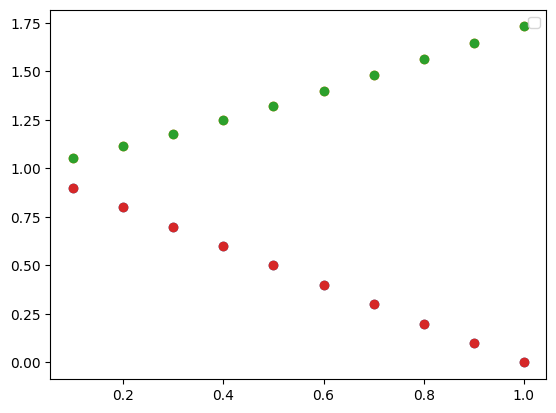

In [47]:
fig, ax = plt.subplots(1,1)
k = np.linspace(-np.pi,np.pi,4)
alphas = np.linspace(0.1,1,10)
eigenvalues = np.zeros((k.shape[0],alphas.shape[0],4))
for i in range(k.shape[0]):
    for j in range(alphas.shape[0]):
        eigvals, eigvecs = np.linalg.eig(Dmat(np.array([k[i],0,0]),alphas[j]))
        eigenvalues[i,j,:] = sorted(np.real(eigvals[:]))

for j in range(k.shape[0]):
    # ax.plot(k,eigenvalues[:,j,0],label=f'alpha={alphas[j]:.2f}')
    ax.scatter(alphas,np.sqrt(1+alphas**2+2*alphas*np.cos(k[j])))
    # ax.scatter(alphas,eigenvalues[j,:,1])
    # ax.scatter(alphas,eigenvalues[j,:,2])
    # ax.plot(k,eigenvalues[:,j,3],label=f'alpha={alphas[j]:.2f}')
ax.legend()
plt.show()

In [ ]:
# nearest neighbor dipole interaction with pbc

LATTICE_VECTOR_1 = np.array([1,0,0])
LATTICE_VECTOR_2 = 
a3 = np.array([-1/2,-np.sqrt(3)/2,0])
a = np.stack((LATTICE_VECTOR_1, LATTICE_VECTOR_2, a3))
d = 1
def mat_nn(i: int,j: int,k: np.ndarray) -> float:
    
    fij = 0 
    for ai in a:
        fnu =0
        if i==j:
            fnu += 3
            if i == 2:
                fnu += 6*d
        fnu -= ai[i] * ai[j]* 15
        fnu *= np.exp(1j* np.dot(ai,k))
        # fnu *= np.cos(np.dot(ai,k))
        fij += fnu
    return fij

def mat33(i: int,j: int,k: np.ndarray) -> float:
    
    fij = 0 
    for ai in a:
        fnu =0
        if i==j:
            fnu += 3
            if i == 2:
                fnu += 6*d
        fnu -= ai[i] * ai[j]* 15
        # fnu *= np.exp(1j* np.dot(ai,k))
        fnu *= np.cos(np.dot(ai,k))
        fij += fnu
    return fij

def mat_gradient(i: int,j: int,k: np.ndarray,axis: int) -> float:
    if np.all(k == 0):
        return 0
    fij = 0 
    for ai in a:
        fnu =0
        if i==j:
            fnu += 3
            if i == 2:
                fnu += 6*d
        fnu -= ai[i] * ai[j]* 15
        fnu *= 1j* ai[axis]* np.exp(1j* np.dot(ai,k))
        fij += fnu
    return fij

def D_mat_nn(k: np.ndarray) -> np.ndarray:
    """Calculate the D matrix for the given k vector."""
    dmat= np.zeros((6,6), dtype=complex)
    for i in range(6):
        for j in range(6):
            if i < 3 and j < 3:
               dmat[i, j] = -mat_nn(i, j, np.zeros(3))
            elif i >= 3 and j >= 3:
                dmat[i, j] = dmat[i-3, j-3]
            elif i < 3 and j >= 3:
                dmat[i, j] = mat_nn(i,j-3,k)
            elif i >= 3 and j < 3:
                dmat[i, j] = np.conjugate(mat_nn(i-3,j,k))
    return dmat

def D_mat33(k: np.ndarray) -> np.ndarray:
    """Calculate the D matrix for the given k vector."""
    dmat= np.zeros((3,3), dtype=complex)
    for i in range(3):
        for j in range(3):
               dmat[i, j] = -mat33(i, j, np.zeros(3))
               dmat[i,j] += mat33(i,j,k)
            
    return dmat

def D_mat_gradient(k: np.ndarray) -> np.ndarray:
    """Calculate the D matrix for the given k vector."""
    dmatx= np.zeros((6,6), dtype=complex)
    dmaty = np.zeros((6,6), dtype=complex)
    for i in range(6):
        for j in range(6):
            if i < 3 and j >= 3:
                dmatx[i, j] = mat_gradient(i,j-3,k,0)
                dmaty[i, j] = mat_gradient(i,j-3,k,1)
            elif i >= 3 and j < 3:
                dmatx[i, j] = np.conjugate(mat_gradient(i-3,j,k,0))
                dmaty[i, j] = np.conjugate(mat_gradient(i-3,j,k,1))
    return dmatx, dmaty
# ex = D_mat(np.array([1/2,1/2,0]))  # Example usage to compute D matrix for a specific k vector
# pd.DataFrame(ex, columns=[f'j{i}' for i in range(6)], index=[f'i{i}' for i in range(6)])  # Convert to DataFrame for better visualization
# for i in range(6):
#     for j in range(6):
#         print(f"{ex[i,j]:.2}", end='\t\t')
#     print()  # Print each row of the matrix on a new line


In [6]:
# periodic boundary condition used


def interaction_AA(i: int,j: int,k: np.ndarray, interaction: Callable[[], float], interaction_onsite: Callable[[], float],latticeA,latticeB,grid_size,interaction_cut) -> float:
    # print(lattices)
    R0 = latticeA[:, grid_size//2 ]
    total_potential_eq = 0
    total_potential_mixed = 0
    total_potential_eq_mixed = 0
    
    # lattice A and B have same shape
    for n in range(latticeA.shape[1]):
        
        
        Del_R_vecB = latticeB[:,n] - R0
        if i!=j:
            total_potential_eq_mixed -= interaction(Del_R_vecB,i,j,interaction_cut)
        if n == grid_size//2:
            continue
        Del_R_vec = latticeA[:,n] - R0
        potential = interaction(Del_R_vec,i,j,interaction_cut)
        total_potential_mixed += np.exp(-1j * np.dot(Del_R_vec, k))*potential
        if i!=j:
            total_potential_eq -= potential
           
    return (total_potential_eq+total_potential_mixed+ total_potential_eq_mixed+interaction_onsite(i,j))#, test

 

def interaction_AB(i,j,k, interaction,latticeA,latticeB,grid_size,interaction_cut):
    # print(latticeB)
    R0 = latticeA[:,grid_size//2]
    total_potential_mixed = 0
    for n in range(latticeB.shape[1]):
        
            
            Del_R_vec = latticeB[:,n] - R0
            
            total_potential_mixed += np.exp(-1j * np.dot(latticeA[:,n] - R0, k))*interaction(Del_R_vec,i,j,interaction_cut)

            # total_potential_mixed += np.exp(-1j * np.dot(Del_R_vec, k))*interaction(Del_R_vec,i,j,interaction_cut)
    # return 0
    return total_potential_mixed

def interaction_AA_alt(i: int,j: int,k: np.ndarray, interaction: Callable[[], float], interaction_onsite: Callable[[], float],latticeA,lattices,grid_size,interaction_cut) -> float:
    # print(lattices)
    R0 = latticeA[:, grid_size//2 ]
    total_potential_eq = 0
    total_potential_mixed = 0
    total_potential_eq_mixed = 0
    
    # lattice A and B have same shape
    for n in range(latticeA.shape[1]):
        
        for m in range(len(lattices)):  
            Del_R_vecB = lattices[m][:,n] - R0
            if i!=j:
                total_potential_eq_mixed -= interaction(Del_R_vecB,i,j,interaction_cut)
        if n == grid_size//2:
            continue
        Del_R_vec = latticeA[:,n] - R0
        potential = interaction(Del_R_vec,i,j,interaction_cut)
        total_potential_mixed += np.exp(-1j * np.dot(Del_R_vec, k))*potential
        if i!=j:
            total_potential_eq -= potential
           
    return (total_potential_eq+total_potential_mixed+ total_potential_eq_mixed+interaction_onsite(i,j))#, test

 


   

def D_mat(k: np.ndarray,angle,dist, interaction: Callable[[],float], interaction_onsite: Callable[[],float],grid_size,*interaction_cut) -> np.ndarray:
    """Calculate the D matrix for the given k vector."""
    latticeA = np.zeros((2,grid_size))
    latticeB = np.zeros((2,grid_size))
    a = 1
    displacement_vector = 2*(1+dist*np.cos(angle))*np.array([1,0])
    for n in range(latticeA.shape[1]//2):
        latticeA[:,2*n] = n*displacement_vector
        latticeA[:,2*n+1] = n*displacement_vector + (1+dist*np.cos(angle))*np.array([1,0])+dist*np.sin(angle)*np.array([0,1])

        latticeB[:,2*n] = n*displacement_vector + dist*np.cos(angle)*np.array([1,0])+ dist*np.sin(angle)*np.array([0,1])
        latticeB[:,2*n+1] = n*displacement_vector + (1+dist*2*np.cos(angle))*np.array([1,0])
    dmat= np.zeros((4,4), dtype=complex)
    if not interaction_cut:
        interaction_cut=[4/9*np.sqrt(3)*grid_size*10**2]
    for i in range(4):
        for j in range(4):
            if i < 2 and j < 2:      
                dmat[i, j] = interaction_AA(i, j, k,interaction,interaction_onsite,latticeA,latticeB,grid_size,*interaction_cut)
            elif i >= 2 and j >= 2:
                dmat[i, j] = interaction_AA(i-2, j-2, k,interaction,interaction_onsite,latticeB,latticeA,grid_size,*interaction_cut)
            elif i < 2 and j >= 2:
               
                dmat[i, j] = interaction_AB(i,j-2,k,interaction,latticeA,latticeB,grid_size,*interaction_cut)
            elif i >= 2 and j < 2:
                
                dmat[i, j] = interaction_AB(i-2,j,k,interaction,latticeB,latticeA,grid_size,*interaction_cut)

    return dmat

def D_mat_alternative_grid(k: np.ndarray,angle,dist, interaction: Callable[[],float], interaction_onsite: Callable[[],float],grid_size,*interaction_cut) -> np.ndarray:
    """Calculate the D matrix for the given k vector."""
    latticeA = np.zeros((2,grid_size))
    latticeB = np.zeros((2,grid_size))
    latticeC = np.zeros((2,grid_size))
    latticeD = np.zeros((2,grid_size))
    a = 1
    displacement_vector = 2*(1+dist*np.cos(angle))*np.array([1,0])
    for n in range(latticeA.shape[1]):
        latticeA[:,n] = n*displacement_vector
        latticeC[:,n] = n*displacement_vector + (1+dist*np.cos(angle))*np.array([1,0])+dist*np.sin(angle)*np.array([0,1])

        latticeB[:,n] = n*displacement_vector + dist*np.cos(angle)*np.array([1,0])+ dist*np.sin(angle)*np.array([0,1])
        latticeD[:,n] = n*displacement_vector + (1+dist*2*np.cos(angle))*np.array([1,0])
    dmat= np.zeros((8,8), dtype=complex)
    lattices = [latticeA,latticeC,latticeD,latticeB]
    # lattices = ['A','C','D','B']
    if not interaction_cut:
        interaction_cut=[4/9*np.sqrt(3)*grid_size*10**2]
    for n in range(len(lattices)):
        for m in range(len(lattices)):
            for i in range(2):
                for j in range(2):
                    if n==m:      
                        dmat[n*2+i,m*2+ j] = interaction_AA_alt(i, j, k,interaction,interaction_onsite,lattices[n],lattices[:n]+lattices[n+1:],grid_size,*interaction_cut)
                    # elif i >= 2 and j >= 2:
                    #     dmat[i, j] = interaction_AA(i-2, j-2, k,interaction,interaction_onsite,latticeB,latticeA,grid_size,*interaction_cut)
                    # elif i < 2 and j >= 2:
                    
                    #     dmat[i, j] = interaction_AB(i,j-2,k,interaction,latticeA,latticeB,grid_size,*interaction_cut)
                    # elif i >= 2 and j < 2:
                    else:                        
                        dmat[2*n+i,m*2+ j] = interaction_AB(i,j,k,interaction,lattices[n],lattices[m],grid_size,*interaction_cut)

    return dmat#, latticeA, latticeB, latticeC, latticeD

def D_mat_zig(k: np.ndarray,alpha,displace, interaction: Callable[[],float], interaction_onsite: Callable[[],float],grid_size,*interaction_cut) -> np.ndarray:
    """Calculate the D matrix for the given k vector."""
    latticeA = np.zeros((2,chain_length//2+chain_length%2))
    latticeB = np.zeros((2,chain_length//2))
    a = 1
    
    for n in range(latticeA.shape[1]):
        latticeA[:,n] = n*np.array([1,0])*(1+alpha)
    for n in range(latticeB.shape[1]):
        latticeB[:,n] = n*np.array([1,0])*(1+alpha) + alpha * np.array([1,0])+displace*np.array([0,1])
    dmat= np.zeros((4,4), dtype=complex)
    if not interaction_cut:
        interaction_cut=[max(np.sqrt(alpha**2+displace**2),1)]
    for i in range(4):
        for j in range(4):
            if i < 2 and j < 2:      
                dmat[i, j] = interaction_AA(i, j, k,interaction,interaction_onsite,latticeA,latticeB,grid_size//2,*interaction_cut)
            elif i >= 2 and j >= 2:
                dmat[i, j] = interaction_AA(i-2, j-2, k,interaction,interaction_onsite,latticeB,latticeA,grid_size//2,*interaction_cut)
            elif i < 2 and j >= 2:
               
                dmat[i, j] = interaction_AB(i,j-2,k,interaction,latticeA,latticeB,grid_size//2,*interaction_cut)
            elif i >= 2 and j < 2:
                
                dmat[i, j] = interaction_AB(i-2,j,k,interaction,latticeB,latticeA,grid_size//2,*interaction_cut)

    return dmat




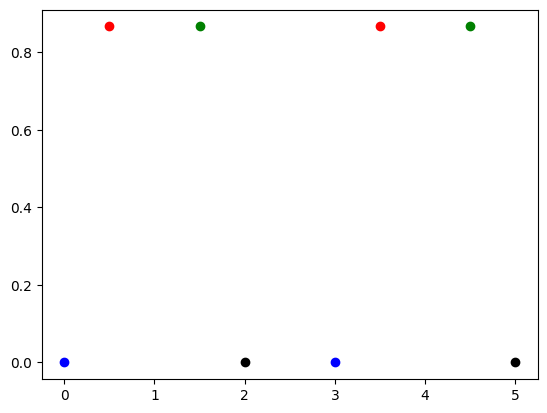

array([[  0.        +0.j        ,   6.49519053+0.j        ,
          0.        +0.j        ,   0.        +0.j        ,
         11.87990996-1.6934401j ,   0.        +0.j        ,
         -0.75      +0.j        ,  -6.49519053+0.j        ],
       [  6.49519053+0.j        ,   0.        +0.j        ,
          0.        +0.j        ,   0.        +0.j        ,
          0.        +0.j        ,  -2.96997749+0.42336002j,
         -6.49519053+0.j        ,  -8.25      +0.j        ],
       [  0.        +0.j        ,   0.        +0.j        ,
          0.        +0.j        ,  -6.49519053+0.j        ,
         -0.75      +0.j        ,   6.49519053+0.j        ,
        -12.        +0.j        ,   0.        +0.j        ],
       [  0.        +0.j        ,   0.        +0.j        ,
         -6.49519053+0.j        ,   0.        +0.j        ,
          6.49519053+0.j        ,  -8.25      +0.j        ,
          0.        +0.j        ,   3.        +0.j        ],
       [  0.        +0.j        ,   

In [60]:
dmat, latticeA, latticeB, latticeC, latticeD = D_mat_alternative_grid(np.array([1,0]),np.pi/3,1,bare_interaction,no_onsite_interaction,2,1)
fig, ax = plt.subplots(1,1)
ax.scatter(latticeA[0,:],latticeA[1,:],color='blue')
ax.scatter(latticeB[0,:],latticeB[1,:],color='red')
ax.scatter(latticeC[0,:],latticeC[1,:],color='green')
ax.scatter(latticeD[0,:],latticeD[1,:],color='0')
plt.show()
dmat

In [32]:
lattices = ['A','C','D','B']
lattices[:3]+lattices[4:]

['A', 'C', 'D']

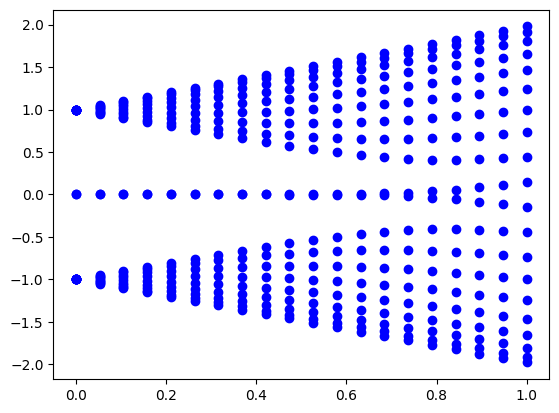

In [ ]:
# ssh model

def ssh(grid_size,v):
    mat = np.zeros([grid_size]*2)
    for i in range(grid_size):
        for j in range(grid_size):
            if np.abs(i-j)==1:
                if ((i+j)//2)%2:
                    mat[i,j] = 1
                else:
                    mat[i,j] = v
            
    return mat
ssh(4,0.5)
vs = np.linspace(0,1,20)
for i in range(vs.shape[0]):
    mat = ssh(20,vs[i])
    eigvals, eigvecs = np.linalg.eig(mat)
    plt.scatter([vs[i]]*eigvals.shape[0],sorted(np.real(eigvals[:])), color='blue')
plt.show()

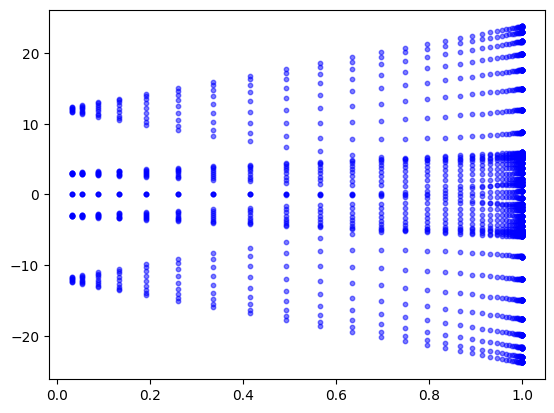

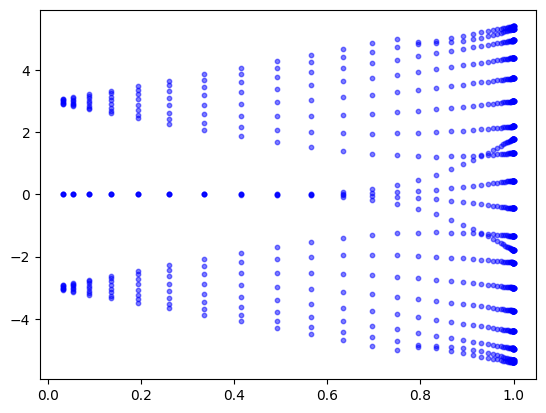

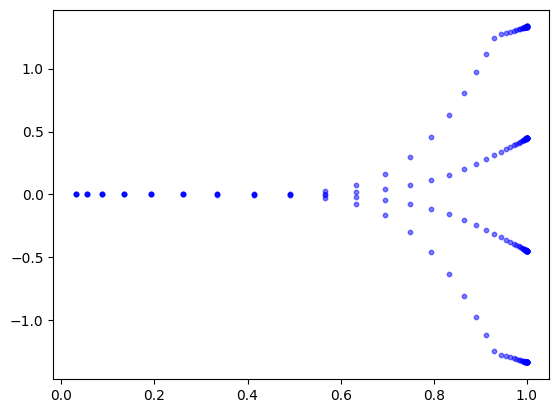

In [7]:
# open triangular lattice ssh implementation


def open_D_mat_triangular(alpha,displace,chain_length,interaction,onsite_interaction,*cut):
    latticeA = np.zeros((2,chain_length//2+chain_length%2))
    latticeB = np.zeros((2,chain_length//2))
    a = 1
    
    for n in range(latticeA.shape[1]):
        latticeA[:,n] = n*np.array([1,0])*(2+alpha)
    for n in range(latticeB.shape[1]):
        latticeB[:,n] = n*np.array([1,0])*(2+alpha) + (1+alpha) * np.array([1,0])+displace*np.array([0,1])
    
    # for n in range(latticeA.shape[1]):
    #     latticeA[:,n*2] = n*np.array([1,0])*(2+alpha)
        #np.array([frac*a*np.cos(alpha),frac*a*np.sin(alpha)])
    


    dmat = np.zeros((2*chain_length,2*chain_length),dtype=complex)
    if not cut:
        cut = [1+alpha]#[chain_length*10**6]
    for i in range(4):
        for j in range(4):
            if i <2 and j<2:
                for n in range(latticeA.shape[1]):
                    for m in range(latticeA.shape[1]):
                        # print(i*(latticeA.shape[1])+n,j*(latticeA.shape[1])+m)
                        if i!=j:
                            Del_R = latticeB[:,m]-latticeA[:,n]
                            dmat[i*(latticeA.shape[1])+n,j*(latticeA.shape[1])+n] -= interaction(Del_R,i,j,*cut)
                        if n==m:
                            dmat[i*(latticeA.shape[1])+n,j*(latticeA.shape[1])+m] += onsite_interaction(i,j)
                            continue
                        Del_R = latticeA[:,m]-latticeA[:,n]
                        dmat[i*(latticeA.shape[1])+n,j*(latticeA.shape[1])+m] += interaction(Del_R,i,j,*cut)
                        if i!=j:
                            dmat[i*(latticeA.shape[1])+n,j*(latticeA.shape[1])+n] -= interaction(Del_R,i,j,*cut)
                        
            if i >=2 and j>=2:
                for n in range(latticeB.shape[1]):
                    for m in range(latticeB.shape[1]):
                        # print(2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m)
                        if i!=j:
                            Del_R = latticeA[:,m]-latticeB[:,n]
                            dmat[2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+n] -= interaction(Del_R,i-2,j-2,*cut)
                        if n==m:
                            dmat[2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m] += onsite_interaction(i-2,j-2)
                            continue
                        Del_R = latticeB[:,m]-latticeB[:,n]
                        dmat[2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m] += interaction(Del_R,i-2,j-2,*cut)
                        if i!=j:
                            dmat[2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+n] -= interaction(Del_R,i-2,j-2,*cut)
                        
            if i <2 and j>=2:
                for n in range(latticeA.shape[1]):
                    for m in range(latticeB.shape[1]):
                        Del_R = latticeB[:,m]-latticeA[:,n]
                        dmat[i*(latticeA.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m] = interaction(Del_R,i,j-2,*cut)
                        # print(i*(latticeA.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m)
            if i >=2 and j<2:
                for n in range(latticeB.shape[1]):
                    for m in range(latticeA.shape[1]):
                        Del_R = latticeA[:,m]-latticeB[:,n]
                        dmat[2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,j*(latticeA.shape[1])+m] = interaction(Del_R,i-2,j,*cut)
                        # print(2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,j*(latticeA.shape[1])+m)
    return dmat, latticeA, latticeB, chain_length


# fig, ax = plt.subplots(1,1)
alphas = np.logspace(0, 5, base=1/10)
chain_length = 20
displacements = np.linspace(0,0.4,len(alphas))
eigenvals = np.zeros((len(alphas),2*chain_length,2*chain_length+1),dtype=complex)
# dmat, latticeA, latticeB, lattice_size = open_D_mat(7,bare_interaction_coulomb,bare_interaction_coulomb_onsite,100)
for i in range(len(alphas)):
  
    dmat, latticeA, latticeB, chain_length = open_D_mat_triangular(alphas[i],0,chain_length,bare_interaction,no_onsite_interaction)
    eig, vecs = np.linalg.eig(dmat)
    # eigenvals[i,:,0] = eig
    # eigenvals[i,:,1:] = vecs.T
    eigenvals[i] = sort_eigenvalues(eig,vecs)

    # ax.scatter(displacements[i]*np.ones(eig.shape[0]-36), sorted(np.real(eig))[18:-18], color='blue', s=10, alpha=0.5)
    # ax.scatter(1/(alphas[i]+1)**5*np.ones(eig.shape[0]), sorted(np.real(eig)), color='blue', s=10, alpha=0.5)
    # ax.scatter(1/(alphas[i]+1)**5*np.ones(eig.shape[0]-36), sorted(np.real(eig))[18:-18], color='blue', s=10, alpha=0.5)
fig , ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
fig3, ax3 = plt.subplots(1,1)
for i in range(eigenvals.shape[0]):
    ax.scatter(1/(alphas[i]+1)**5*np.ones(eig.shape[0]), sorted(np.real(eigenvals[i,:,0])), color='blue', s=10, alpha=0.5)
    ax2.scatter(1/(alphas[i]+1)**5*np.ones(eig.shape[0]-20), sorted(np.real(eigenvals[i,:,0]))[10:-10], color='blue', s=10, alpha=0.5)
    ax3.scatter(1/(alphas[i]+1)**5*np.ones(eig.shape[0]-36), sorted(np.real(eigenvals[i,:,0]))[18:-18], color='blue', s=10, alpha=0.5)
plt.show()


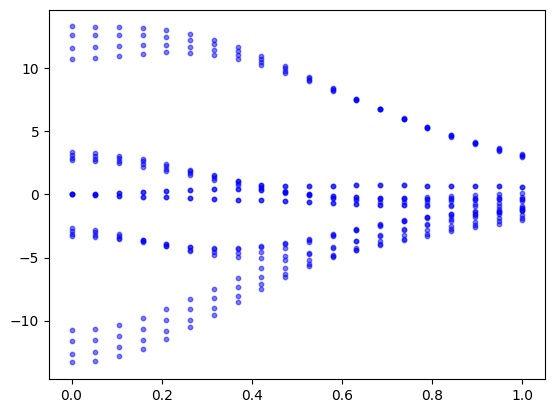

In [10]:
# open lattice consideration displacement


def open_D_mat_zig(alpha,displace,chain_length,interaction,onsite_interaction,*cut):
    latticeA = np.zeros((2,chain_length//2+chain_length%2))
    latticeB = np.zeros((2,chain_length//2))
    a = 1
    
    for n in range(latticeA.shape[1]):
        latticeA[:,n] = n*np.array([1,0])*(1+alpha)
    for n in range(latticeB.shape[1]):
        latticeB[:,n] = n*np.array([1,0])*(1+alpha) + alpha * np.array([1,0])+displace*np.array([0,1])
    
    # for n in range(latticeA.shape[1]):
    #     latticeA[:,n*2] = n*np.array([1,0])*(2+alpha)
        #np.array([frac*a*np.cos(alpha),frac*a*np.sin(alpha)])
    


    dmat = np.zeros((2*chain_length,2*chain_length),dtype=complex)
    if not cut:
        cut = [np.sqrt(alpha**2+displace**2)]#[chain_length*10**6]
    for i in range(4):
        for j in range(4):
            if i <2 and j<2:
                for n in range(latticeA.shape[1]):
                    for m in range(latticeA.shape[1]):
                        # print(i*(latticeA.shape[1])+n,j*(latticeA.shape[1])+m)
                        if i!=j:
                            Del_R = latticeB[:,m]-latticeA[:,n]
                            dmat[i*(latticeA.shape[1])+n,j*(latticeA.shape[1])+n] -= interaction(Del_R,i,j,*cut)
                        if n==m:
                            dmat[i*(latticeA.shape[1])+n,j*(latticeA.shape[1])+m] += onsite_interaction(i,j)
                            continue
                        Del_R = latticeA[:,m]-latticeA[:,n]
                        dmat[i*(latticeA.shape[1])+n,j*(latticeA.shape[1])+m] += interaction(Del_R,i,j,*cut)
                        if i!=j:
                            dmat[i*(latticeA.shape[1])+n,j*(latticeA.shape[1])+n] -= interaction(Del_R,i,j,*cut)
                        
            if i >=2 and j>=2:
                for n in range(latticeB.shape[1]):
                    for m in range(latticeB.shape[1]):
                        # print(2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m)
                        if i!=j:
                            Del_R = latticeA[:,m]-latticeB[:,n]
                            dmat[2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+n] -= interaction(Del_R,i-2,j-2,*cut)
                        if n==m:
                            dmat[2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m] += onsite_interaction(i-2,j-2)
                            continue
                        Del_R = latticeB[:,m]-latticeB[:,n]
                        dmat[2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m] += interaction(Del_R,i-2,j-2,*cut)
                        if i!=j:
                            dmat[2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+n] -= interaction(Del_R,i-2,j-2,*cut)
                        
            if i <2 and j>=2:
                for n in range(latticeA.shape[1]):
                    for m in range(latticeB.shape[1]):
                        Del_R = latticeB[:,m]-latticeA[:,n]
                        dmat[i*(latticeA.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m] = interaction(Del_R,i,j-2,*cut)
                        # print(i*(latticeA.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m)
            if i >=2 and j<2:
                for n in range(latticeB.shape[1]):
                    for m in range(latticeA.shape[1]):
                        Del_R = latticeA[:,m]-latticeB[:,n]
                        dmat[2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,j*(latticeA.shape[1])+m] = interaction(Del_R,i-2,j,*cut)
                        # print(2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,j*(latticeA.shape[1])+m)
    return dmat, latticeA, latticeB, chain_length

fig, ax = plt.subplots(1,1)
# alphas = np.logspace(0, 5, base=1/10)
alphas =0.95+1/ np.logspace(0,1.9,base=10,num=20)

chain_length = 10
displacements = np.linspace(0,1,len(alphas))
eigenvals = np.zeros((len(alphas),2*chain_length,2*chain_length+1),dtype=complex)
# dmat, latticeA, latticeB, lattice_size = open_D_mat(7,bare_interaction_coulomb,bare_interaction_coulomb_onsite,100)
for i in range(len(alphas)):
    # dmat, latticeA, latticeB, chain_length = open_D_mat(alphas[i],0,chain_length,bare_interaction,no_onsite_interaction)
    dmat, latticeA, latticeB, chain_length = open_D_mat_zig(1.5,displacements[i],chain_length,bare_interaction,no_onsite_interaction)
    eig, vecs = np.linalg.eig(dmat)
    eigenvals[i,:,0] = eig
    eigenvals[i,:,1:] = vecs.T
    ax.scatter(displacements[i]*np.ones(eig.shape[0]), sorted(np.real(eig)), color='blue', s=10, alpha=0.5)
    # ax.scatter(1/alphas[i]**5*np.ones(eig.shape[0])*np.ones(eig.shape[0]), sorted(np.real(eig)), color='blue', s=10, alpha=0.5)
    
    # ax.scatter(1/(alphas[i]+1)**5*np.ones(eig.shape[0]-36), sorted(np.real(eig))[18:-18], color='blue', s=10, alpha=0.5)
plt.show()


TypeError: only length-1 arrays can be converted to Python scalars

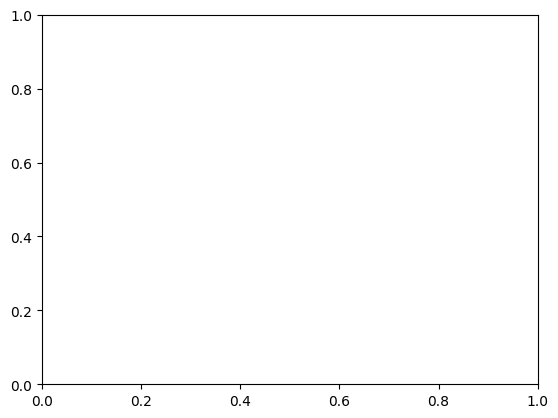

In [ ]:
fig, ax1 = plt.subplots(1,1)
# fig, ax2 = plt.subplots(1,1)
# alphas = np.logspace(0, 1, base=10)
chain_length = 10
angles = np.linspace(0,np.pi/2,20)
# angles = np.linspace(0,0.3,20)
eigenvals_diag = np.zeros((len(angles),4*chain_length,4*chain_length+1),dtype=complex)
eigenvals_off = np.zeros_like(eigenvals_diag)
for i in range(len(angles)):
  
    dmat, latticeA, latticeB, chain_length = D_mat_zig(1,angles[i],chain_length,bare_interaction,no_onsite_interaction,1)
    # print(np.any(np.abs(dmat-np.conjugate(dmat.T))>11/10**12))
    dmat_diag = np.zeros_like(dmat)
    dmat_diag[:2*chain_length,:2*chain_length] = dmat[:2*chain_length,:2*chain_length]
    dmat_diag[2*chain_length:,2*chain_length:] = dmat[2*chain_length:,2*chain_length:]
    dmat_off = np.zeros_like(dmat)
    dmat_off[2*chain_length:,:2*chain_length] = dmat[2*chain_length:,:2*chain_length]
    dmat_off[:2*chain_length,2*chain_length:] = dmat[:2*chain_length,2*chain_length:]

    eig_diag, vecs_diag = np.linalg.eig(dmat_diag)
    eigenvals_diag[i]= sort_eigenvalues(eig_diag,vecs_diag)
    eig_off, vecs_off = np.linalg.eig(dmat_off)
    eigenvals_off[i]= sort_eigenvalues(eig_off,vecs_off)
    # ax.scatter(1/alphas[i]**5*np.ones(eig.shape[0]-36), sorted(np.real(eig))[18:-18], color='blue', s=10, alpha=0.5)
    # ax.scatter(angles[i]/np.pi*180*np.ones(eig.shape[0]-36), sorted(np.real(eig))[18:-18], color='blue', s=10, alpha=0.5)
    ax1.scatter(angles[i]/np.pi*180*np.ones(eig_diag.shape[0]), sorted(np.real(eig_diag))[:], color='blue', s=10, alpha=0.5)
    ax1.scatter(angles[i]/np.pi*180*np.ones(eig_off.shape[0]), sorted(np.real(eig_off))[:], color='red', s=10, alpha=0.5)

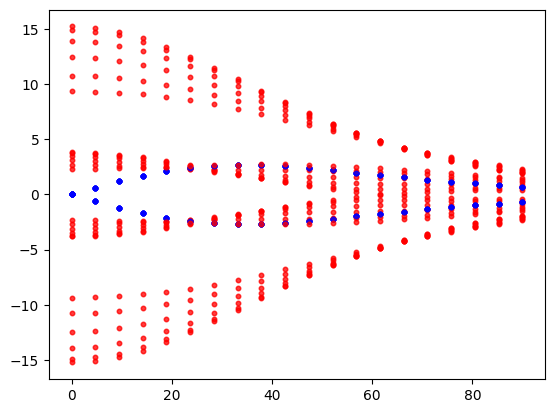

In [9]:
# periodic boundary consideration of zig_zag displacement

fig, ax1 = plt.subplots(1,1)
# fig, ax2 = plt.subplots(1,1)
# alphas = np.logspace(0, 1, base=10)
chain_length = 12
size = 2
angles = np.linspace(0,np.pi/2,20)
displacements = np.linspace(0,1,len(alphas))
eigenvals_diag = np.zeros((len(displacements),size*chain_length,4+1),dtype=complex)
eigenvals_off = np.zeros_like(eigenvals_diag)
alpha = 1.3
for i in range(len(angles)):
    for j in range(chain_length//2):
        # for l in range(chain_length//2):
            4*np.pi/np.sqrt(3)#*np.array([1,0])#
            k = j/(chain_length//2)*np.pi/(1+alpha)
            dmat= D_mat_zig(np.array([k,0]),alpha,displacements[i],bare_interaction,no_onsite_interaction,chain_length)
            # dmat= D_mat_zig(np.array([k,0]),alphas[i],0,bare_interaction,no_onsite_interaction,chain_length)
    
            dmat_diag = np.zeros_like(dmat)
            dmat_diag[:size,:size] = dmat[:size,:size]
            dmat_diag[size:,size:] = dmat[size:,size:]
            dmat_off = np.zeros_like(dmat)
            dmat_off[size:,:size] = dmat[size:,:size]
            dmat_off[:size,size:] = dmat[:size,size:]

            eig_diag, vecs_diag = np.linalg.eig(dmat_diag)
            eigenvals_diag[i,j*size*2:(j+1)*size*2]= sort_eigenvalues(eig_diag,vecs_diag)
            eig_off, vecs_off = np.linalg.eig(dmat_off)
            eigenvals_off[i,j*size*2:(j+1)*size*2]= sort_eigenvalues(eig_off,vecs_off)
            # ax.scatter(1/alphas[i]**5*np.ones(eig.shape[0]-36), sorted(np.real(eig))[18:-18], color='blue', s=10, alpha=0.5)
            # ax.scatter(angles[i]/np.pi*180*np.ones(eig.shape[0]-36), sorted(np.real(eig))[18:-18], color='blue', s=10, alpha=0.5)
            ax1.scatter(angles[i]/np.pi*180*np.ones(eig_diag.shape[0]), sorted(np.real(eig_diag))[:], color='blue', s=10, alpha=0.5)
            ax1.scatter(angles[i]/np.pi*180*np.ones(eig_off.shape[0]), sorted(np.abs(eig_off))[:], color='red', s=10, alpha=0.5)
            ax1.scatter(angles[i]/np.pi*180*np.ones(eig_off.shape[0]), sorted(-np.abs(eig_off))[:], color='red', s=10, alpha=0.5)
            

# sep_eng = find_separate(eigenvals[:,:,0])
# ax.scatter(angles/np.pi*180,sep_eng,color='0')


# ax.vlines(60,np.min(eigenvals[:,18:-18,0]),np.max(eigenvals[:,18:-18,0]), colors='red', linestyles='dashed')
plt.show()

0.26298487836949375
0.3286575237879356
0.40009184107157725
0.47484634739297527
0.550238738236458
0.6237008485057528
0.6930707414468753
0.756767073472157
0.8138361449174429
0.8638974788819591
0.9070294784580498
0.9436348609510109
0.9743141870854884
0.9997625955535637
1.0206943163775104
1.0377930225452199
1.051683072025618
1.0629160286795283
1.071967434948376
1.079239872023765


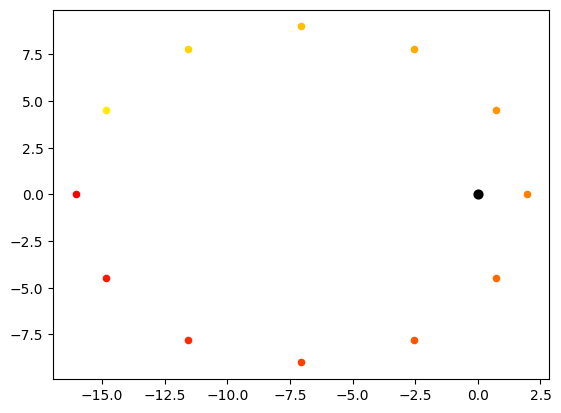

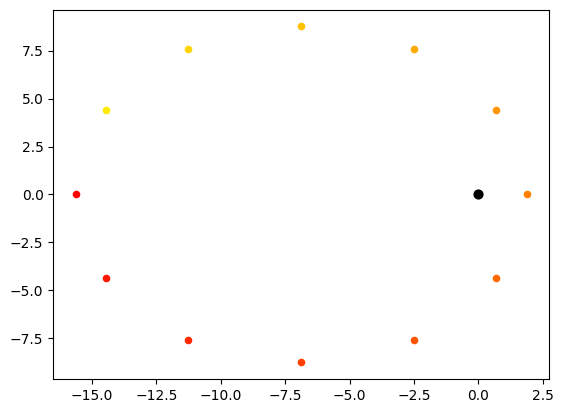

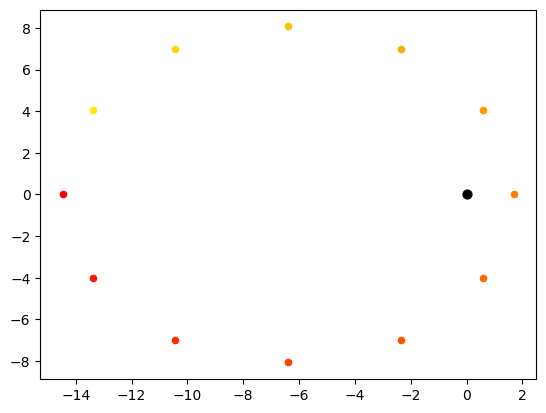

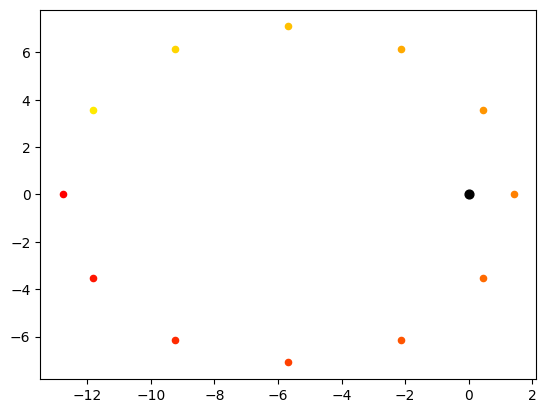

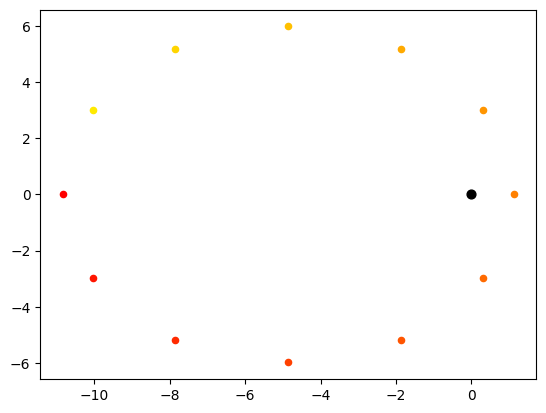

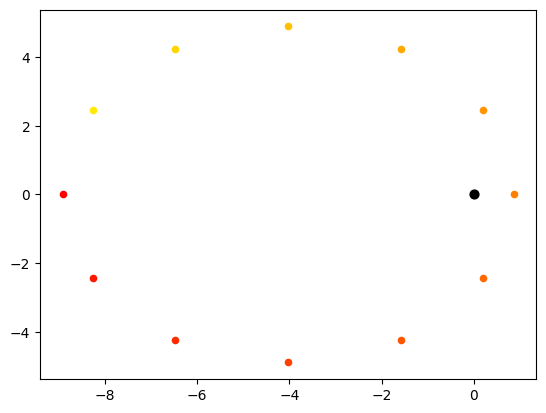

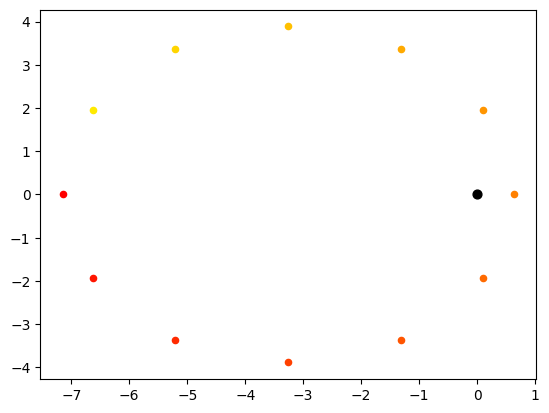

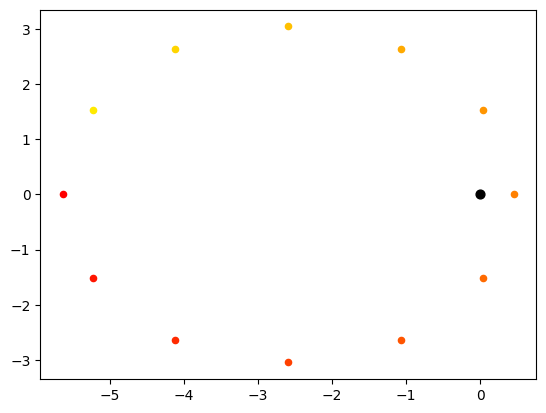

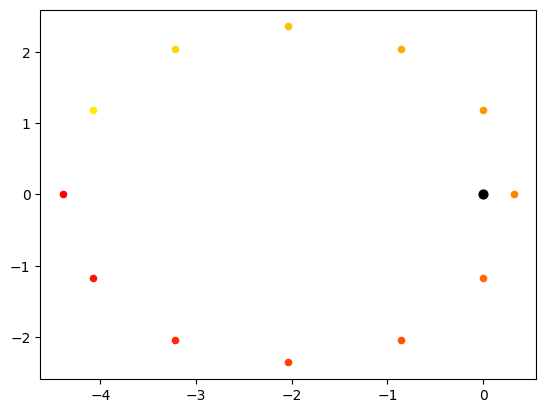

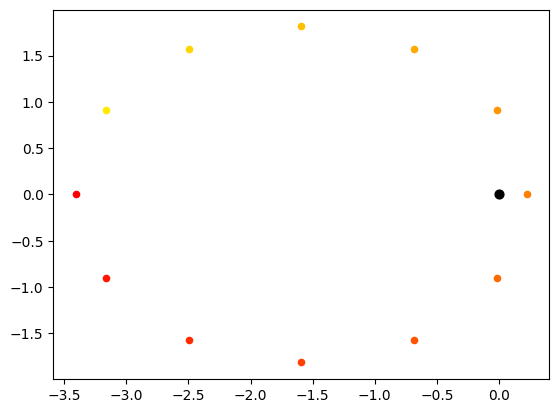

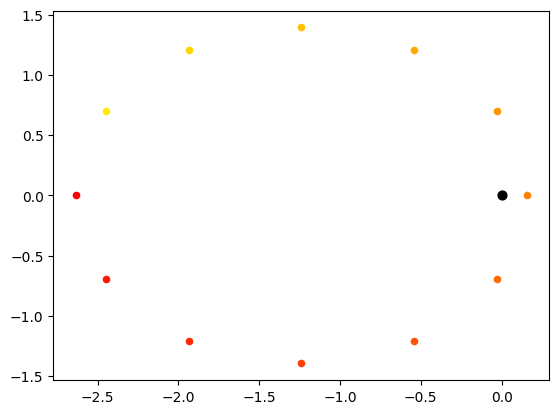

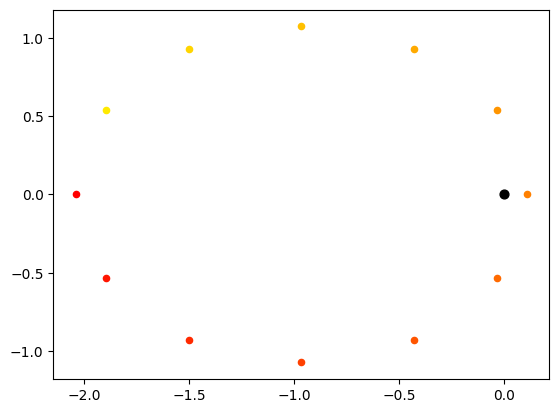

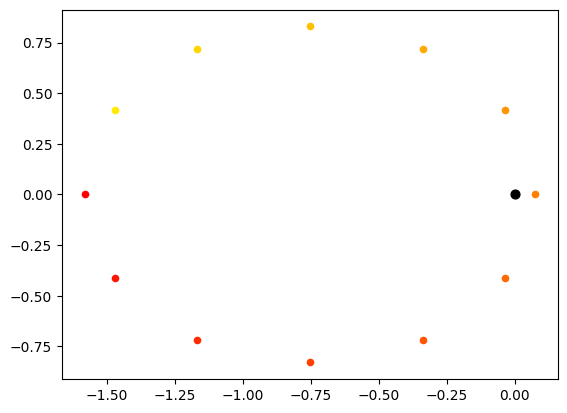

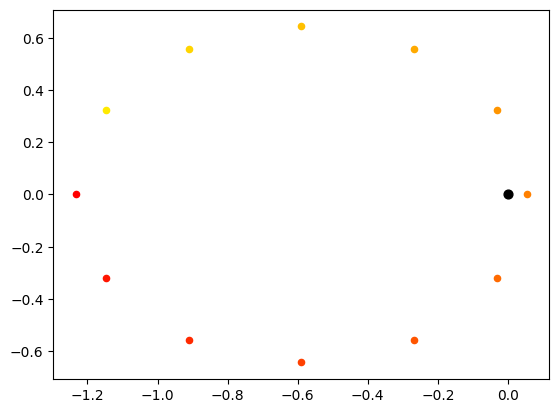

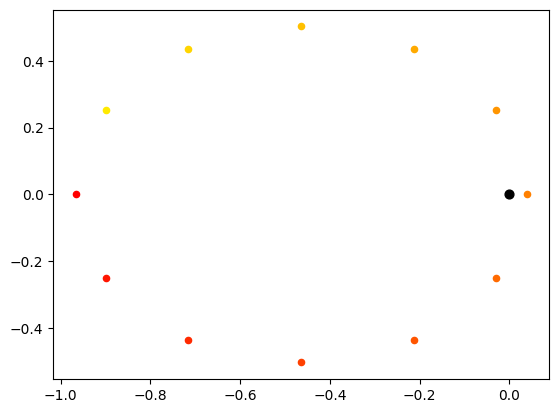

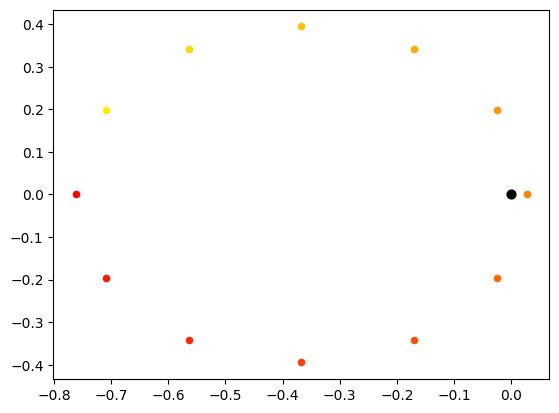

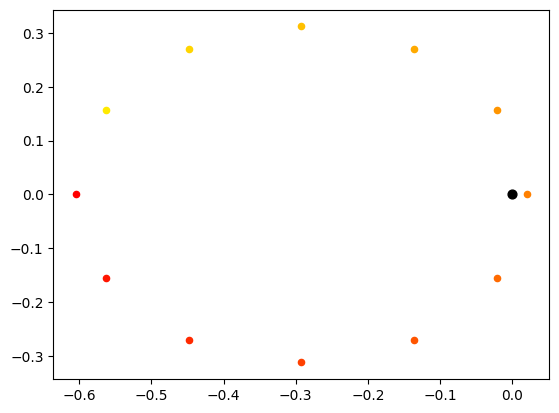

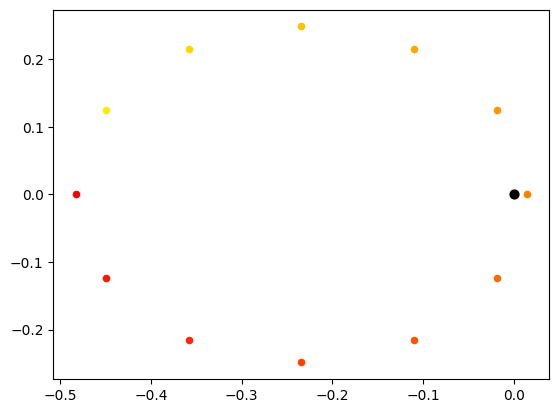

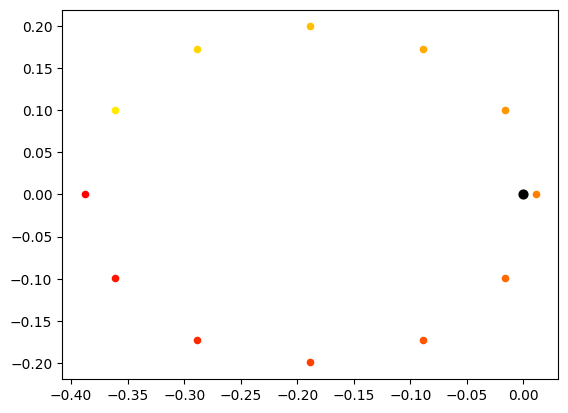

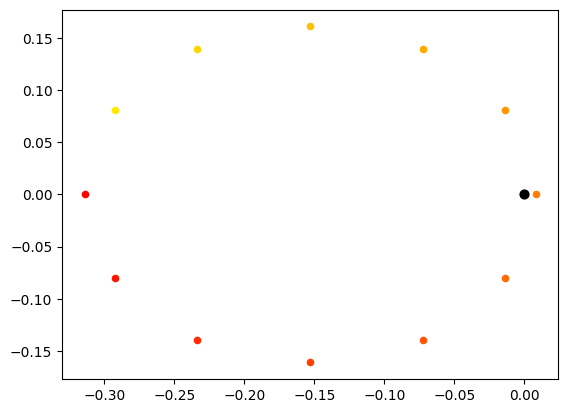

In [ ]:
# winding number of zig_zag displacement

chain_length = 12
size = 2
from matplotlib import colormaps
# fig2, ax2 = plt.subplots(1,1)
cmap = colormaps['autumn']#['viridis']
# angles = np.linspace(0,np.pi/2-0.1,15)
# angles = np.linspace(0,0.3,20)
alphas =0.95+1/ np.logspace(0,1.9,base=10,num=20)
displacements = np.linspace(0,2,len(alphas))
eigenvals_diag = np.zeros((len(alphas),2*chain_length,2+1),dtype=complex)
eigenvals_off = np.zeros_like(eigenvals_diag)
for i in range(len(alphas)):
    # fig, ax1 = plt.subplots(2,2,figsize=(15,15))
    print(1/alphas[i]**2)
    fig, ax1 = plt.subplots(1,1)
    ax1.scatter(0,0,s=40,color='0')
    # ax1.set_xlim(-7,10)
    for j in range(chain_length):
        # for l in range(chain_length//2):
            4*np.pi/np.sqrt(3)#*np.array([1,0])#
            k = j/(chain_length//2)*np.pi/(1+1.05)
            # dmat= D_mat_zig(np.array([k,0]),alphas[i],0,bare_interaction,no_onsite_interaction,chain_length)
            dmat= D_mat_zig(np.array([k,0]),1.05,displacements[i],bare_interaction,no_onsite_interaction,chain_length)

            dmat_diag = dmat[:2,:2]
            
            dmat_off = dmat[:2,2:]

            eig_diag, vecs_diag = np.linalg.eig(dmat_diag)
            eigenvals_diag[i,j*size:(j+1)*size]= sort_eigenvalues(eig_diag,vecs_diag)
            eig_off, vecs_off = np.linalg.eig(dmat_off)
            eigenvals_off[i,j*size:(j+1)*size]= sort_eigenvalues(eig_off,vecs_off)
            # ax2.scatter(angles[i]*np.ones(),np.real(eigenvals_off[i,:,0]),color='blue',s=20)
            # ax1.scatter(np.real(eigenvals_off[i,j*size:(j+1)*size,0]),np.imag(eigenvals_off[i,j*size:(j+1)*size,0]),color=cmap(j/chain_length),s=20)
            ax1.scatter(np.sum(np.real(eigenvals_off[i,j*size:(j+1)*size,0])),np.sum(np.imag(eigenvals_off[i,j*size:(j+1)*size,0])),color=cmap(j/chain_length),s=20)
    plt.show
    # ax2.scatter(displacements[i]*np.ones(eigenvals_off.shape[1]),eigenvals_off[i,:,0],color='red',alpha=0.5)
    # ax2.scatter(displacements[i]*np.ones(eigenvals_off.shape[1]),eigenvals_diag[i,:,0],color='blue',alpha=0.5)
     

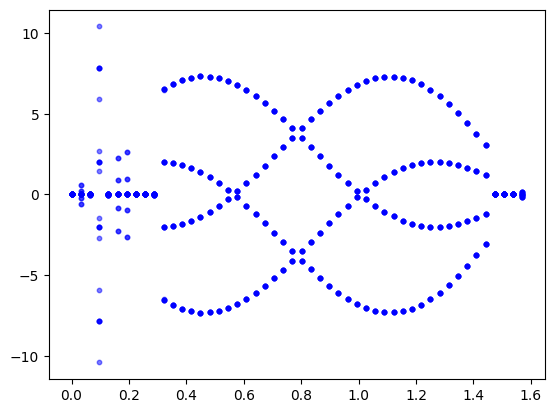

In [20]:
# open lattice consideration of chiral zig_zag displacement 

fig, ax = plt.subplots(1,1)
# alphas = np.logspace(0, 5, base=1/10)
phi = np.linspace(0,np.pi/2)

chain_length = 12
r = 1.05
eigenvals = np.zeros((len(phi),2*chain_length,2*chain_length+1),dtype=complex)
# dmat, latticeA, latticeB, lattice_size = open_D_mat(7,bare_interaction_coulomb,bare_interaction_coulomb_onsite,100)
for i in range(len(phi)):
    # dmat, latticeA, latticeB, chain_length = open_D_mat(alphas[i],0,chain_length,bare_interaction,no_onsite_interaction)
    dmat, latticeA, latticeB, chain_length = open_D_mat_zig(r*np.cos(phi[i]),r*np.sin(phi[i]),chain_length,interaction_rotated,no_onsite_interaction)
    eig, vecs = np.linalg.eig(dmat)
    eigenvals[i,:,0] = eig
    eigenvals[i,:,1:] = vecs.T
    ax.scatter(phi[i]*np.ones(eig.shape[0]), sorted(np.real(eig)), color='blue', s=10, alpha=0.5)
    # ax.scatter(1/alphas[i]**5*np.ones(eig.shape[0])*np.ones(eig.shape[0]), sorted(np.real(eig)), color='blue', s=10, alpha=0.5)
    
    # ax.scatter(1/(alphas[i]+1)**5*np.ones(eig.shape[0]-36), sorted(np.real(eig))[18:-18], color='blue', s=10, alpha=0.5)
plt.show()

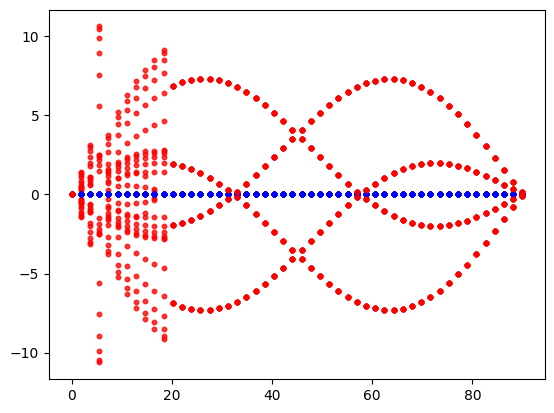

In [18]:
# periodic boundary consideration of chiral zig_zag displacement 

fig, ax1 = plt.subplots(1,1)
# fig, ax2 = plt.subplots(1,1)
# alphas = np.logspace(0, 1, base=10)
chain_length = 12
size = 2
phi = np.linspace(0,np.pi/2)



eigenvals_diag = np.zeros((len(phi),size*chain_length,4+1),dtype=complex)
eigenvals_off = np.zeros_like(eigenvals_diag)
alpha = 1.3
for i in range(len(phi)):
    for j in range(chain_length//2):
        # for l in range(chain_length//2):
            4*np.pi/np.sqrt(3)#*np.array([1,0])#
            k = j/(chain_length//2)*np.pi/(1+np.cos(phi[i])*r)
            dmat= D_mat_zig(np.array([k,0]),r*np.cos(phi[i]),r*np.sin(phi[i]),interaction_rotated,no_onsite_interaction,chain_length)
            # dmat= D_mat_zig(np.array([k,0]),alphas[i],0,bare_interaction,no_onsite_interaction,chain_length)
    
            dmat_diag = np.zeros_like(dmat)
            dmat_diag[:size,:size] = dmat[:size,:size]
            dmat_diag[size:,size:] = dmat[size:,size:]
            dmat_off = np.zeros_like(dmat)
            dmat_off[size:,:size] = dmat[size:,:size]
            dmat_off[:size,size:] = dmat[:size,size:]

            eig_diag, vecs_diag = np.linalg.eig(dmat_diag)
            eigenvals_diag[i,j*size*2:(j+1)*size*2]= sort_eigenvalues(eig_diag,vecs_diag)
            eig_off, vecs_off = np.linalg.eig(dmat_off)
            eigenvals_off[i,j*size*2:(j+1)*size*2]= sort_eigenvalues(eig_off,vecs_off)
            # ax.scatter(1/alphas[i]**5*np.ones(eig.shape[0]-36), sorted(np.real(eig))[18:-18], color='blue', s=10, alpha=0.5)
            # ax.scatter(angles[i]/np.pi*180*np.ones(eig.shape[0]-36), sorted(np.real(eig))[18:-18], color='blue', s=10, alpha=0.5)
            ax1.scatter(phi[i]/np.pi*180*np.ones(eig_diag.shape[0]), sorted(np.real(eig_diag))[:], color='blue', s=10, alpha=0.5)
            ax1.scatter(phi[i]/np.pi*180*np.ones(eig_off.shape[0]), sorted(np.abs(eig_off))[:], color='red', s=10, alpha=0.5)
            ax1.scatter(phi[i]/np.pi*180*np.ones(eig_off.shape[0]), sorted(-np.abs(eig_off))[:], color='red', s=10, alpha=0.5)

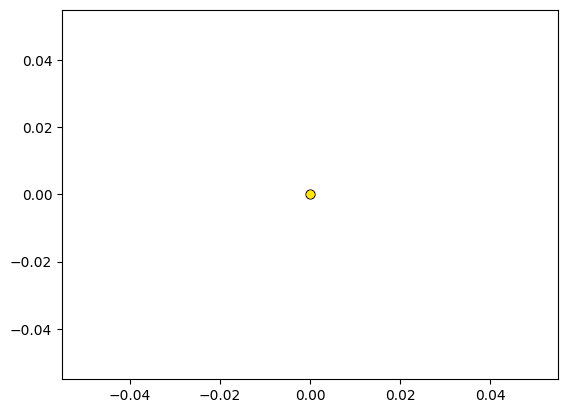

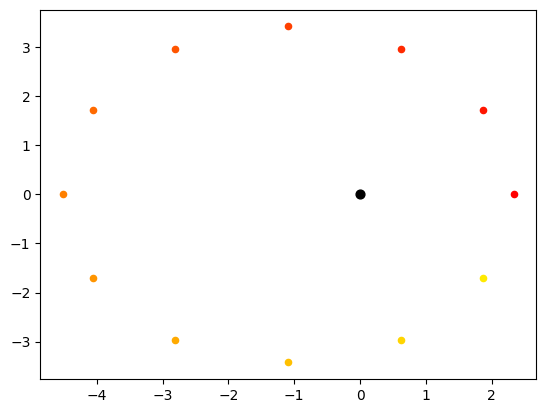

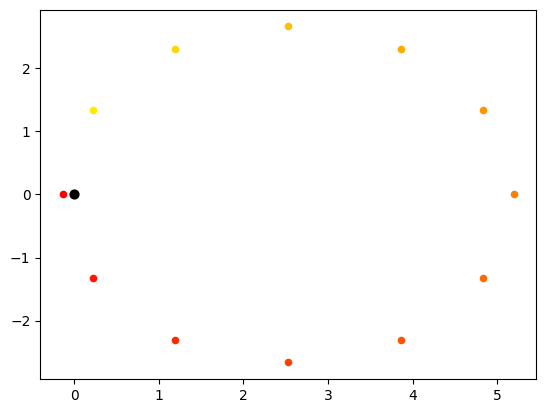

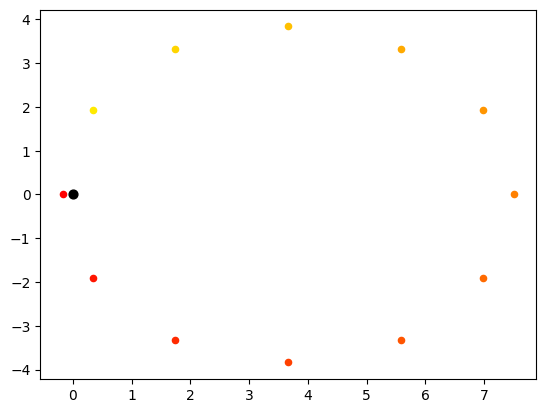

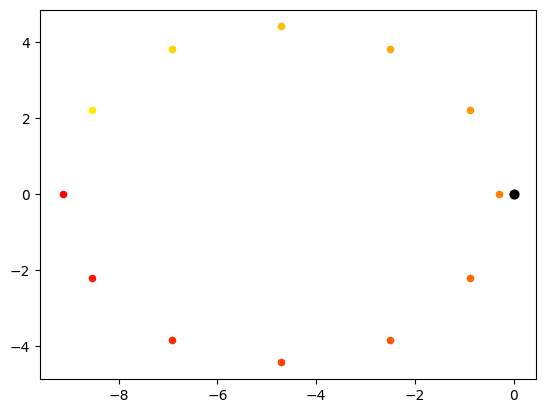

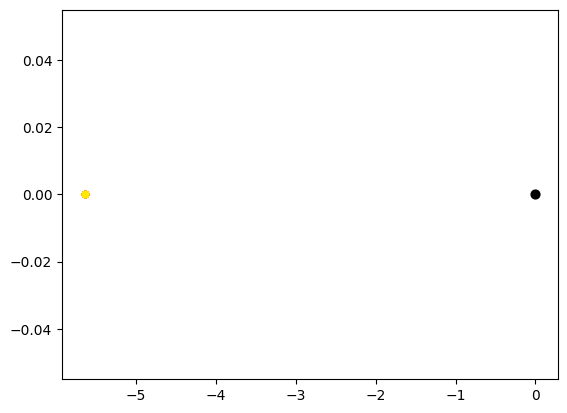

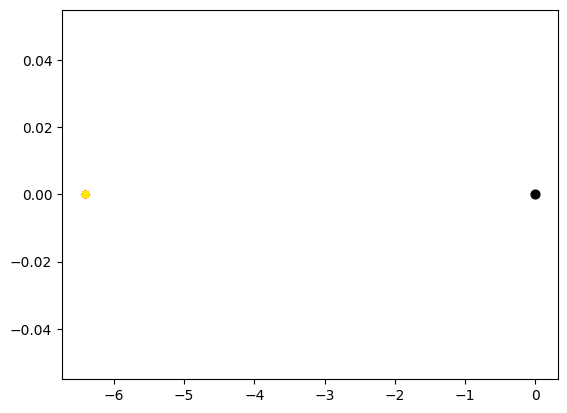

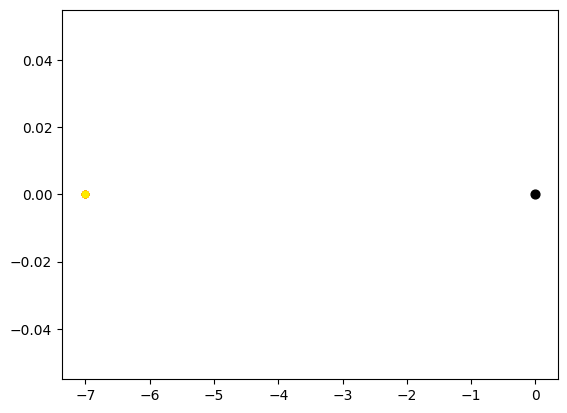

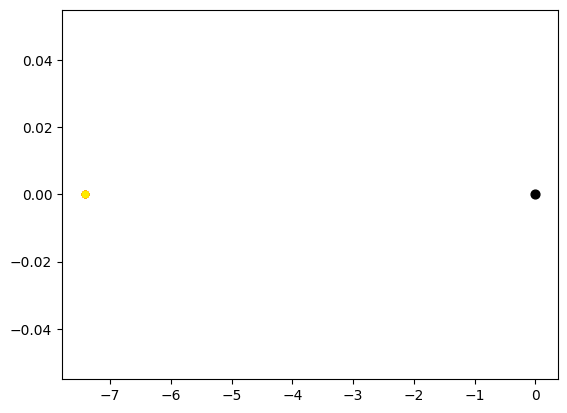

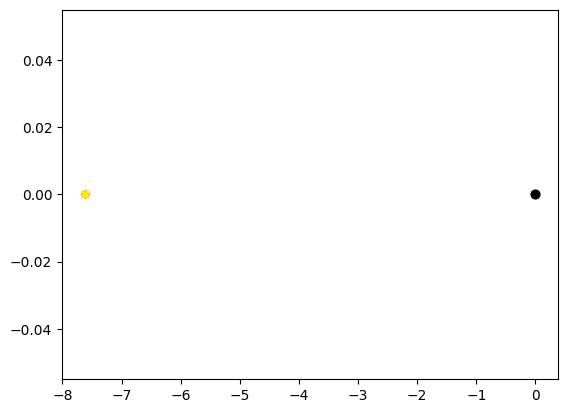

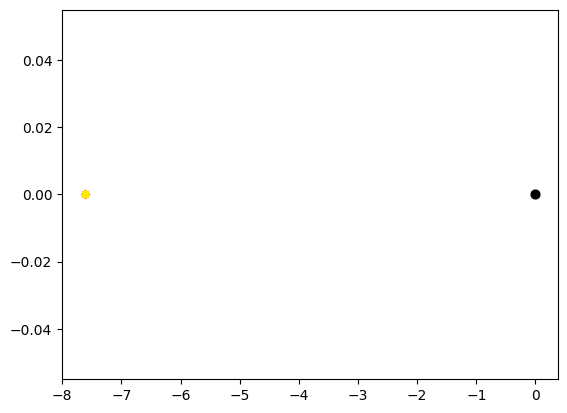

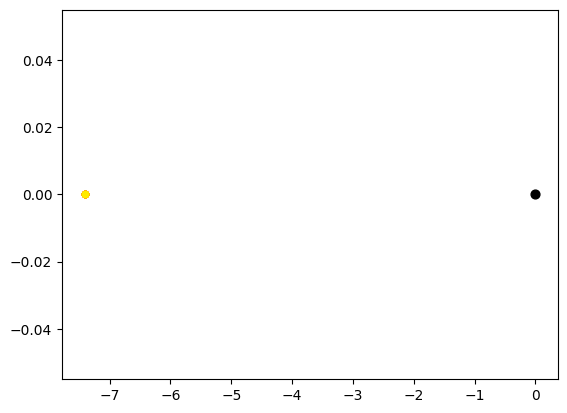

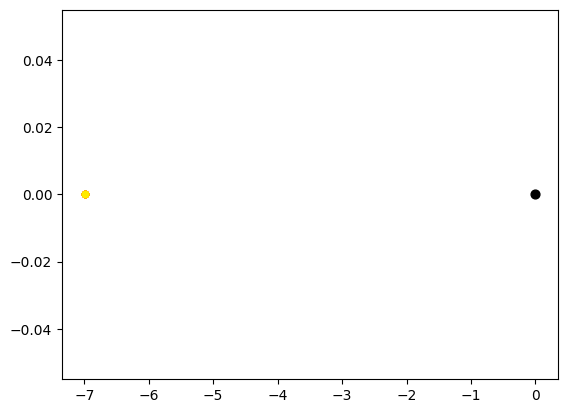

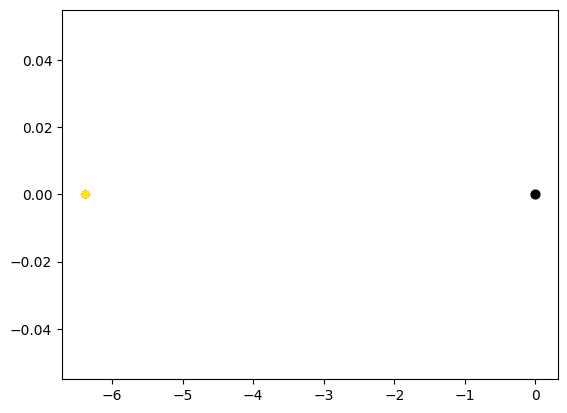

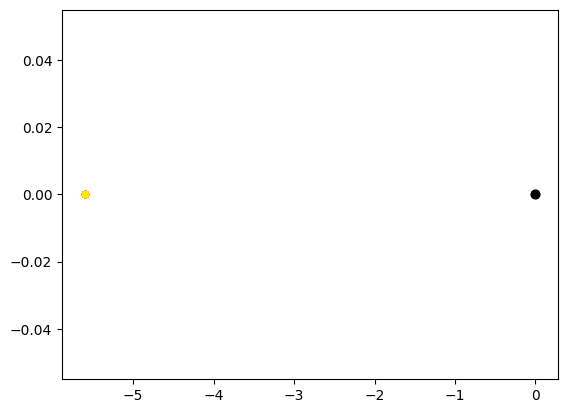

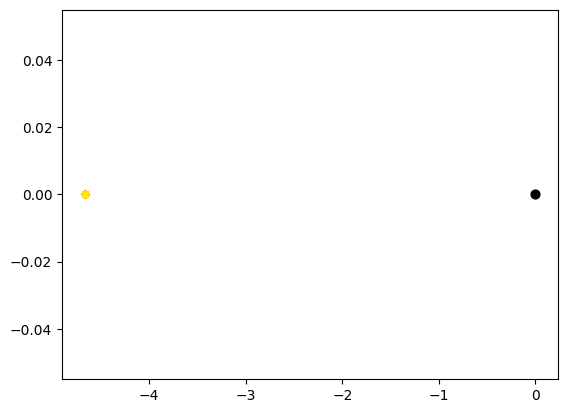

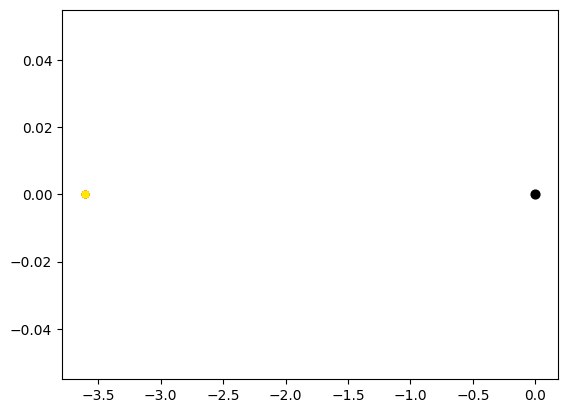

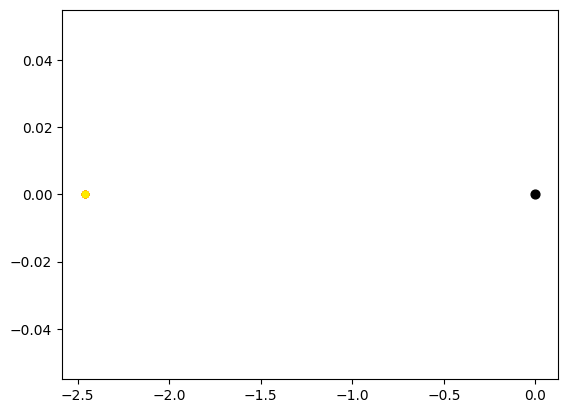

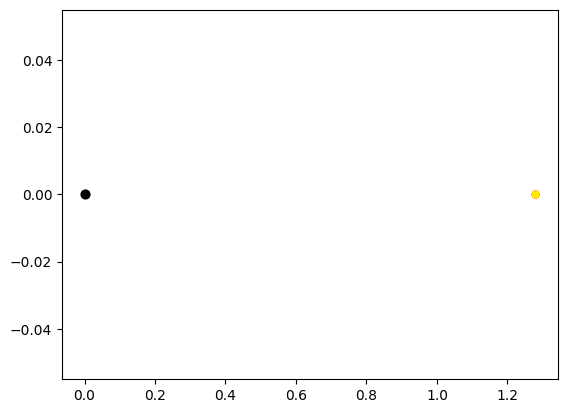

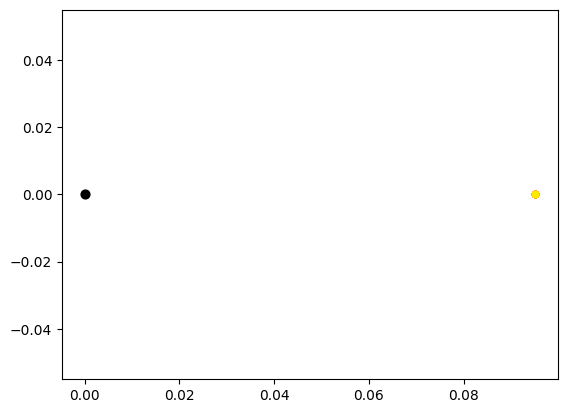

In [19]:
# winding number of zig_zag displacement

chain_length = 12
size = 2
from matplotlib import colormaps
# fig2, ax2 = plt.subplots(1,1)
cmap = colormaps['autumn']#['viridis']
# angles = np.linspace(0,np.pi/2-0.1,15)
# angles = np.linspace(0,0.3,20)
phi = np.linspace(0,np.pi/2,20)
eigenvals_diag = np.zeros((len(phi),2*chain_length,2+1),dtype=complex)
eigenvals_off = np.zeros_like(eigenvals_diag)
for i in range(len(phi)):
    # fig, ax1 = plt.subplots(2,2,figsize=(15,15))
    
    fig, ax1 = plt.subplots(1,1)
    ax1.scatter(0,0,s=40,color='0')
    # ax1.set_xlim(-7,10)
    for j in range(chain_length):
        # for l in range(chain_length//2):
            4*np.pi/np.sqrt(3)#*np.array([1,0])#
            k = j/(chain_length//2)*np.pi/(1+np.cos(phi[i])*r)
            # dmat= D_mat_zig(np.array([k,0]),alphas[i],0,bare_interaction,no_onsite_interaction,chain_length)
            dmat= D_mat_zig(np.array([k,0]),r*np.cos(phi[i]),r*np.sin(phi[i]),interaction_rotated,no_onsite_interaction,chain_length)

            dmat_diag = dmat[:2,:2]
            
            dmat_off = dmat[:2,2:]

            eig_diag, vecs_diag = np.linalg.eig(dmat_diag)
            eigenvals_diag[i,j*size:(j+1)*size]= sort_eigenvalues(eig_diag,vecs_diag)
            eig_off, vecs_off = np.linalg.eig(dmat_off)
            eigenvals_off[i,j*size:(j+1)*size]= sort_eigenvalues(eig_off,vecs_off)
            # ax2.scatter(angles[i]*np.ones(),np.real(eigenvals_off[i,:,0]),color='blue',s=20)
            # ax1.scatter(np.real(eigenvals_off[i,j*size:(j+1)*size,0]),np.imag(eigenvals_off[i,j*size:(j+1)*size,0]),color=cmap(j/chain_length),s=20)
            ax1.scatter(np.sum(np.real(eigenvals_off[i,j*size:(j+1)*size,0])),np.sum(np.imag(eigenvals_off[i,j*size:(j+1)*size,0])),color=cmap(j/chain_length),s=20)
    plt.show

In [102]:
dmat, Trash, tt, trah = open_D_mat(0.2,0.14,2,bare_interaction,no_onsite_interaction)
np.real(dmat)

array([[ 0.        ,  0.670783  , -4.58400327, -0.670783  ],
       [ 0.670783  ,  0.        , -0.670783  ,  1.08730731],
       [-4.58400327, -0.670783  ,  0.        ,  0.670783  ],
       [-0.670783  ,  1.08730731,  0.670783  ,  0.        ]])

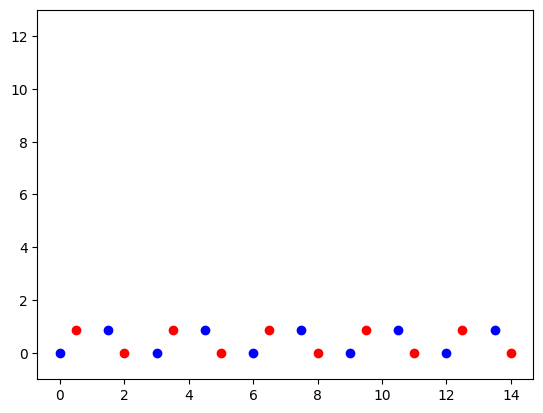

In [9]:
fig, ax = plt.subplots(1,1)
chain_length = 10
dist = 1
angle = np.pi/3
llatticeA = np.zeros((2,chain_length))
latticeB = np.zeros((2,chain_length))
a = 1
displacement_vector = 2*(1+dist*np.cos(angle))*np.array([1,0])
for n in range(latticeA.shape[1]//2):
    latticeA[:,2*n] = n*displacement_vector
    latticeA[:,2*n+1] = n*displacement_vector + (1+dist*np.cos(angle))*np.array([1,0])+dist*np.sin(angle)*np.array([0,1])

    latticeB[:,2*n] = n*displacement_vector + dist*np.cos(angle)*np.array([1,0])+ dist*np.sin(angle)*np.array([0,1])
    latticeB[:,2*n+1] = n*displacement_vector + (1+dist*2*np.cos(angle))*np.array([1,0])
for n in range(latticeA.shape[1]):
    ax.scatter(latticeA[0,n],latticeA[1,n], color='blue')
    ax.scatter(latticeB[0,n],latticeB[1,n], color='red')
ax.set_ylim(-1,13)
plt.show()

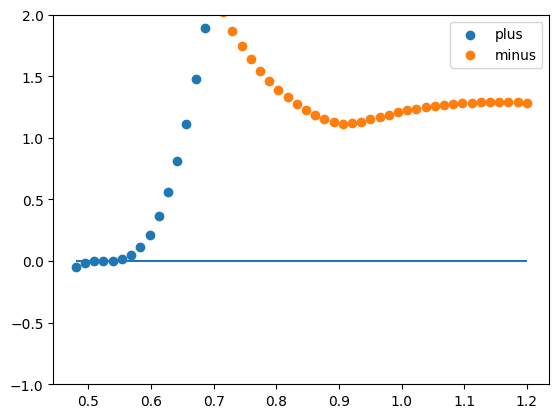

In [40]:
fig, ax = plt.subplots(1,1)
x = np.linspace(0.48,1.2)
def func(x,alpha):
    R1 = np.sqrt(alpha**2+x**2)
    R2 = np.sqrt(1+x**2)
    c = 15*(alpha-x**2)*(alpha*x/R1**7-x/R2**7)
    a = ( 3*(x-alpha*x)*(1/R1**5+1/R2**5)+ 15*(alpha*x+x)*((-x**2+alpha**2)/R1**7-(-x**2+1)/R2**7) )# +15*np.sqrt((x**2+alpha**2)*(x**2+1))*(alpha*x/R1**7-x/R2**7) )
    s = alpha**2+x**2
    t = 1+x**2
    A = a**2-t*s
    B = 2*c*a+t+s
    C = c**2-1
    return (-B+np.sqrt(B**2-4*A*C))/2*A, (-B-np.sqrt(B**2-4*A*C))/2/A
    return (2*c*a+t+s)**2-4*(a**2-t*s)*(c**2-1)
    b = -15*(np.sqrt(x**2+alpha**2)+np.sqrt(x**2+1))*(alpha*x/R1**7-x/R2**7)
    return (-b+np.sqrt(b**2-4*a*c))/2/a, (-b-np.sqrt(b**2-4*a*c))/2/a

# def func(x,alpha):
#     R1 = np.sqrt(alpha**2+x**2)
#     R2 = np.sqrt(1+x**2)
#     return 15*(alpha*x/R1**7-x/R2**7)/( 6*(1/R1**5+1/R2**5) -30*((alpha+x)**2/R1**7+(1-x)**2/R2**7) +15*7*((alpha+x)**2*alpha*x/R1**9-(1-x)**2*x/R2**9) )
#     return 15*(alpha-1)*x/( 6*(1+alpha**2+2*x**2)+75*(1+alpha**2+2*x**2+2*x*(alpha-1)) )
#     return 15*x/(81*(x**2+1)+150*x)*(x**2+alpha**2)
# for alpha in np.linspace(0.9,1.3,6):
alpha= 1.1
ax.scatter(x,func(x,alpha)[0]*(x**2+alpha**2),label=f"plus")
ax.scatter(x,func(x,alpha)[1]*(x**2+alpha**2),label=f"minus")
ax.hlines(0,x[0],x[-1])
ax.set_ylim(-1,2)
ax.legend()
plt.show()

/home/christian/Documents/master/python_env/lib/python3.12/site-packages/numpy/ma/core.py:3463: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval


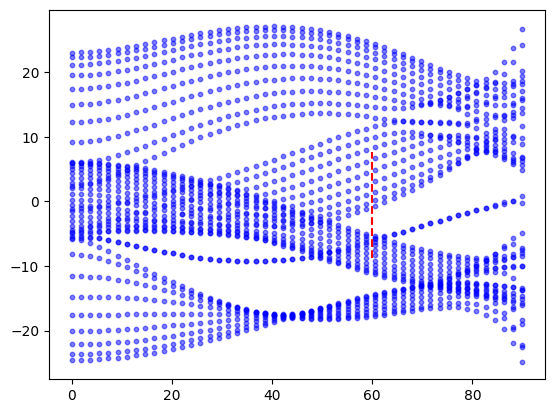

In [69]:
# open lattice consideration
def open_D_mat_hex(dist,angle,chain_length,interaction,onsite_interaction,*cut):
    latticeA = np.zeros((2,chain_length))
    latticeB = np.zeros((2,chain_length))
    a = 1
    displacement_vector = 2*(1+dist*np.cos(angle))*np.array([1,0])
    for n in range(latticeA.shape[1]//2):
        latticeA[:,2*n] = n*displacement_vector
        latticeA[:,2*n+1] = n*displacement_vector + (1+dist*np.cos(angle))*np.array([1,0])+dist*np.sin(angle)*np.array([0,1])

        latticeB[:,2*n] = n*displacement_vector + dist*np.cos(angle)*np.array([1,0])+ dist*np.sin(angle)*np.array([0,1])
        latticeB[:,2*n+1] = n*displacement_vector + (1+dist*2*np.cos(angle))*np.array([1,0])

    # for n in range(latticeA.shape[1]):
    #     latticeA[:,n] = n*np.array([1,0])*(2+alpha)
    # for n in range(latticeB.shape[1]):
    #     latticeB[:,n] = n*np.array([1,0])*(2+alpha) + (1+alpha) * np.array([1,0])+displace*np.array([0,1])
        #np.array([frac*a*np.cos(alpha),frac*a*np.sin(alpha)])
    


    dmat = np.zeros((4*chain_length,4*chain_length),dtype=complex)
    if not cut:
        cut = [max(dist,1)]#[chain_length*10**6]
    for i in range(4):
        for j in range(4):
            if i <2 and j<2:
                for n in range(latticeA.shape[1]):
                    for m in range(latticeA.shape[1]):
                        # print(i*(latticeA.shape[1])+n,j*(latticeA.shape[1])+m)
                        if i!=j:
                            Del_RAB = latticeB[:,m]-latticeA[:,n]
                            dmat[i*(latticeA.shape[1])+n,j*(latticeA.shape[1])+n] -= interaction(Del_RAB,i,j,*cut)
                        if n==m:
                            dmat[i*(latticeA.shape[1])+n,j*(latticeA.shape[1])+m] += onsite_interaction(i,j)
                            continue
                        Del_R = latticeA[:,m]-latticeA[:,n]
                        dmat[i*(latticeA.shape[1])+n,j*(latticeA.shape[1])+m] += interaction(Del_R,i,j,*cut)
                        if i!=j:
                            dmat[i*(latticeA.shape[1])+n,j*(latticeA.shape[1])+n] -= interaction(Del_R,i,j,*cut)
                        
            if i >=2 and j>=2:
                for n in range(latticeB.shape[1]):
                    for m in range(latticeB.shape[1]):
                        # print(2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m)
                        if i!=j:
                            Del_RAB = latticeA[:,m]-latticeB[:,n]
                            dmat[2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+n] -= interaction(Del_RAB,i-2,j-2,*cut)
                        if n==m:
                            dmat[2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m] += onsite_interaction(i-2,j-2)
                            continue
                        Del_R = latticeB[:,m]-latticeB[:,n]
                        dmat[2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m] += interaction(Del_R,i-2,j-2,*cut)
                        if i!=j:
                            dmat[2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+n] -= interaction(Del_R,i-2,j-2,*cut)
                        
                        
            if i <2 and j>=2:
                for n in range(latticeA.shape[1]):
                    for m in range(latticeB.shape[1]):
                        Del_R = latticeB[:,m]-latticeA[:,n]
                        dmat[i*(latticeA.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m] = interaction(Del_R,i,j-2,*cut)
                        # print(i*(latticeA.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m)
            if i >=2 and j<2:
                for n in range(latticeB.shape[1]):
                    for m in range(latticeA.shape[1]):
                        Del_R = latticeA[:,m]-latticeB[:,n]
                        dmat[2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,j*(latticeA.shape[1])+m] = interaction(Del_R,i-2,j,*cut)
                        # print(2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,j*(latticeA.shape[1])+m)
    return dmat, latticeA, latticeB, chain_length

fig, ax = plt.subplots(1,1)
alphas = np.logspace(0, 1, base=10)
chain_length = 10
angles = np.linspace(0,np.pi/2,len(alphas))
eigenvals = np.zeros((len(alphas),4*chain_length,4*chain_length+1),dtype=complex)
# dmat, latticeA, latticeB, lattice_size = open_D_mat(7,bare_interaction_coulomb,bare_interaction_coulomb_onsite,100)/0.4**(1/5)

def find_separate(array):
    distance = np.abs(array[:,1:]-array[:,:-1])
    criteria = np.where(distance[:,2:]<distance[:,:-2],distance[:,2:],distance[:,:-2])
    
    energies = np.ones(array.shape[0])*np.nan
    for i in range(array.shape[0]):
        ordered = sort_eigenvalues(criteria[i],np.arange(1,array.shape[1]-2))
        # print("orderd: ",ordered[-8:])
        # print("original",distance[i])
        for j in range(len(ordered)):
            if ordered[-j,0]>2 and array[i,int(ordered[-j,1])]:#
                energies[i] = array[i,int(ordered[-j,1])]
                break
    return energies

# sep_eng = find_separate(eigenvals)

for i in range(len(alphas)):
  
    dmat, latticeA, latticeB, chain_length = open_D_mat_hex(1,angles[i],chain_length,bare_interaction,no_onsite_interaction,100)
    eig, vecs = np.linalg.eig(dmat)
    # eigenvals[i,:,0] = eig
    # eigenvals[i,:,1:] = vecs.T
    eigenvals[i]= sort_eigenvalues(eig,vecs)
    # ax.scatter(1/alphas[i]**5*np.ones(eig.shape[0]-36), sorted(np.real(eig))[18:-18], color='blue', s=10, alpha=0.5)
    # ax.scatter(angles[i]/np.pi*180*np.ones(eig.shape[0]-36), sorted(np.real(eig))[18:-18], color='blue', s=10, alpha=0.5)
    ax.scatter(angles[i]/np.pi*180*np.ones(eig.shape[0]), sorted(np.real(eig))[:], color='blue', s=10, alpha=0.5)

# sep_eng = find_separate(eigenvals[:,:,0])
# ax.scatter(angles/np.pi*180,sep_eng,color='0')


ax.vlines(60,np.min(eigenvals[:,18:-18,0]),np.max(eigenvals[:,18:-18,0]), colors='red', linestyles='dashed')
plt.show()


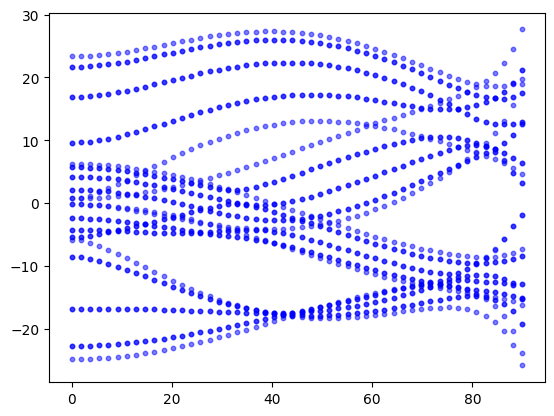

In [142]:
fig, ax1 = plt.subplots(1,1)
# fig, ax2 = plt.subplots(1,1)
# alphas = np.logspace(0, 1, base=10)
chain_length = 4
angles = np.linspace(0,np.pi/2,50)
size = 8
eigenvals_diag = np.zeros((len(angles),size*chain_length,size+1),dtype=complex)
eigenvals_off = np.zeros_like(eigenvals_diag)
for i in range(len(angles)):
    for j in range(chain_length):
        # for l in range(chain_length//2):
            4*np.pi/np.sqrt(3)#*np.array([1,0])#
            k = j/chain_length*np.pi/(1+np.cos(angles[i]))
            dmat= D_mat_alternative_grid(np.array([k,0]),angles[i],1,bare_interaction,no_onsite_interaction,chain_length,100)
            eig, vecs = np.linalg.eig(dmat)
            eigenvals_diag[i,j*size:(j+1)*size,0] = eig
            eigenvals_diag[i,j*size:(j+1)*size,1:] = vecs.T
    # print(eigenvals_diag[i,:,0])
    ax1.scatter(angles[i]/np.pi*180*np.ones(eigenvals_diag.shape[1]), sorted(np.real(eigenvals_diag[i,:,0]))[:], color='blue', s=10, alpha=0.5)
    # ax1.scatter(angles[i]/np.pi*180, np.sum(np.real(eigenvals_diag[i,:,0])), color='blue', s=10, alpha=0.5)


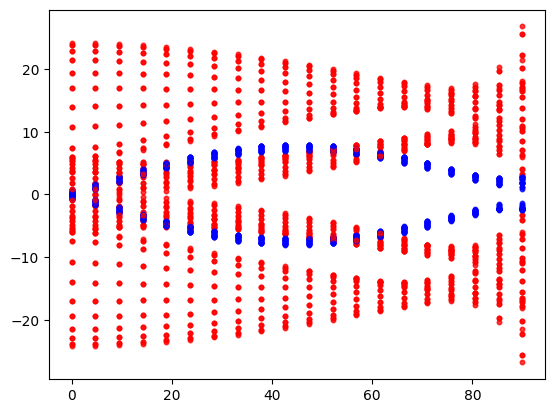

In [88]:
fig, ax1 = plt.subplots(1,1)
# fig, ax2 = plt.subplots(1,1)
alphas = np.logspace(0, 1, base=10)
chain_length = 10
size = 8
angles = np.linspace(0,np.pi/2,20)
eigenvals_diag = np.zeros((len(angles),8*chain_length,8+1),dtype=complex)
eigenvals_off = np.zeros_like(eigenvals_diag)
for i in range(len(angles)):
    for j in range(chain_length):
        # for l in range(chain_length//2):
            4*np.pi/np.sqrt(3)#*np.array([1,0])#
            k = j/chain_length*np.pi/(1+np.cos(angles[i]))
            dmat= D_mat_alternative_grid(np.array([k,0]),angles[i],1,bare_interaction,no_onsite_interaction,chain_length,100)
    
    
            dmat_diag = np.zeros_like(dmat)
            dmat_diag[:4,:4] = dmat[:4,:4]
            dmat_diag[4:,4:] = dmat[4:,4:]
            dmat_off = np.zeros_like(dmat)
            dmat_off[4:,:4] = dmat[4:,:4]
            dmat_off[:4,4:] = dmat[:4,4:]

            eig_diag, vecs_diag = np.linalg.eig(dmat_diag)
            eigenvals_diag[i,j*size:(j+1)*size]= sort_eigenvalues(eig_diag,vecs_diag)
            eig_off, vecs_off = np.linalg.eig(dmat_off)
            eigenvals_off[i,j*size:(j+1)*size]= sort_eigenvalues(eig_off,vecs_off)
            # ax.scatter(1/alphas[i]**5*np.ones(eig.shape[0]-36), sorted(np.real(eig))[18:-18], color='blue', s=10, alpha=0.5)
            # ax.scatter(angles[i]/np.pi*180*np.ones(eig.shape[0]-36), sorted(np.real(eig))[18:-18], color='blue', s=10, alpha=0.5)
            ax1.scatter(angles[i]/np.pi*180*np.ones(eig_diag.shape[0]), sorted(np.real(eig_diag))[:], color='blue', s=10, alpha=0.5)
            ax1.scatter(angles[i]/np.pi*180*np.ones(eig_off.shape[0]), sorted(np.abs(eig_off))[:], color='red', s=10, alpha=0.5)
            ax1.scatter(angles[i]/np.pi*180*np.ones(eig_off.shape[0]), sorted(-np.abs(eig_off))[:], color='red', s=10, alpha=0.5)
            

# sep_eng = find_separate(eigenvals[:,:,0])
# ax.scatter(angles/np.pi*180,sep_eng,color='0')


# ax.vlines(60,np.min(eigenvals[:,18:-18,0]),np.max(eigenvals[:,18:-18,0]), colors='red', linestyles='dashed')
plt.show()

0.0


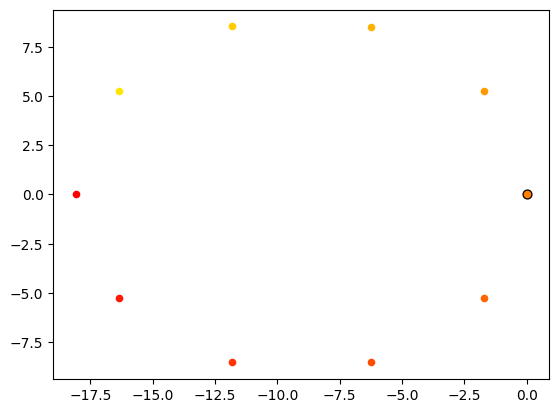

0.904670202838142


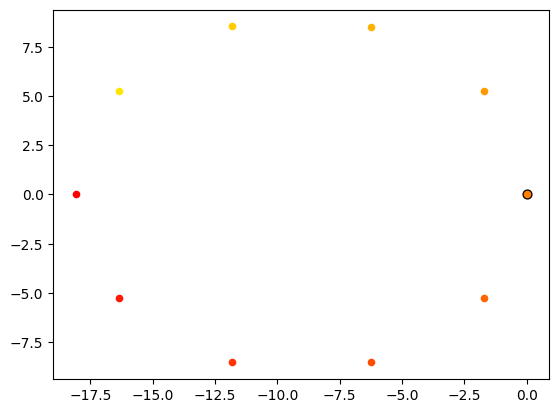

1.809340405676284


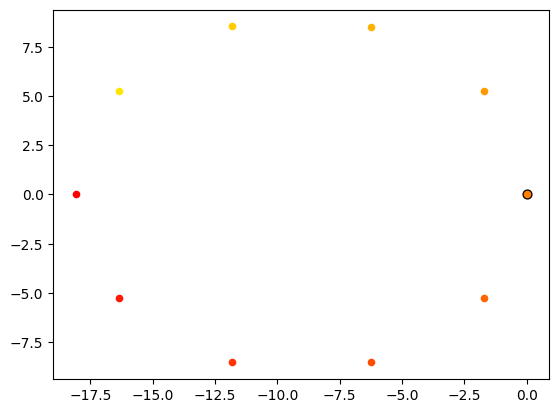

2.714010608514426


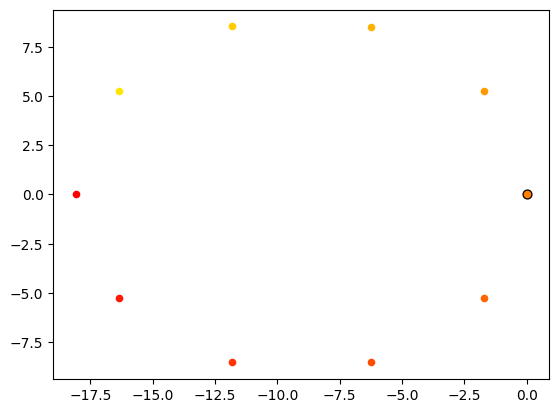

3.618680811352568


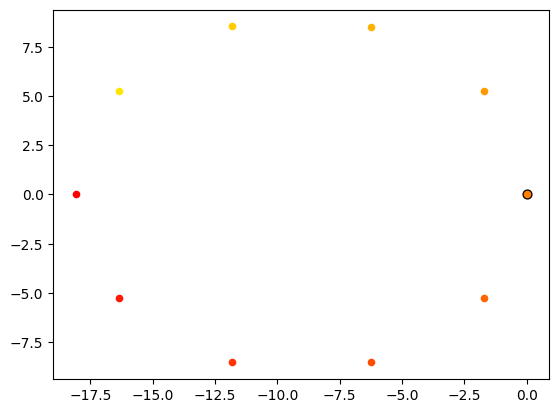

4.52335101419071


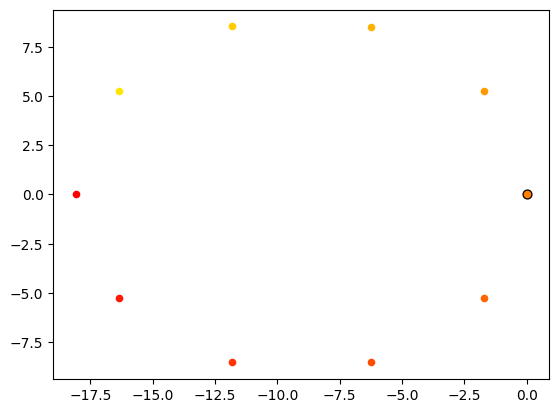

5.428021217028852


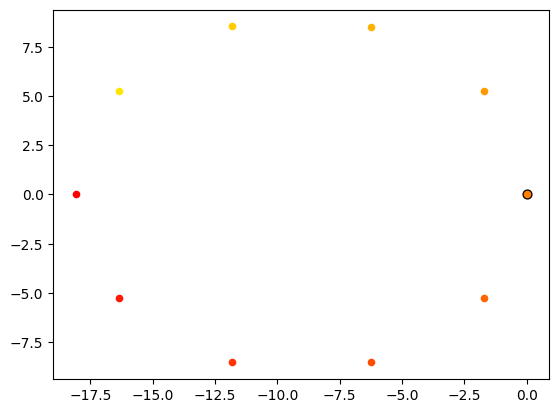

6.332691419866995


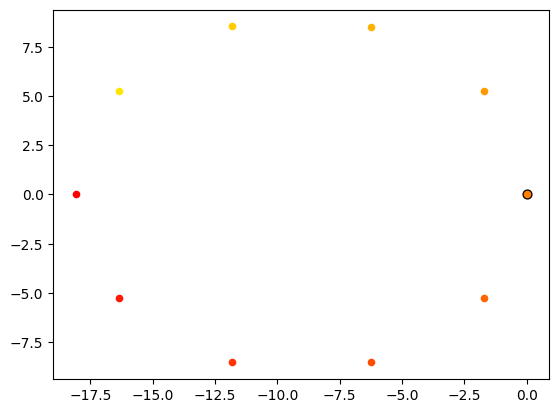

7.237361622705136


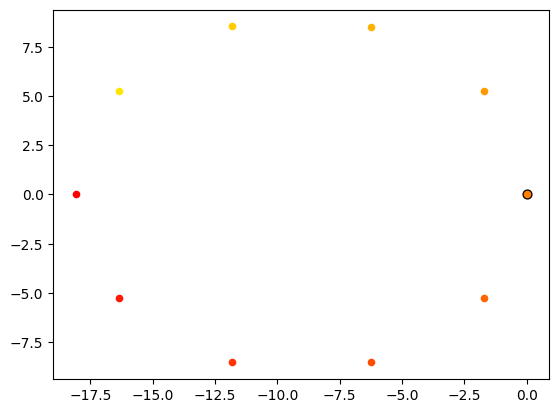

8.142031825543278


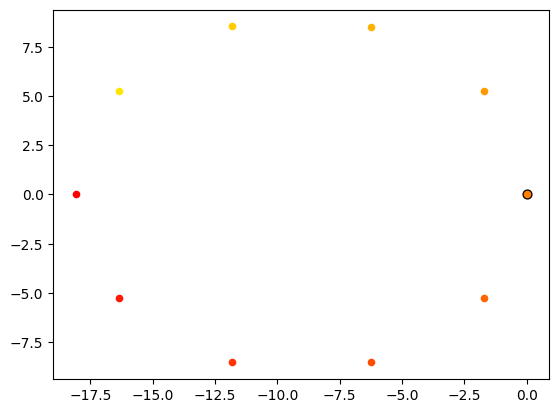

9.04670202838142


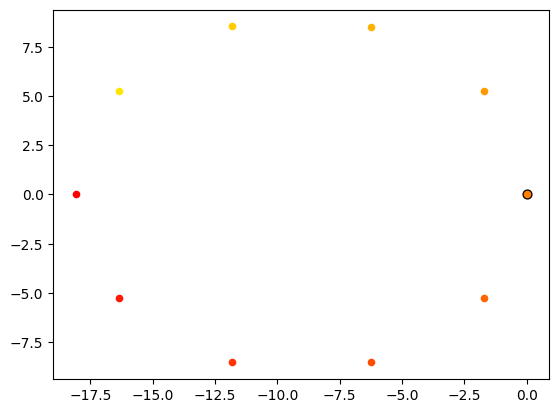

9.951372231219562


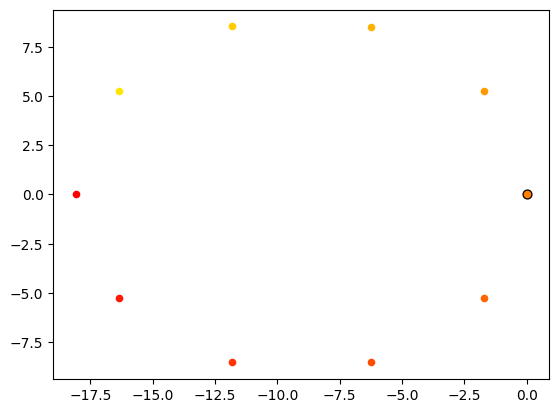

10.856042434057704


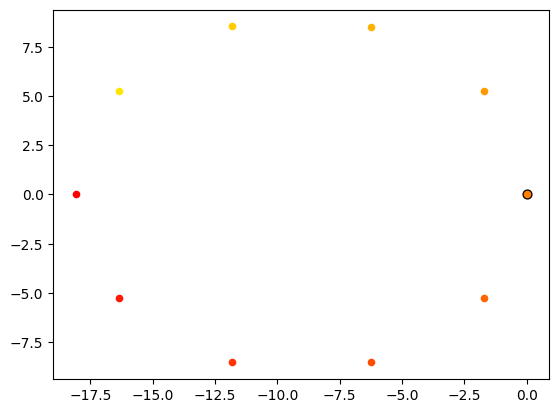

11.760712636895846


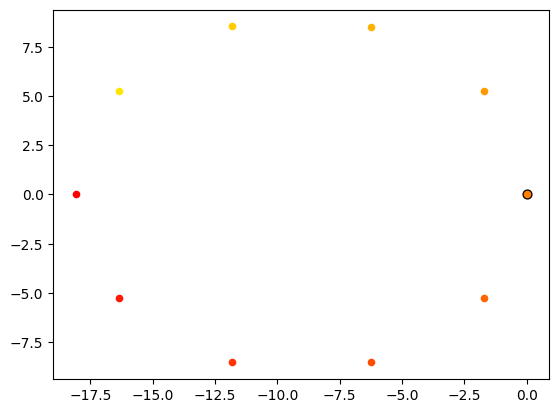

12.66538283973399


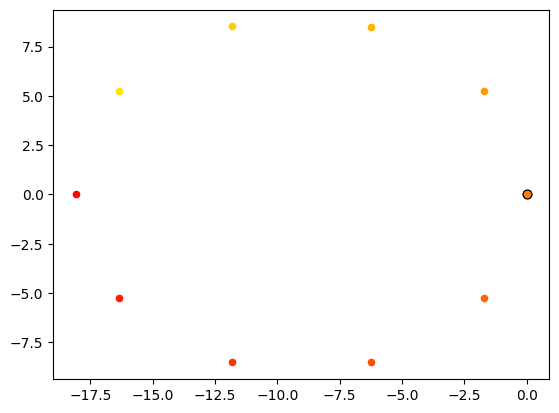

13.57005304257213


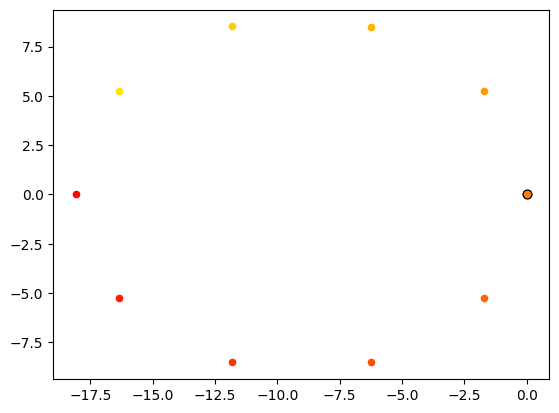

14.474723245410273


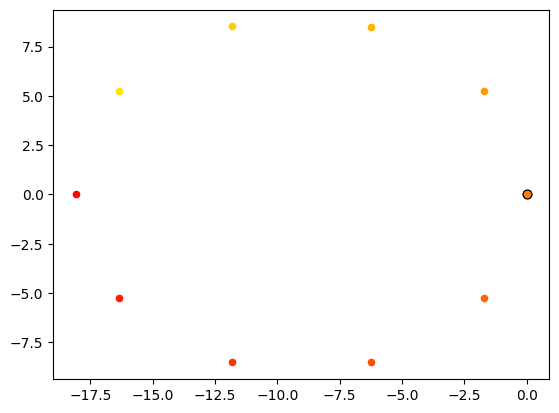

15.379393448248413


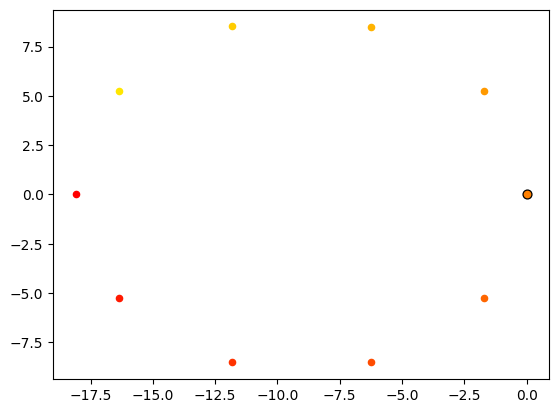

16.284063651086555


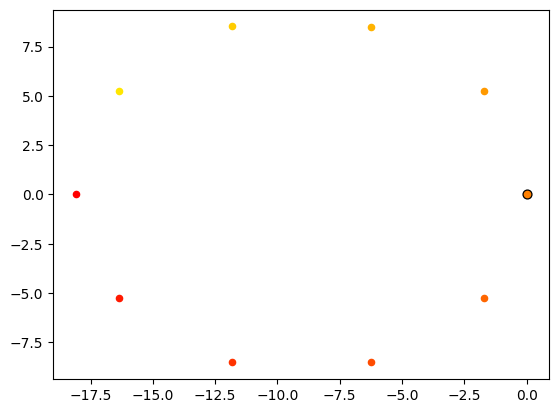

17.188733853924695


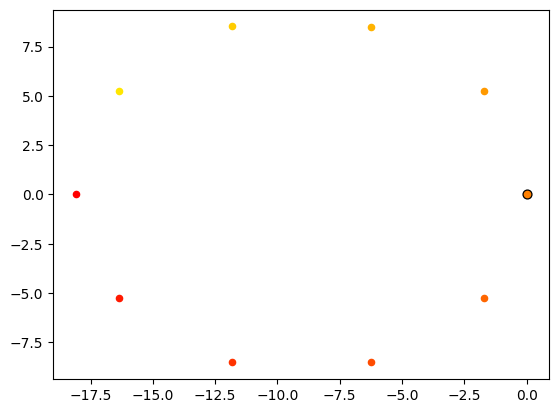

In [91]:

# fig, ax2 = plt.subplots(1,1)
alphas = np.logspace(0, 1, base=10)
chain_length = 10
size = 4
from matplotlib import colormaps
cmap = colormaps['autumn']#['viridis']
# angles = np.linspace(0,np.pi/2-0.1,15)
angles = np.linspace(0,0.3,20)
eigenvals_diag = np.zeros((len(angles),4*chain_length,4+1),dtype=complex)
eigenvals_off = np.zeros_like(eigenvals_diag)
for i in range(len(angles)):
    # fig, ax1 = plt.subplots(2,2,figsize=(15,15))
    print(angles[i]/np.pi*180)
    fig, ax1 = plt.subplots(1,1)
    ax1.scatter(0,0,s=40,color='0')
    # ax1.set_xlim(-7,10)
    for j in range(chain_length):
        # for l in range(chain_length//2):
            4*np.pi/np.sqrt(3)#*np.array([1,0])#
            k = j/chain_length*np.pi/(1+np.cos(angles[i]))
            dmat= D_mat_alternative_grid(np.array([k,0]),angles[i],1,bare_interaction,no_onsite_interaction,chain_length,100)

            dmat_diag = dmat[:4,:4]
            
            dmat_off = dmat[:4,4:]
#
            eig_diag, vecs_diag = np.linalg.eig(dmat_diag)
            eigenvals_diag[i,j*size:(j+1)*size]= sort_eigenvalues(eig_diag,vecs_diag)
            eig_off, vecs_off = np.linalg.eig(dmat_off)
            eigenvals_off[i,j*size:(j+1)*size]= sort_eigenvalues(eig_off,vecs_off)
            # ax2.scatter(angles[i]*np.ones(),np.real(eigenvals_off[i,:,0]),color='blue',s=20)
            # ax1.scatter(np.real(eigenvals_off[i,j*size:(j+1)*size,0]),np.imag(eigenvals_off[i,j*size:(j+1)*size,0]),color=cmap(j/chain_length),s=20)
            ax1.scatter(np.sum(np.real(eigenvals_off[i,j*size:(j+1)*size,0])),np.sum(np.imag(eigenvals_off[i,j*size:(j+1)*size,0])),color=cmap(j/chain_length),s=20)
            # for l in range(2):
            #     for m in range(2):
            #         ax1[l,m].scatter(0,0,s=80,color='red')
            #         ax1[l,m].scatter(np.real(eigenvals_off[i,j*size+2*l+m,0]),np.imag(eigenvals_off[i,j*size+2*l+m,0]),color=cmap(j/chain_length),s=40)
    # ax2.scatter(angles[i],np.sum(np.real(eigenvals_off[i,:,0])),color='blue',s=20)#*np.ones(eigenvals_off.shape[1])
    # ax1.set_xlim(-7,np.max(np.real(eigenvals_off[i,:,0]))+1/2)
    plt.show()


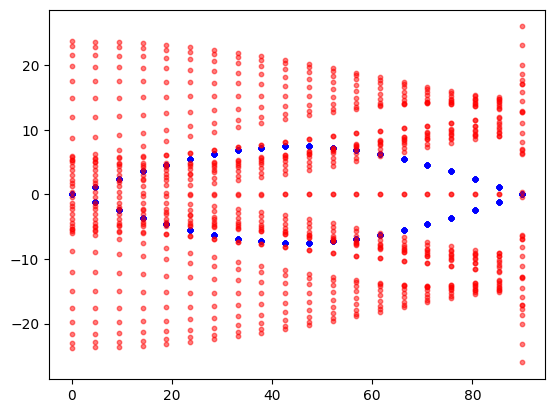

In [84]:
fig, ax1 = plt.subplots(1,1)
# fig, ax2 = plt.subplots(1,1)
alphas = np.logspace(0, 1, base=10)
chain_length = 10
angles = np.linspace(0,np.pi/2,20)
# angles = np.linspace(0,0.3,20)
eigenvals_diag = np.zeros((len(angles),4*chain_length,4*chain_length+1),dtype=complex)
eigenvals_off = np.zeros_like(eigenvals_diag)
for i in range(len(angles)):
  
    dmat, latticeA, latticeB, chain_length = open_D_mat_hex(1,angles[i],chain_length,bare_interaction,no_onsite_interaction,1)
    # print(np.any(np.abs(dmat-np.conjugate(dmat.T))>11/10**12))
    dmat_diag = np.zeros_like(dmat)
    dmat_diag[:2*chain_length,:2*chain_length] = dmat[:2*chain_length,:2*chain_length]
    dmat_diag[2*chain_length:,2*chain_length:] = dmat[2*chain_length:,2*chain_length:]
    dmat_off = np.zeros_like(dmat)
    dmat_off[2*chain_length:,:2*chain_length] = dmat[2*chain_length:,:2*chain_length]
    dmat_off[:2*chain_length,2*chain_length:] = dmat[:2*chain_length,2*chain_length:]

    eig_diag, vecs_diag = np.linalg.eig(dmat_diag)
    eigenvals_diag[i]= sort_eigenvalues(eig_diag,vecs_diag)
    eig_off, vecs_off = np.linalg.eig(dmat_off)
    eigenvals_off[i]= sort_eigenvalues(eig_off,vecs_off)
    # ax.scatter(1/alphas[i]**5*np.ones(eig.shape[0]-36), sorted(np.real(eig))[18:-18], color='blue', s=10, alpha=0.5)
    # ax.scatter(angles[i]/np.pi*180*np.ones(eig.shape[0]-36), sorted(np.real(eig))[18:-18], color='blue', s=10, alpha=0.5)
    ax1.scatter(angles[i]/np.pi*180*np.ones(eig_diag.shape[0]), sorted(np.real(eig_diag))[:], color='blue', s=10, alpha=0.5)
    ax1.scatter(angles[i]/np.pi*180*np.ones(eig_off.shape[0]), sorted(np.real(eig_off))[:], color='red', s=10, alpha=0.5)
    # ax1.scatter(angles[i]/np.pi*180*np.ones(eig_off.shape[0]), sorted(-np.abs(eig_off))[:], color='red', s=10, alpha=0.5)
    

# sep_eng = find_separate(eigenvals[:,:,0])
# ax.scatter(angles/np.pi*180,sep_eng,color='0')


# ax.vlines(60,np.min(eigenvals[:,18:-18,0]),np.max(eigenvals[:,18:-18,0]), colors='red', linestyles='dashed')
plt.show()

/home/christian/Documents/master/python_env/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/christian/Documents/master/python_env/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)
/tmp/ipykernel_4105/812678297.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()
/tmp/ipykernel_4105/812678297.py:27: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig2, ax2 = plt.subplots(1,1)


eigenvalue:  [0.29747522+0.j 3.74093881+0.j]
eigenvalue:  [0.29747522+0.j 3.74093881+0.j]
eigenvalue:  [ 0.29650283+0.j 14.9757868 +0.j]
eigenvalue:  [ 0.29650283+0.j 14.9757868 +0.j]
eigenvalue:  [ 0.30080123+0.j -5.6448964 +0.j]
eigenvalue:  [ 0.30080123+0.j -5.6448964 +0.j]
eigenvalue:  [ 0.37778279+0.j -5.84150234+0.j]
eigenvalue:  [ 0.37778279+0.j -5.84150234+0.j]
eigenvalue:  [ 0.45103107+0.j -6.12007559+0.j]
eigenvalue:  [ 0.45103107+0.j -6.12007559+0.j]
eigenvalue:  [0.51225324+0.j 6.46730823+0.j]
eigenvalue:  [0.51225324+0.j 6.46730823+0.j]
eigenvalue:  [0.56360448+0.j 0.03745595+0.j]
eigenvalue:  [0.56360448+0.j 0.03745595+0.j]
eigenvalue:  [ 0.6572019 +0.j -0.01447976+0.j]
eigenvalue:  [ 0.6572019 +0.j -0.01447976+0.j]
eigenvalue:  [ 0.73218331+0.j -0.00530964+0.j]
eigenvalue:  [ 0.73218331+0.j -0.00530964+0.j]
eigenvalue:  [0.78940379+0.j 0.00195525+0.j]
eigenvalue:  [0.78940379+0.j 0.00195525+0.j]
eigenvalue:  [8.31996099e-01+0.j 7.54130818e-04+0.j]
eigenvalue:  [8.3199609

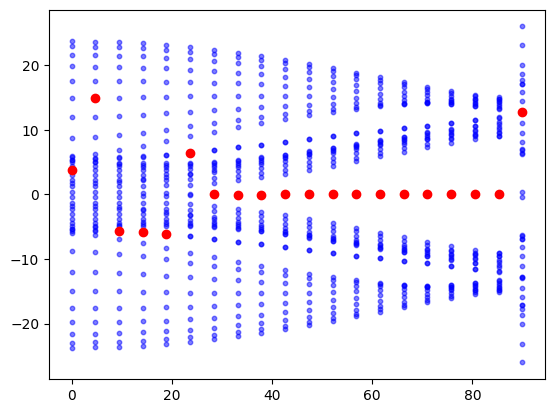

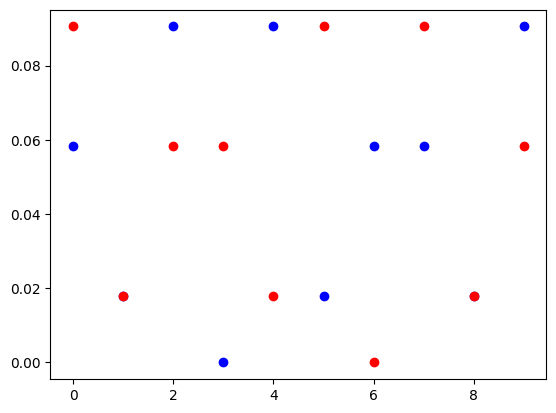

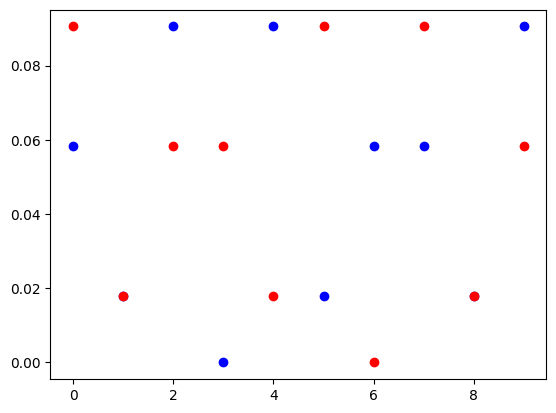

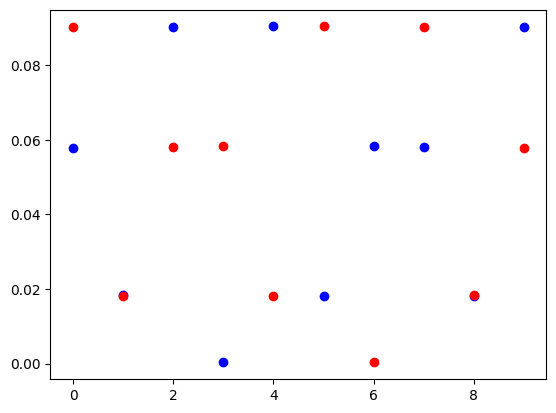

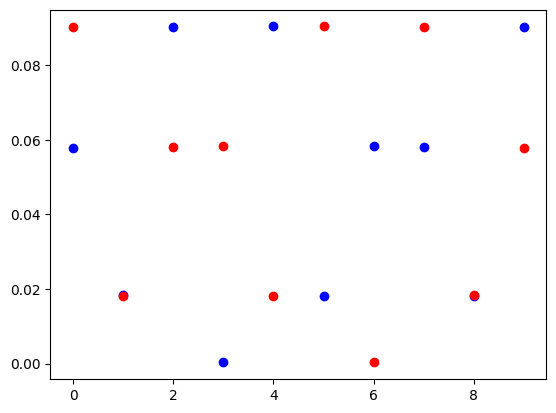

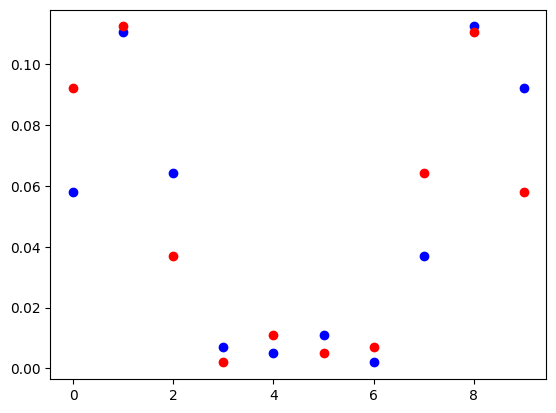

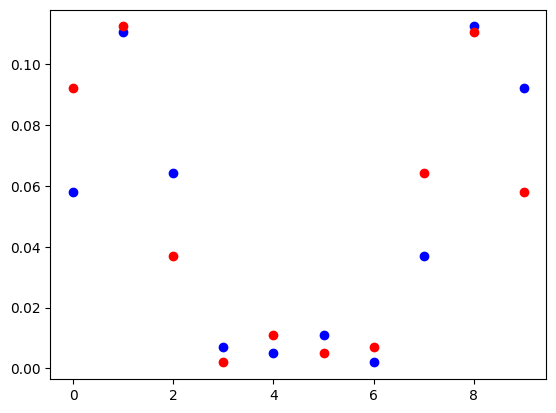

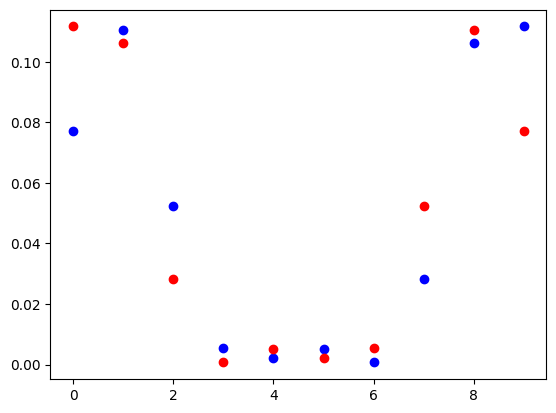

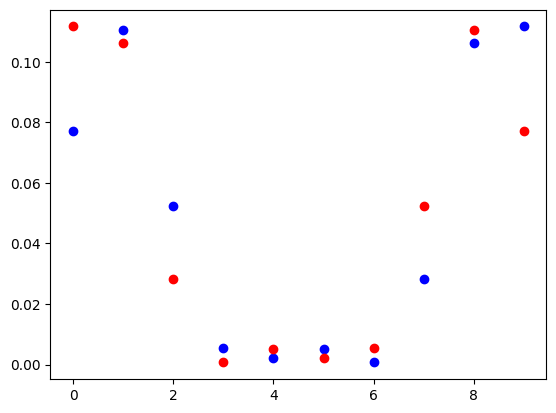

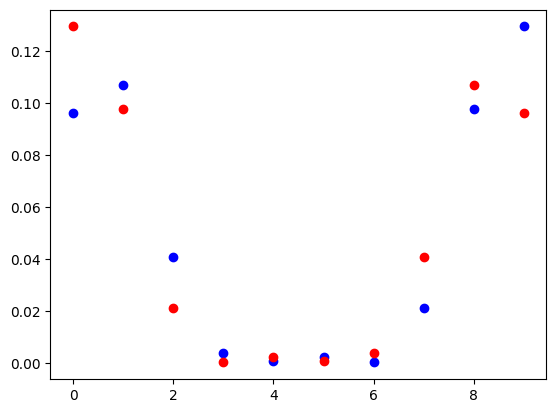

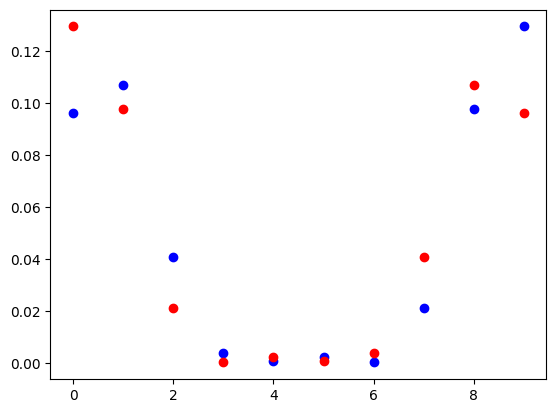

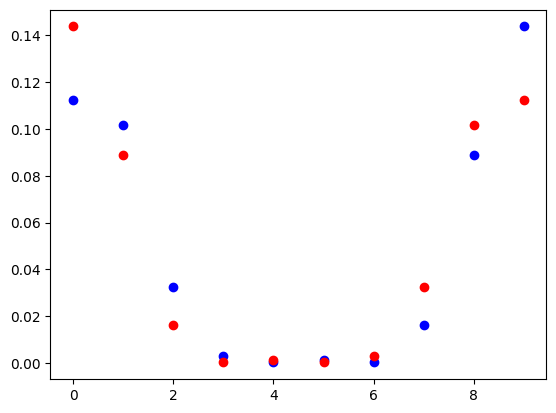

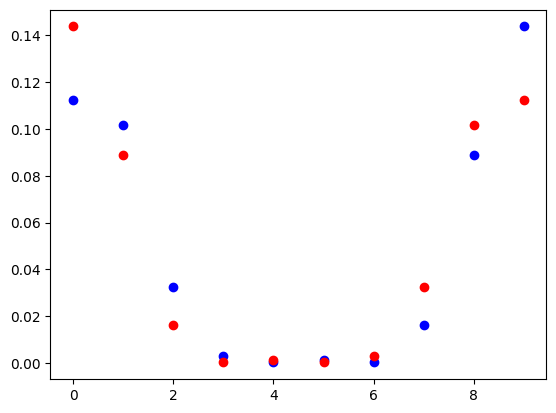

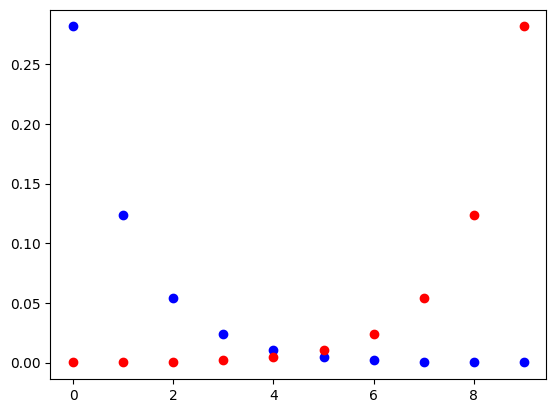

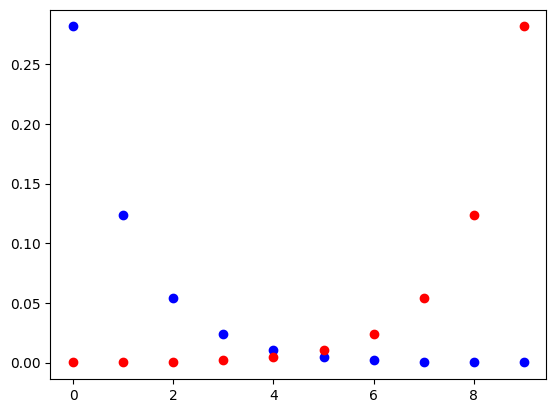

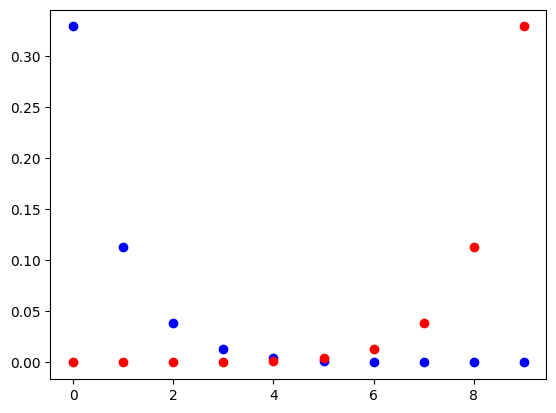

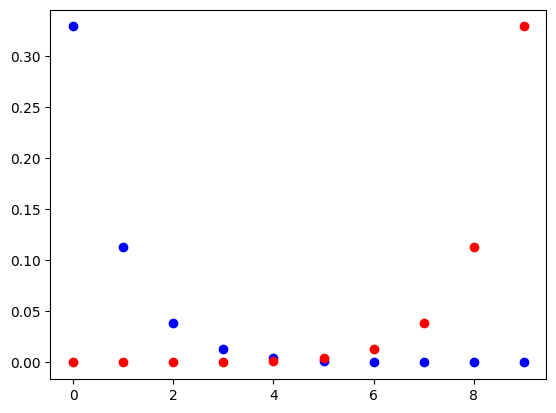

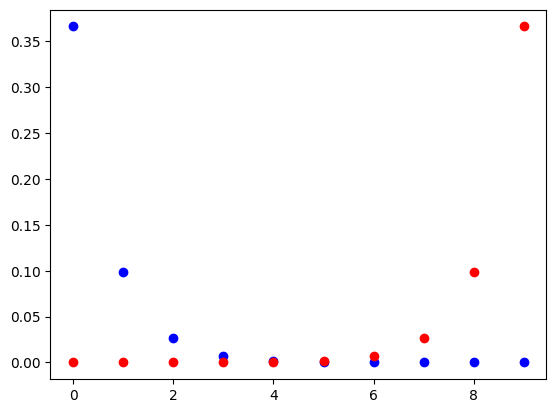

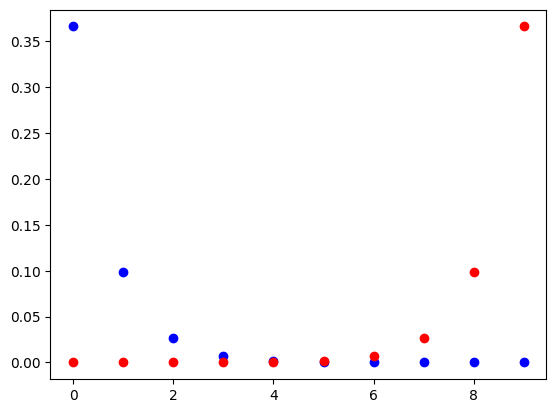

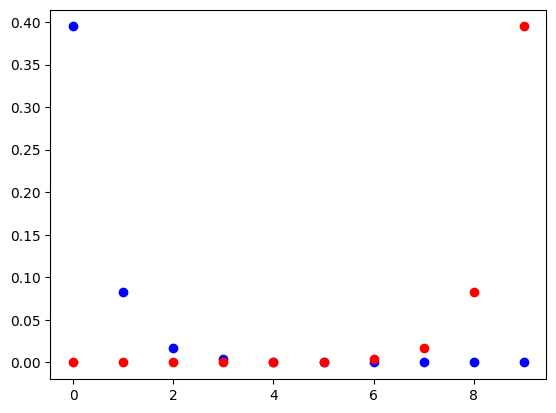

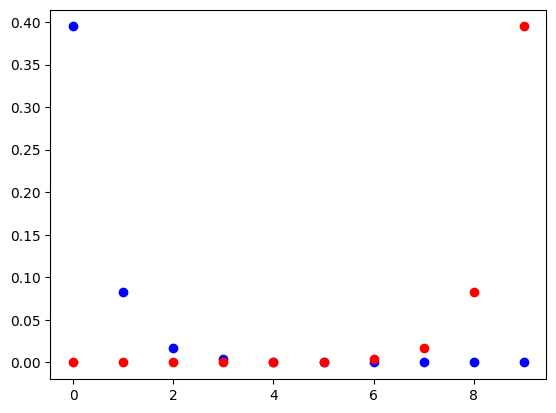

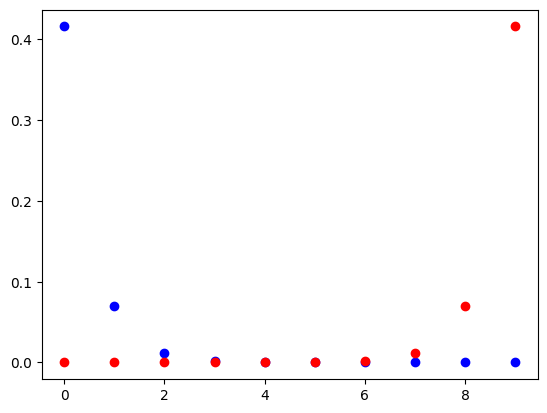

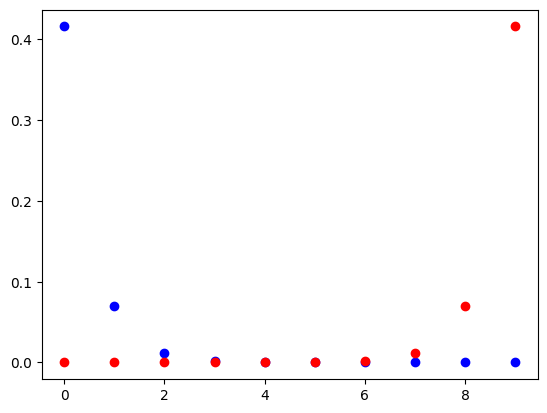

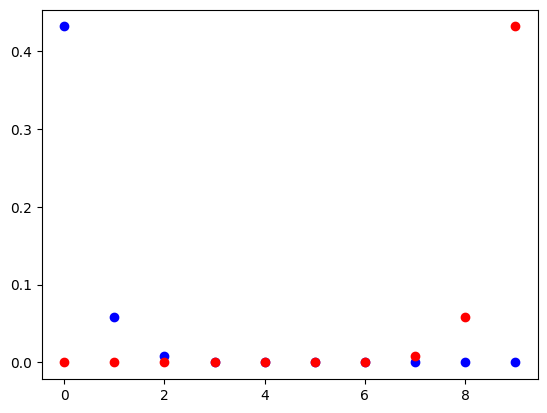

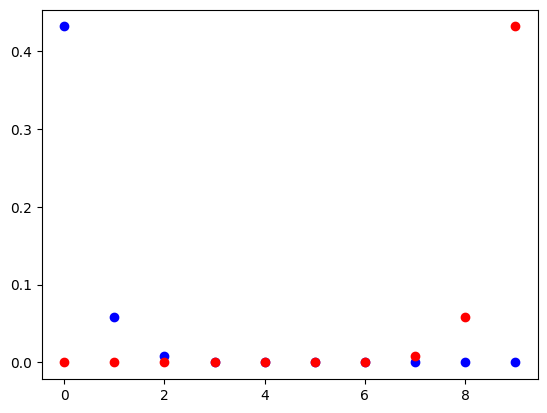

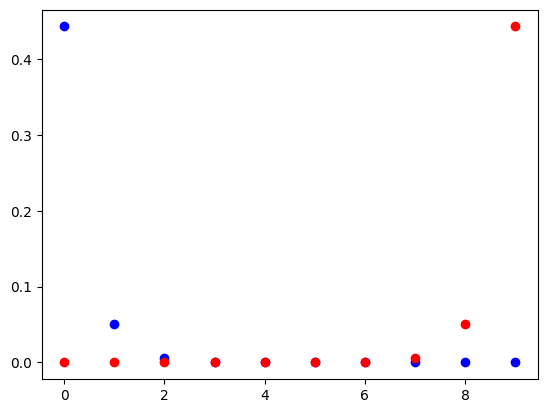

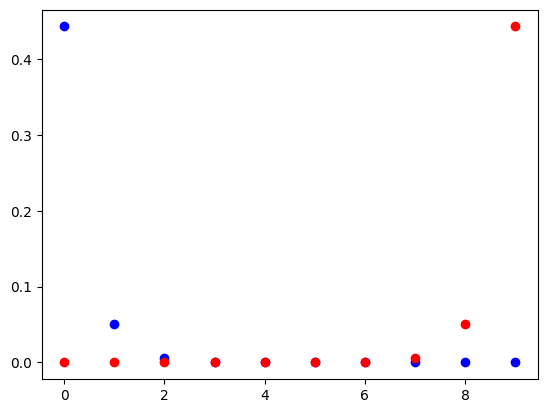

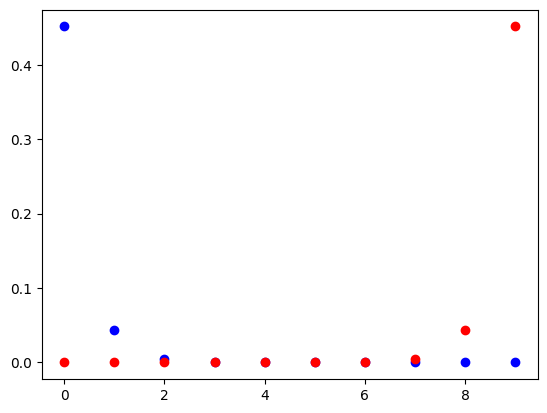

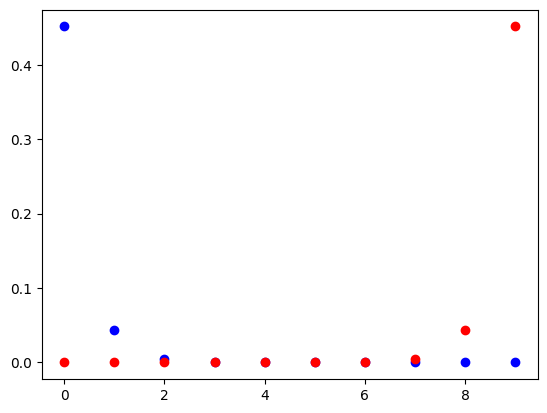

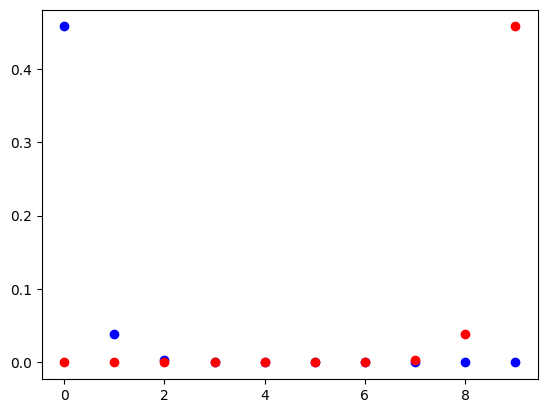

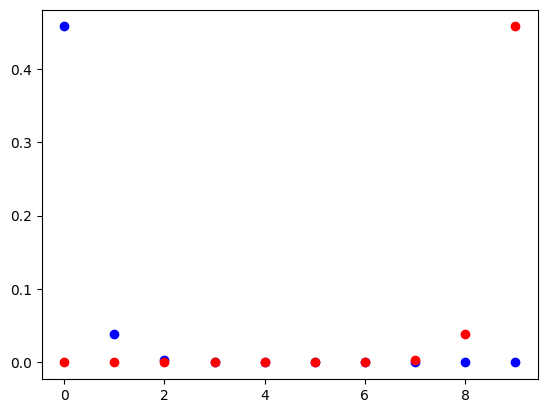

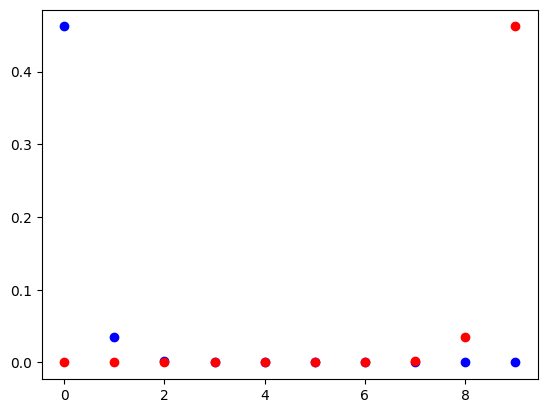

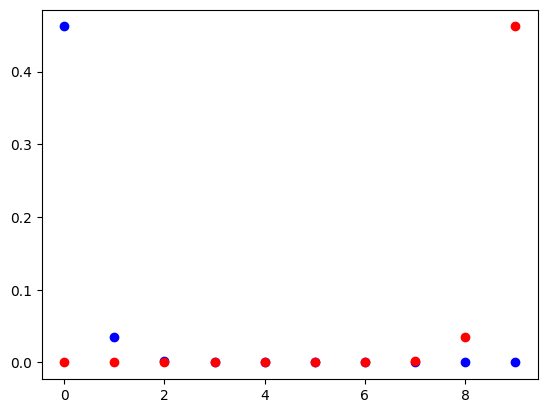

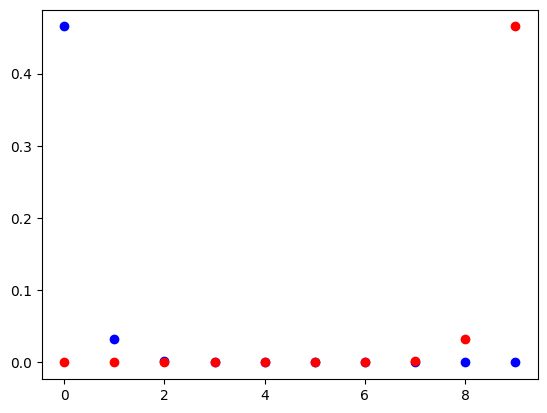

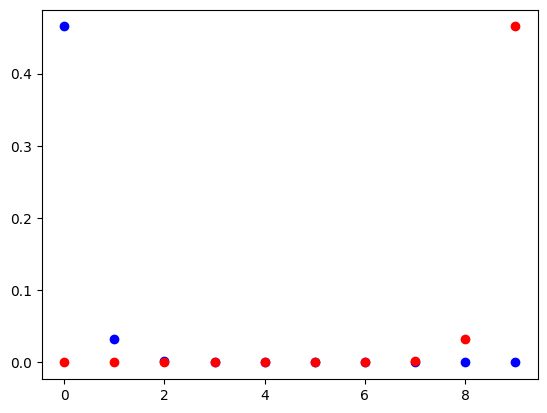

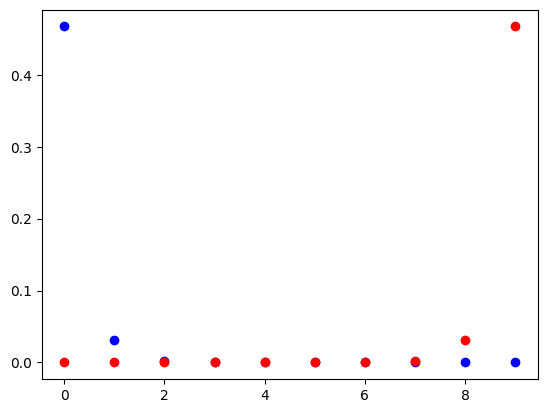

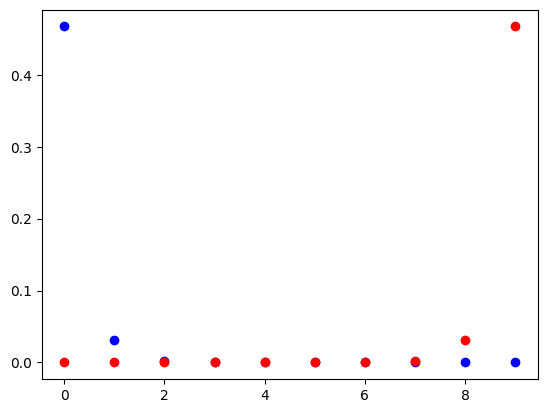

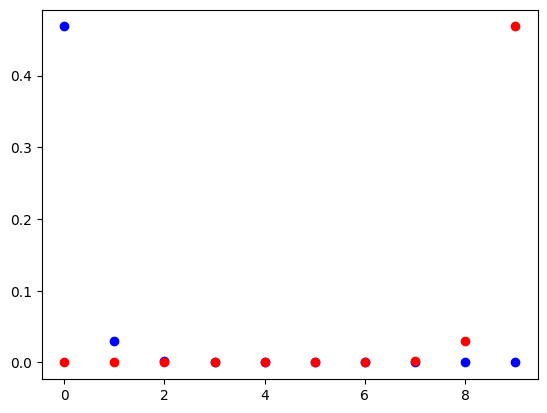

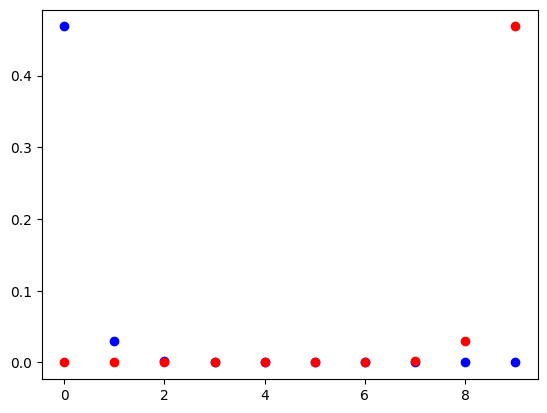

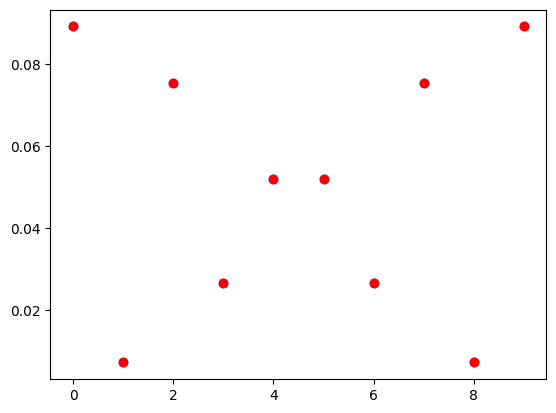

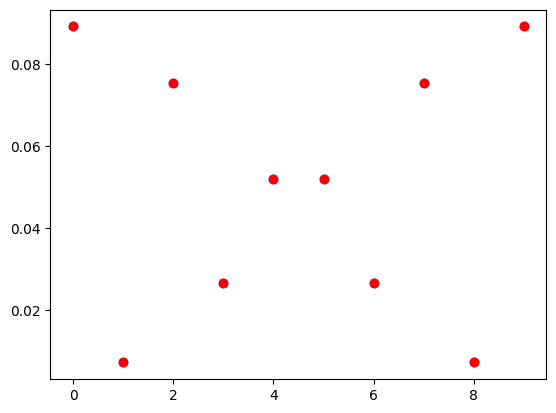

In [ ]:
def find_separate(array):
    distance = np.abs(array[:,1:]-array[:,:-1])
    criteria = np.where(distance[:,2:]<distance[:,:-2],distance[:,2:],distance[:,:-2])
    
    energies = np.ones(array.shape[0])*np.nan
    for i in range(array.shape[0]):
        ordered = sort_eigenvalues(criteria[i],np.arange(1,array.shape[1]-2))
        print("orderd: ",ordered[-8:])
        print("original",distance[i])
        if ordered[-1,0]>2:
            energies[i] = array[i,int(ordered[-1,1])]
    return energies
fig, ax = plt.subplots(1,1)
start = 18
stop = start+2
for i in range(len(angles)):
# for i in range(start,stop):
    edge_indicator = find_edge_states(eigenvals_off[i,:,:])
    # edge = sort_eigenvalues(edge_indicator, np.arange(eigenvals_off.shape[1]))
    edge = sort_eigenvalues(edge_indicator, eigenvals_off[i,:,:].T)[::-1,:]
    ax.scatter(angles[i]/np.pi*180*np.ones(eig.shape[0]), eigenvals_off[i,:,0], color='blue', s=10, alpha=0.5)
    # for j in range(len(edge_indicator)):
    #     if eigenvals[i,int(edge[-j,1]),0]>7:eigenvals_off[i,int(edge[-1,1]),0]
    ax.scatter(angles[i]/np.pi*180,edge[0,1],color='red')
            # break
    for ind in range(2):
        fig2, ax2 = plt.subplots(1,1)
        vecA = np.abs(edge[ind,2:latticeA.shape[1]+2])**2 + np.abs(edge[ind,latticeA.shape[1]+2:2*latticeA.shape[1]+2])**2
        vecB = np.abs(edge[ind,2*latticeA.shape[1]+2:2*latticeA.shape[1]+2+latticeB.shape[1]])**2 + np.abs(edge[ind,2*latticeA.shape[1]+2+latticeB.shape[1]:2*latticeA.shape[1]+2+latticeB.shape[1]*2:])**2

        print('eigenvalue: ', edge[0,:2])
        # print('eig: ', vecA[n,:])
        ax2.scatter(latticeA[0,:],vecA, color='blue')
        ax2.scatter(latticeB[0,:],vecB, color='red')
        # fig2.show()
        

# ax.scatter(angles[start:stop]/np.pi*180,find_separate(eigenvals[start:stop,:,0]),color='0')
plt.show()

In [ ]:
def find_edge_states(vec):
    return np.abs(vec[:,1])**2+np.abs(vec[:,latticeA.shape[1]])**2+np.abs(vec[:,latticeA.shape[1]+1])**2+np.abs(vec[:,(latticeA.shape[1])*2])**2\
    + np.abs(vec[:,2*latticeA.shape[1]+1])**2+np.abs(vec[:,latticeB.shape[1]+2*latticeA.shape[1]])**2+np.abs(vec[:,2*latticeA.shape[1]+latticeB.shape[1]+1])**2+np.abs(vec[:,2*latticeA.shape[1]+(latticeB.shape[1])*2])**2


/home/christian/Documents/master/python_env/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/christian/Documents/master/python_env/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


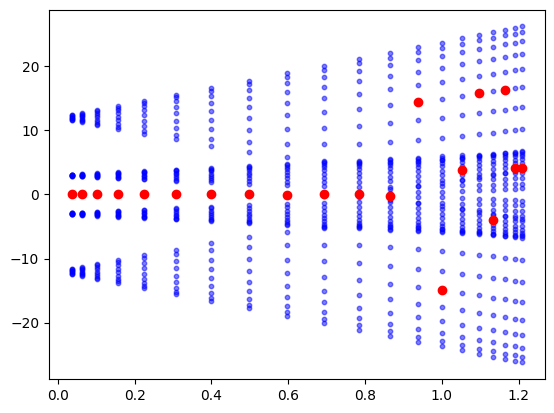

In [93]:
def find_separate(array):
    distance = np.abs(array[:,1:]-array[:,:-1])
    criteria = np.where(distance[:,2:]<distance[:,:-2],distance[:,2:],distance[:,:-2])
    
    energies = np.ones(array.shape[0])*np.nan
    for i in range(array.shape[0]):
        ordered = sort_eigenvalues(criteria[i],np.arange(1,array.shape[1]-2))
        print("orderd: ",ordered[-8:])
        print("original",distance[i])
        if ordered[-1,0]>2:
            energies[i] = array[i,int(ordered[-1,1])]
    return energies
fig, ax = plt.subplots(1,1)
start = 18
stop = start+2
alphas =0.95+1/ np.logspace(0,1.9,base=10,num=20)
# alphas = np.linspace(1,15,20)
for i in range(len(alphas)):
# for i in range(start,stop):
    dmat, latticeA, latticeB, chain_length = open_D_mat_hex(alphas[i],0,10,bare_interaction,no_onsite_interaction)
    eig, vecs = np.linalg.eig(dmat)
    eigenvals[i] = sort_eigenvalues(eig,vecs)
    edge_indicator = find_edge_states(eigenvals[i,:,:])
    # edge = sort_eigenvalues(edge_indicator, np.arange(eigenvals.shape[1]))
    edge = sort_eigenvalues(edge_indicator, eigenvals[i,:,:].T)[::-1,:]
    ax.scatter(1/alphas[i]**5*np.ones(eig.shape[0]), eigenvals[i,:,0], color='blue', s=10, alpha=0.5)
    # for j in range(len(edge_indicator)):
    #     if eigenvals[i,int(edge[-j,1]),0]>7:eigenvals[i,int(edge[-1,1]),0]
    ax.scatter(1/alphas[i]**5,edge[0,1],color='red')
    # for ind in range(2):
    #     fig2, ax2 = plt.subplots(1,1)
    #     vecA = np.abs(edge[ind,2:latticeA.shape[1]+2])**2 + np.abs(edge[ind,latticeA.shape[1]+2:2*latticeA.shape[1]+2])**2
    #     vecB = np.abs(edge[ind,2*latticeA.shape[1]+2:2*latticeA.shape[1]+2+latticeB.shape[1]])**2 + np.abs(edge[ind,2*latticeA.shape[1]+2+latticeB.shape[1]:2*latticeA.shape[1]+2+latticeB.shape[1]*2:])**2

    #     # print('eigenvalue: ', edge[0,:2])
    #     # print('eig: ', vecA[n,:])
    #     ax2.scatter(latticeA[0,:],vecA, color='blue')
    #     ax2.scatter(latticeB[0,:],vecB, color='red')
            # break

# ax.scatter(angles[start:stop]/np.pi*180,find_separate(eigenvals[start:stop,:,0]),color='0')
plt.show()

In [ ]:
1.6*10**(-19) 

0.26298487836949375


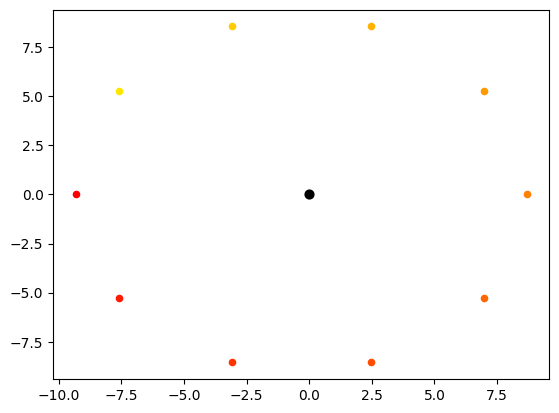

0.3286575237879356


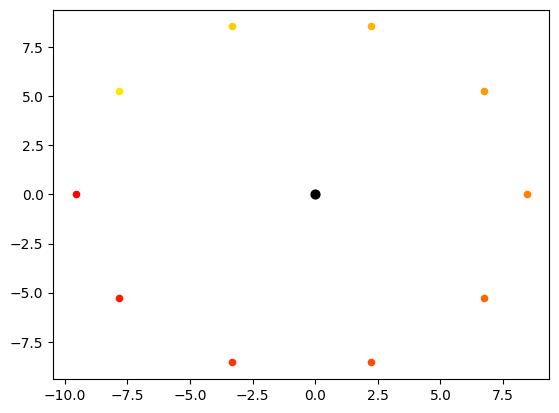

0.40009184107157725


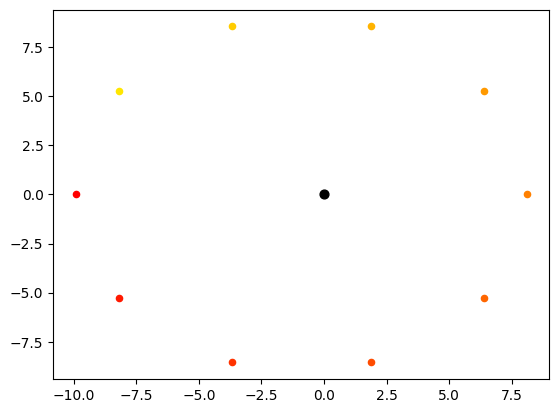

0.47484634739297527


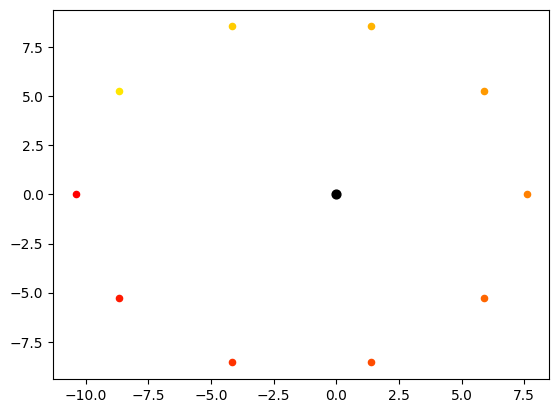

0.550238738236458


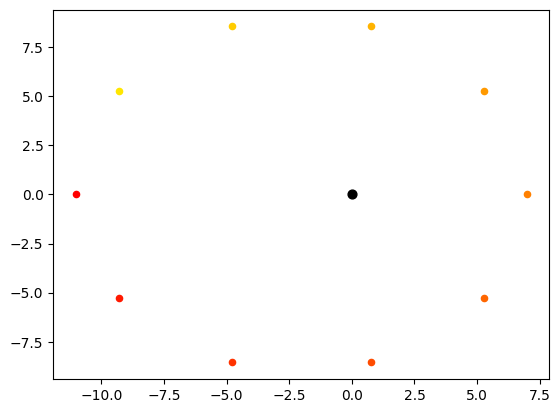

0.6237008485057528


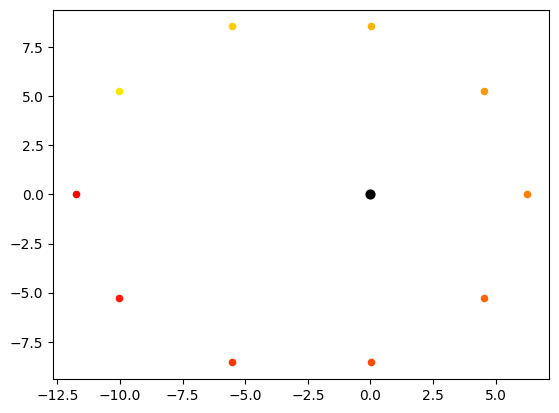

0.6930707414468753


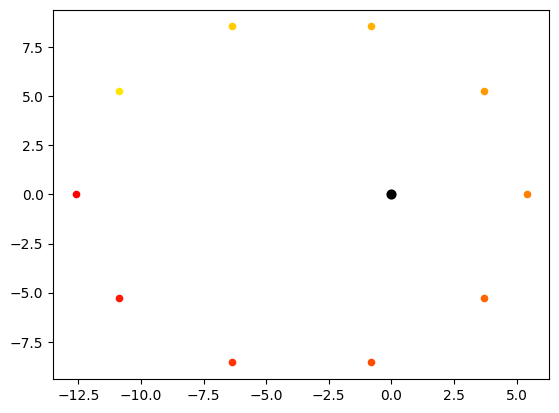

0.756767073472157


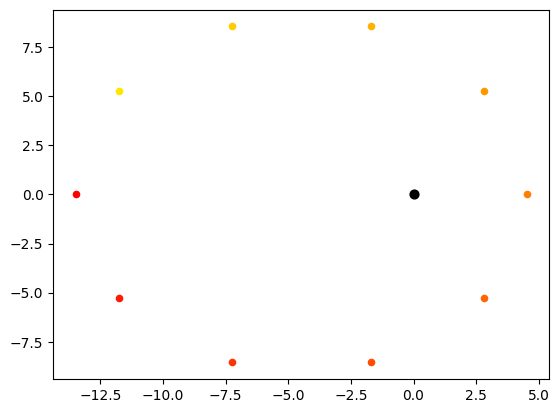

0.8138361449174429


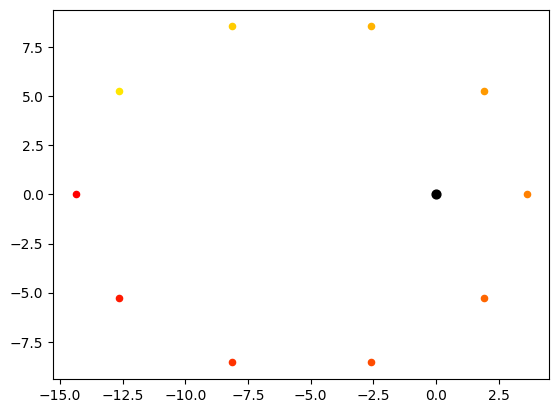

0.8638974788819591


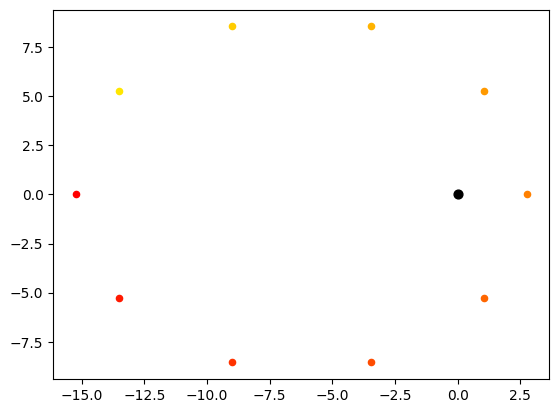

0.9070294784580498


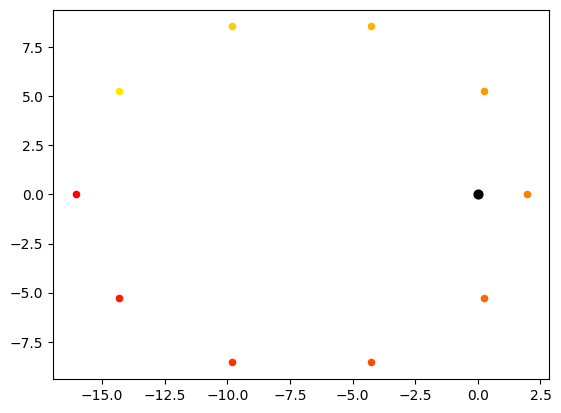

0.9436348609510109


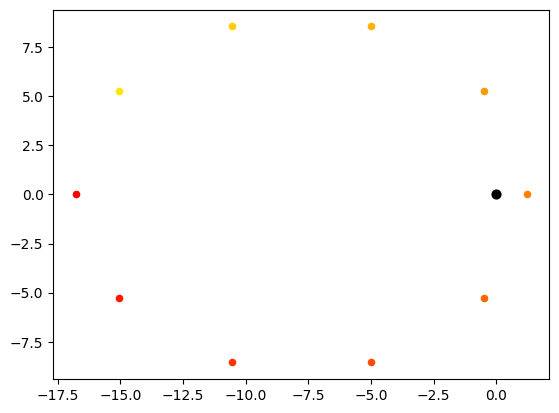

0.9743141870854884


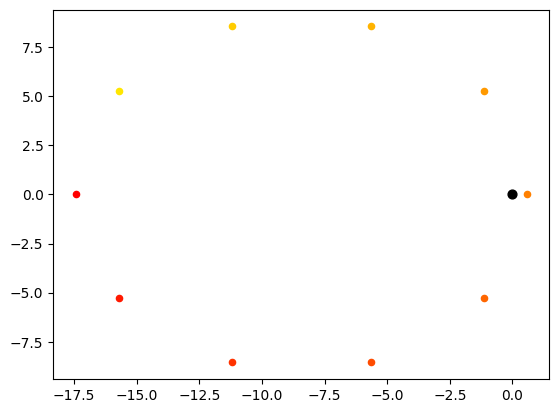

0.9997625955535637


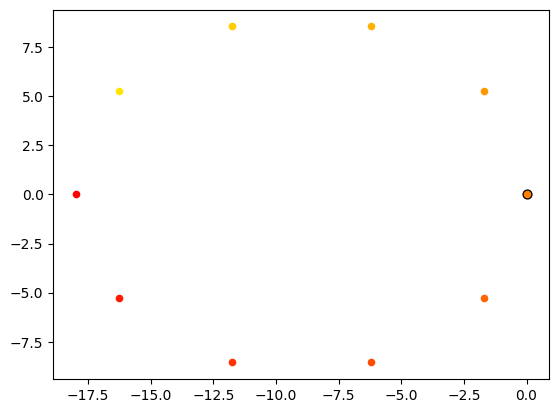

1.0206943163775104


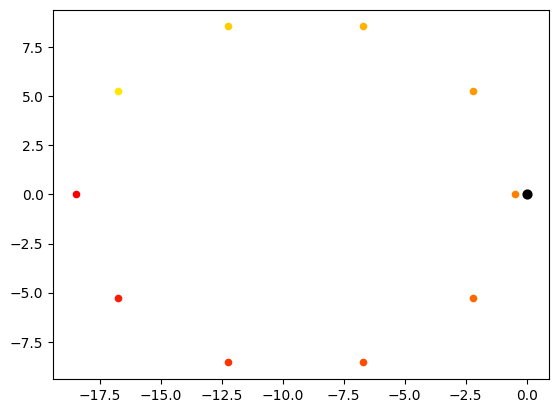

1.0377930225452199


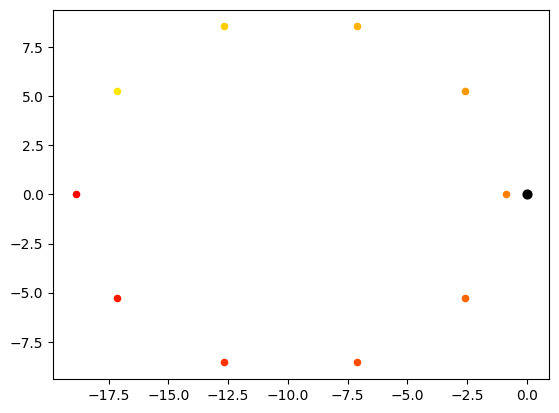

1.051683072025618


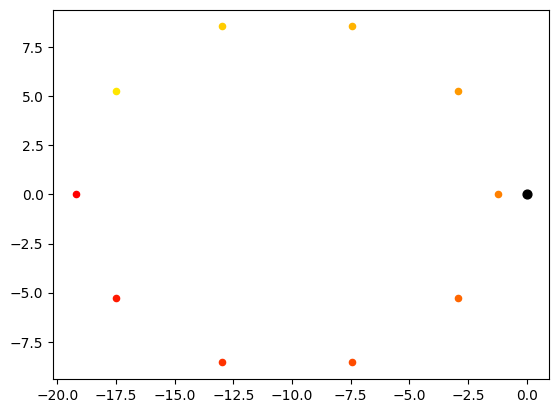

1.0629160286795283


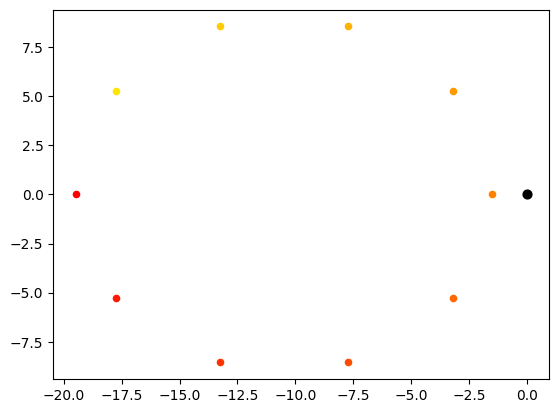

1.071967434948376


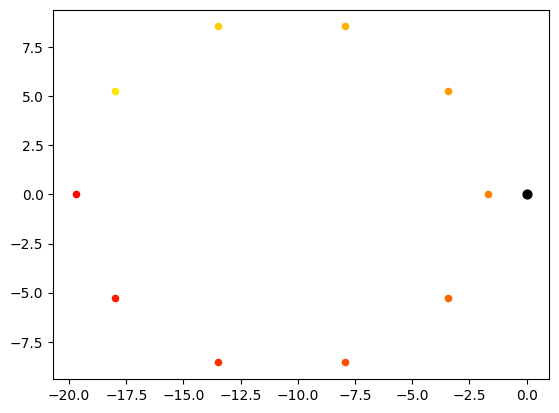

1.079239872023765


/tmp/ipykernel_4105/2386816003.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  potential -= 15/Del_R**7 *Delta_R_vec[i] * Delta_R_vec[j]
/tmp/ipykernel_4105/2386816003.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  potential -= 15/Del_R**7 *Delta_R_vec[i] * Delta_R_vec[j]


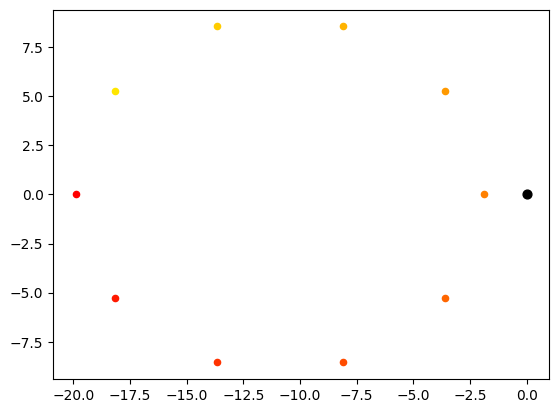

In [94]:

# fig, ax2 = plt.subplots(1,1)

chain_length = 10
size = 2
from matplotlib import colormaps
cmap = colormaps['autumn']#['viridis']
# angles = np.linspace(0,np.pi/2-0.1,15)
# angles = np.linspace(0,0.3,20)
eigenvals_diag = np.zeros((len(alphas),2*chain_length,2+1),dtype=complex)
eigenvals_off = np.zeros_like(eigenvals_diag)
for i in range(len(alphas)):
    # fig, ax1 = plt.subplots(2,2,figsize=(15,15))
    print(1/alphas[i]**2)
    fig, ax1 = plt.subplots(1,1)
    ax1.scatter(0,0,s=40,color='0')
    # ax1.set_xlim(-7,10)
    for j in range(chain_length):
        # for l in range(chain_length//2):
            4*np.pi/np.sqrt(3)#*np.array([1,0])#
            k = j/(chain_length//2)*np.pi/(1+alphas[i])
            dmat= D_mat(np.array([k,0]),0,alphas[i],bare_interaction,no_onsite_interaction,chain_length,max(1,alphas[i]))

            dmat_diag = dmat[:2,:2]
            
            dmat_off = dmat[:2,2:]

            eig_diag, vecs_diag = np.linalg.eig(dmat_diag)
            eigenvals_diag[i,j*size:(j+1)*size]= sort_eigenvalues(eig_diag,vecs_diag)
            eig_off, vecs_off = np.linalg.eig(dmat_off)
            eigenvals_off[i,j*size:(j+1)*size]= sort_eigenvalues(eig_off,vecs_off)
            # ax2.scatter(angles[i]*np.ones(),np.real(eigenvals_off[i,:,0]),color='blue',s=20)
            # ax1.scatter(np.real(eigenvals_off[i,j*size:(j+1)*size,0]),np.imag(eigenvals_off[i,j*size:(j+1)*size,0]),color=cmap(j/chain_length),s=20)
            ax1.scatter(np.sum(np.real(eigenvals_off[i,j*size:(j+1)*size,0])),np.sum(np.imag(eigenvals_off[i,j*size:(j+1)*size,0])),color=cmap(j/chain_length),s=20)
            # for l in range(2):
            #     for m in range(2):
            #         ax1[l,m].scatter(0,0,s=80,color='red')
            #         ax1[l,m].scatter(np.real(eigenvals_off[i,j*size+2*l+m,0]),np.imag(eigenvals_off[i,j*size+2*l+m,0]),color=cmap(j/chain_length),s=40)
    # ax2.scatter(angles[i],np.sum(np.real(eigenvals_off[i,:,0])),color='blue',s=20)#*np.ones(eigenvals_off.shape[1])
    # ax1.set_xlim(-7,np.max(np.real(eigenvals_off[i,:,0]))+1/2)
    plt.show()


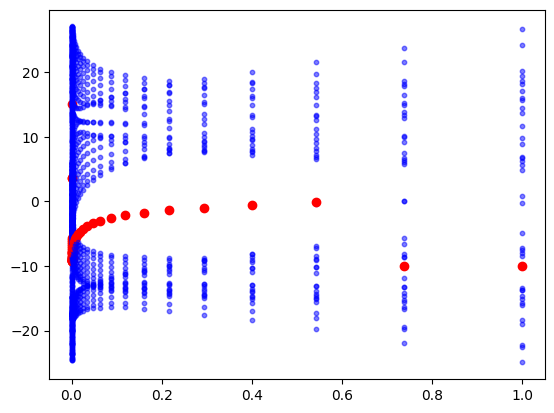

In [ ]:
def find_separate(array):
    distance = np.abs(array[:,1:]-array[:,:-1])
    criteria = np.where(distance[:,2:]<distance[:,:-2],distance[:,2:],distance[:,:-2])
    
    energies = np.ones(array.shape[0])*np.nan
    for i in range(array.shape[0]):
        ordered = sort_eigenvalues(criteria[i],np.arange(1,array.shape[1]-2))
        print("orderd: ",ordered[-8:])
        print("original",distance[i])
        if ordered[-1,0]>2:
            energies[i] = array[i,int(ordered[-1,1])]
    return energies
fig, ax = plt.subplots(1,1)
start = 18
stop = start+2
for i in range(len(angles)):
# for i in range(start,stop):
    edge_indicator = find_edge_states(eigenvals_off[i,:,:])
    # edge = sort_eigenvalues(edge_indicator, np.arange(eigenvals_off.shape[1]))
    edge = sort_eigenvalues(edge_indicator, eigenvals_off[i,:,:].T)[::-1,:]
    ax.scatter(angles[i]/np.pi*180*np.ones(eig.shape[0]), eigenvals_off[i,:,0], color='blue', s=10, alpha=0.5)
    # for j in range(len(edge_indicator)):
    #     if eigenvals[i,int(edge[-j,1]),0]>7:eigenvals_off[i,int(edge[-1,1]),0]
    ax.scatter(angles[i]/np.pi*180,edge[0,1],color='red')
            # break
    for ind in range(2):
        fig2, ax2 = plt.subplots(1,1)
        vecA = np.abs(edge[ind,2:latticeA.shape[1]+2])**2 + np.abs(edge[ind,latticeA.shape[1]+2:2*latticeA.shape[1]+2])**2
        vecB = np.abs(edge[ind,2*latticeA.shape[1]+2:2*latticeA.shape[1]+2+latticeB.shape[1]])**2 + np.abs(edge[ind,2*latticeA.shape[1]+2+latticeB.shape[1]:2*latticeA.shape[1]+2+latticeB.shape[1]*2:])**2

        print('eigenvalue: ', edge[0,:2])
        # print('eig: ', vecA[n,:])
        ax2.scatter(latticeA[0,:],vecA, color='blue')
        ax2.scatter(latticeB[0,:],vecB, color='red')
        # fig2.show()
        

# ax.scatter(angles[start:stop]/np.pi*180,find_separate(eigenvals[start:stop,:,0]),color='0')
plt.show()

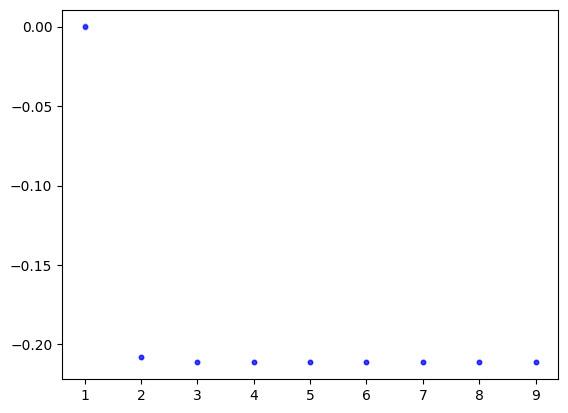

In [61]:
def open_D_mat(dist,angle,chain_length,interaction,onsite_interaction,*cut):
    latticeA = np.zeros((2,chain_length))
    latticeB = np.zeros((2,chain_length))
    a = 1
    displacement_vector = 2*(1+dist*np.cos(angle))*np.array([1,0])
    for n in range(latticeA.shape[1]//2):
        latticeA[:,2*n] = n*displacement_vector
        latticeA[:,2*n+1] = n*displacement_vector + (1+dist*np.cos(angle))*np.array([1,0])+dist*np.sin(angle)*np.array([0,1])

        latticeB[:,2*n] = n*displacement_vector + dist*np.cos(angle)*np.array([1,0])+ dist*np.sin(angle)*np.array([0,1])
        latticeB[:,2*n+1] = n*displacement_vector + (1+dist*2*np.cos(angle))*np.array([1,0])

    # for n in range(latticeA.shape[1]):
    #     latticeA[:,n] = n*np.array([1,0])*(2+alpha)
    # for n in range(latticeB.shape[1]):
    #     latticeB[:,n] = n*np.array([1,0])*(2+alpha) + (1+alpha) * np.array([1,0])+displace*np.array([0,1])
        #np.array([frac*a*np.cos(alpha),frac*a*np.sin(alpha)])
    


    dmat = np.zeros((4*chain_length,4*chain_length),dtype=complex)
    if not cut:
        cut = [dist]#[chain_length*10**6]
    for i in range(4):
        for j in range(4):
            if i <2 and j<2:
                for n in range(latticeA.shape[1]):
                    for m in range(latticeA.shape[1]):
                        # print(i*(latticeA.shape[1])+n,j*(latticeA.shape[1])+m)
                        if n==m:
                            dmat[i*(latticeA.shape[1])+n,j*(latticeA.shape[1])+m] = onsite_interaction(i,j)
                            continue
                        Del_R = latticeA[:,m]-latticeA[:,n]
                        dmat[i*(latticeA.shape[1])+n,j*(latticeA.shape[1])+m] = interaction(Del_R,i,j,*cut)
                        
            if i >=2 and j>=2:
                for n in range(latticeB.shape[1]):
                    for m in range(latticeB.shape[1]):
                        # print(2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m)
                        if n==m:
                            dmat[2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m] = onsite_interaction(i-2,j-2)
                            continue
                        Del_R = latticeB[:,m]-latticeB[:,n]
                        dmat[2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m] = interaction(Del_R,i-2,j-2,*cut)
                        
            if i <2 and j>=2:
                for n in range(latticeA.shape[1]):
                    for m in range(latticeB.shape[1]):
                        Del_R = latticeB[:,m]-latticeA[:,n]
                        dmat[i*(latticeA.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m] = interaction(Del_R,i,j-2,*cut)
                        # print(i*(latticeA.shape[1])+n,2*(latticeA.shape[1])+(j-2)*(latticeB.shape[1])+m)
            if i >=2 and j<2:
                for n in range(latticeB.shape[1]):
                    for m in range(latticeA.shape[1]):
                        Del_R = latticeA[:,m]-latticeB[:,n]
                        dmat[2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,j*(latticeA.shape[1])+m] = interaction(Del_R,i-2,j,*cut)
                        # print(2*(latticeA.shape[1])+(i-2)*(latticeB.shape[1])+n,j*(latticeA.shape[1])+m)
    return dmat, latticeA, latticeB, chain_length

fig, ax = plt.subplots(1,1)
alphas = np.logspace(0, 1, base=10)
chain_length = 10
angles = np.linspace(0,np.pi/2,len(alphas))
eigenvals = np.zeros((len(alphas),4*chain_length,4*chain_length+1),dtype=complex)
eigenvals = np.zeros((9,4*chain_length,4*chain_length+1),dtype=complex)

# dmat, latticeA, latticeB, lattice_size = open_D_mat(7,bare_interaction_coulomb,bare_interaction_coulomb_onsite,100)/0.4**(1/5)
# for i in range(len(alphas)):
for i in range(9):
    dmat, latticeA, latticeB, chain_length = open_D_mat(1,np.pi/3,chain_length,bare_interaction,no_onsite_interaction,np.arange(1,10)[i])
    eig, vecs = np.linalg.eig(dmat)
    # eigenvals[i,:,0] = eig
    # eigenvals[i,:,1:] = vecs.T
    eigenvals[i]= sort_eigenvalues(eig,vecs)
    # ax.scatter(1/alphas[i]**5*np.ones(eig.shape[0]-36), sorted(np.real(eig))[18:-18], color='blue', s=10, alpha=0.5)
    # ax.scatter(angles[i]*np.ones(eig.shape[0]-36), sorted(np.real(eig))[18:-18], color='blue', s=10, alpha=0.5)
    ax.scatter(np.arange(1,10)[i]*np.ones(eig.shape[0]-38), sorted(np.real(eig))[19:-19], color='blue', s=10, alpha=0.5)
# ax.vlines(np.pi/3,np.min(eigenvals[:,18:-18,0]),np.max(eigenvals[:,18:-18,0]), colors='red', linestyles='dashed')
plt.show()

/home/christian/Documents/master/python_env/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/christian/Documents/master/python_env/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


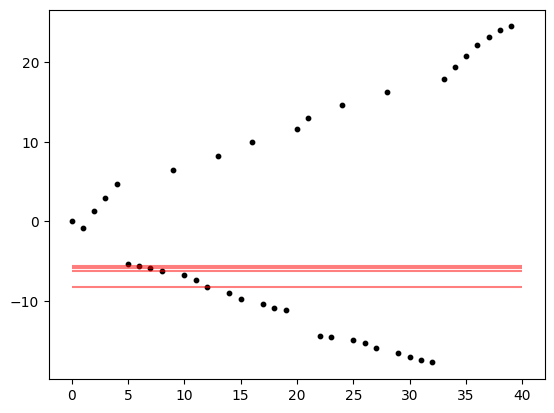

eigenvalue:  [ 0.62281079+0.j -5.88675684+0.j]


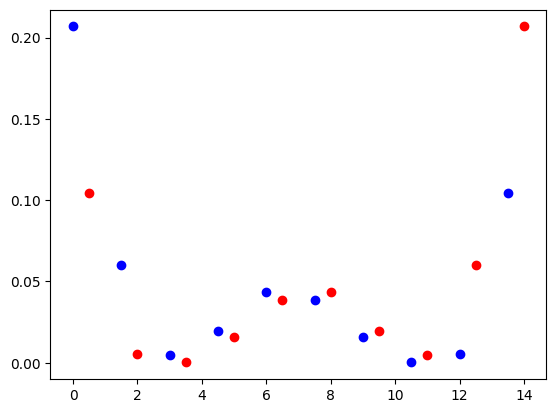

eigenvalue:  [ 0.62281079+0.j -5.88675684+0.j]


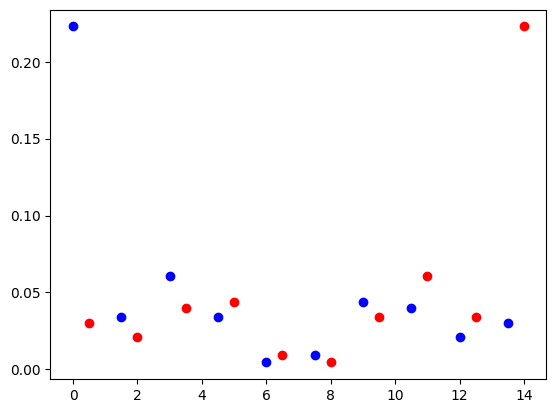

eigenvalue:  [ 0.62281079+0.j -5.88675684+0.j]


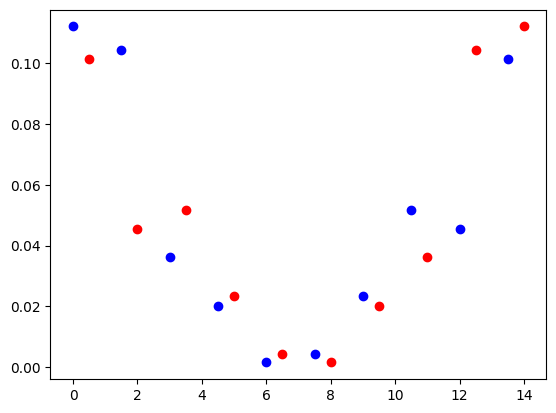

eigenvalue:  [ 0.62281079+0.j -5.88675684+0.j]


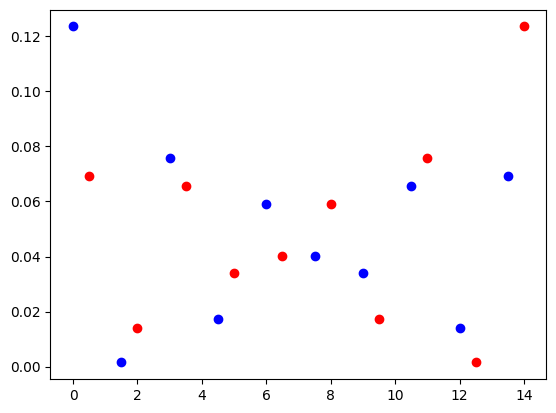

In [13]:
def find_edge_states(vec):
    return np.abs(vec[:,1])**2+np.abs(vec[:,latticeA.shape[1]])**2+np.abs(vec[:,latticeA.shape[1]+1])**2+np.abs(vec[:,(latticeA.shape[1])*2])**2\
    + np.abs(vec[:,2*latticeA.shape[1]+1])**2+np.abs(vec[:,latticeB.shape[1]+2*latticeA.shape[1]])**2+np.abs(vec[:,2*latticeA.shape[1]+latticeB.shape[1]+1])**2+np.abs(vec[:,2*latticeA.shape[1]+(latticeB.shape[1])*2])**2


# for n in range(alphas.shape[0]):72/180*np.pi
for n in range(1):
    dmat, latticeA, latticeB, chain_length = open_D_mat(1,np.pi/3,chain_length,bare_interaction,no_onsite_interaction,100)
    eig, vecs = np.linalg.eig(dmat)
    
    eigenvals[n]= sort_eigenvalues(eig,vecs)
    edge_indicator = find_edge_states(eigenvals[n,:,:])
    edge = sort_eigenvalues(edge_indicator, eigenvals[n,:,:].T)[::-1,:]
    fig, ax1 = plt.subplots(1,1)
    ax1.scatter(np.arange(edge.shape[0]), eigenvals[n,:,0] , color='black', s=10)
    # plt.show()#edge[:,0]
    ax1.hlines(edge[:4,1], np.zeros(4), np.ones(4)*40 , color='red', alpha=0.5)
    plt.show()
    for ind in range(4):
        fig, ax = plt.subplots(1,1)
        vecA = np.abs(edge[ind,2:latticeA.shape[1]+2])**2 + np.abs(edge[ind,latticeA.shape[1]+2:2*latticeA.shape[1]+2])**2
        vecB = np.abs(edge[ind,2*latticeA.shape[1]+2:2*latticeA.shape[1]+2+latticeB.shape[1]])**2 + np.abs(edge[ind,2*latticeA.shape[1]+2+latticeB.shape[1]:2*latticeA.shape[1]+2+latticeB.shape[1]*2:])**2

        print('eigenvalue: ', edge[0,:2])
        # print('eig: ', vecA[n,:])
        ax.scatter(latticeA[0,:],vecA, color='blue')
        ax.scatter(latticeB[0,:],vecB, color='red')
        plt.show()


/home/christian/Documents/master/python_env/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/christian/Documents/master/python_env/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)
/home/christian/Documents/master/python_env/lib/python3.12/site-packages/numpy/ma/core.py:3463: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval


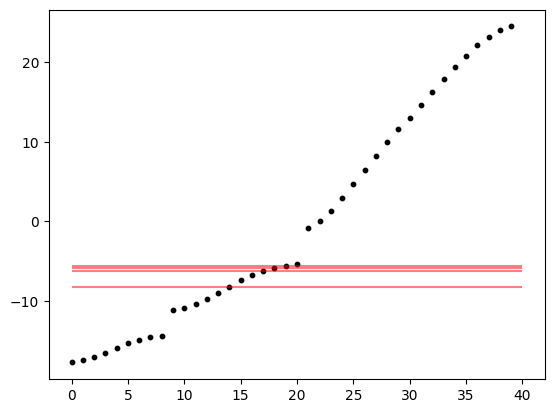

eigenvalue:  [ 0.62281079+0.j -5.88675684+0.j]


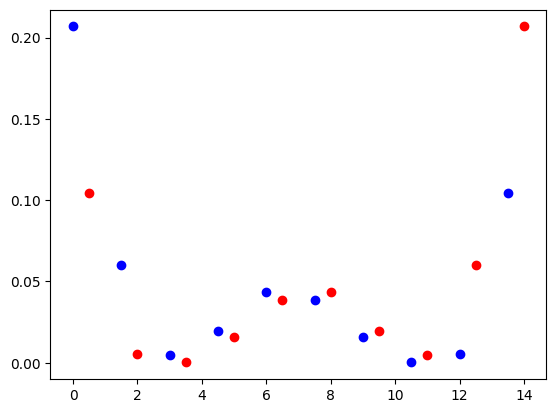

eigenvalue:  [ 0.62281079+0.j -5.88675684+0.j]


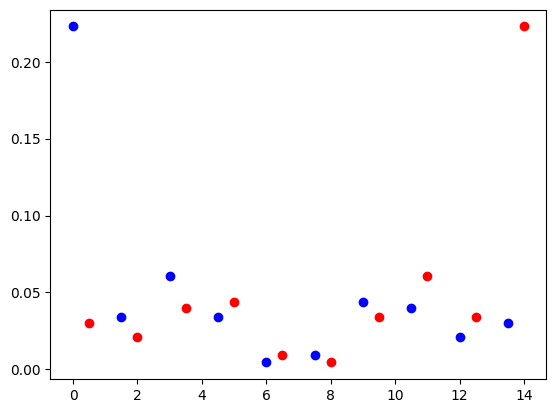

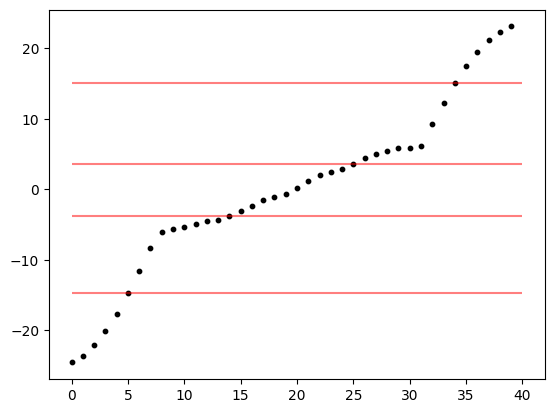

eigenvalue:  [0.29825827+0.j 3.66912865+0.j]


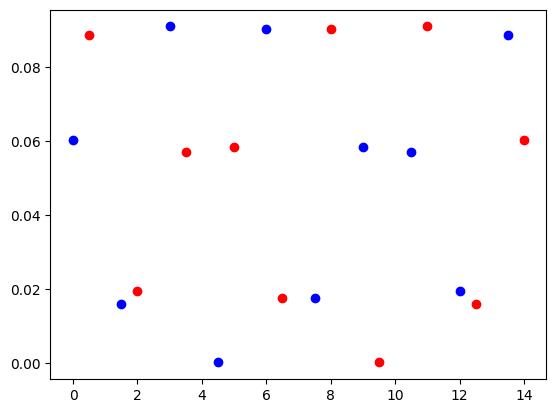

eigenvalue:  [0.29825827+0.j 3.66912865+0.j]


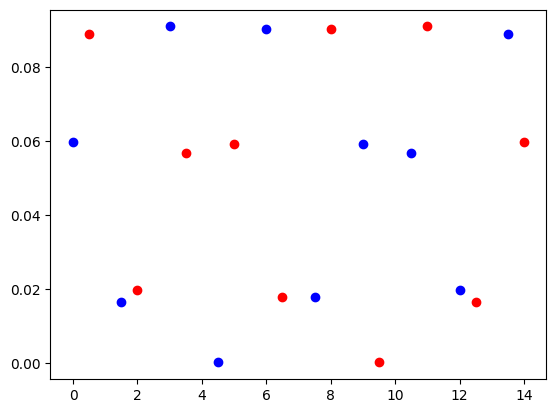

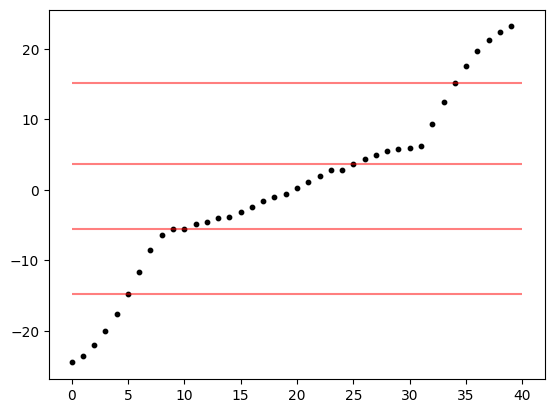

eigenvalue:  [ 0.29650561+0.j 15.15746368+0.j]


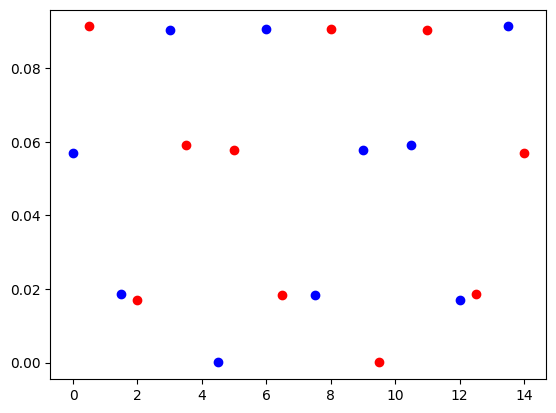

eigenvalue:  [ 0.29650561+0.j 15.15746368+0.j]


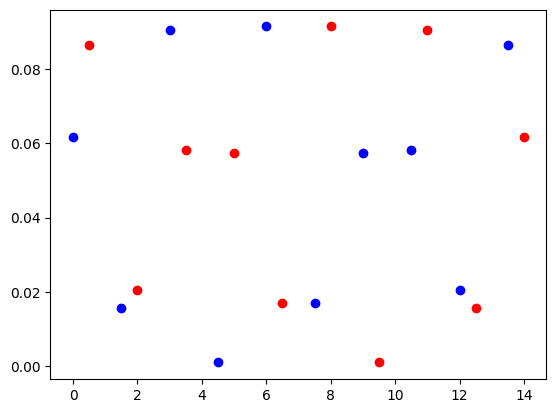

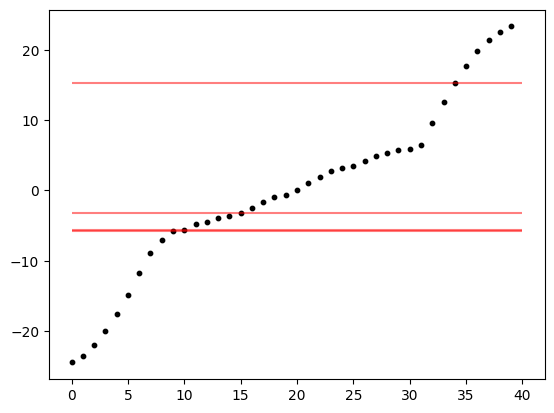

eigenvalue:  [ 0.38239698+0.j -5.68352348+0.j]


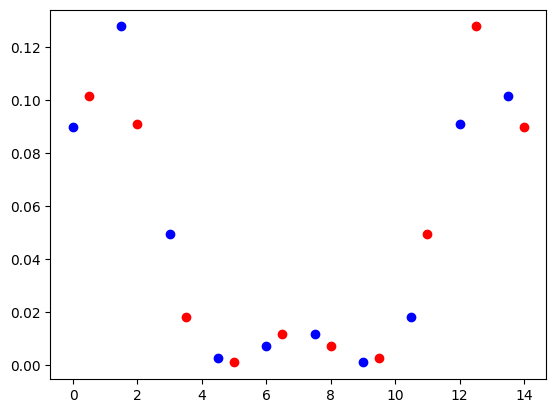

eigenvalue:  [ 0.38239698+0.j -5.68352348+0.j]


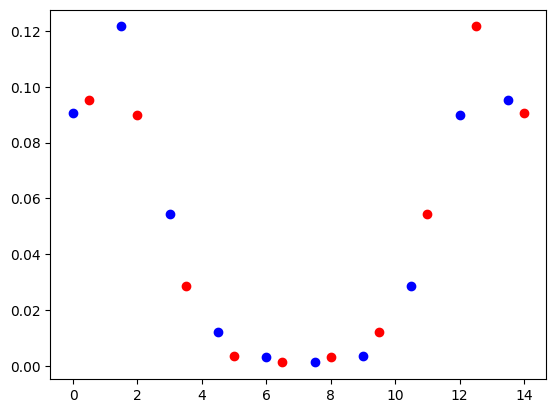

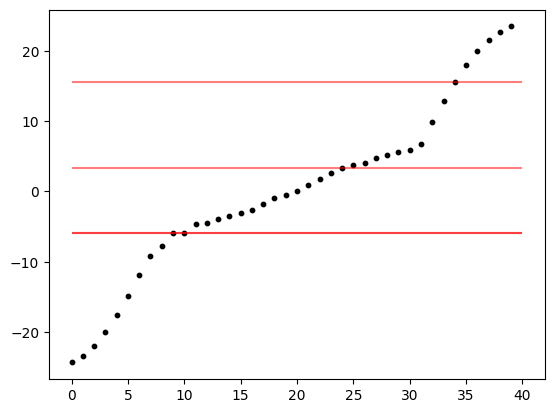

eigenvalue:  [ 0.48869445+0.j -5.9338107 +0.j]


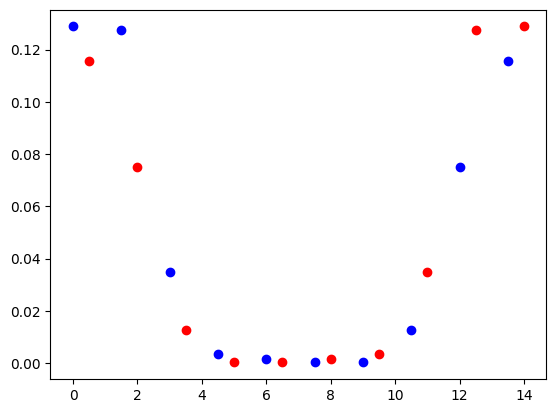

eigenvalue:  [ 0.48869445+0.j -5.9338107 +0.j]


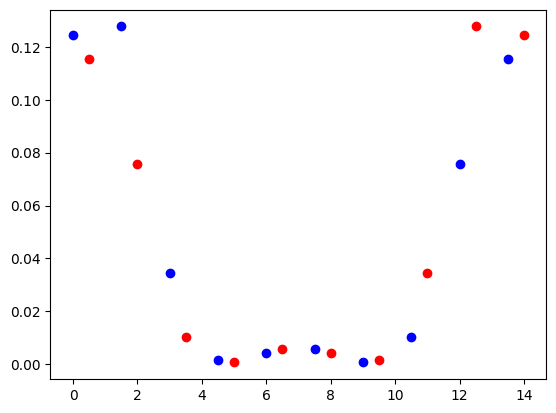

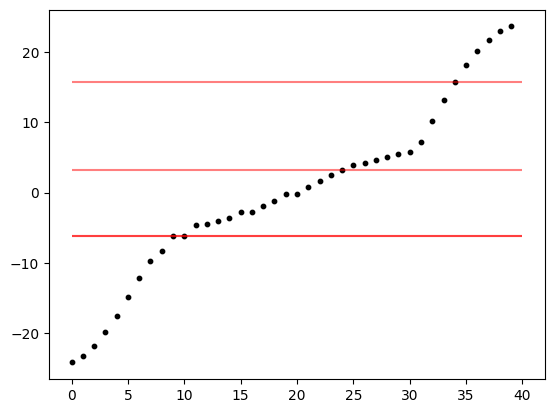

eigenvalue:  [ 0.58010627+0.j -6.20994663+0.j]


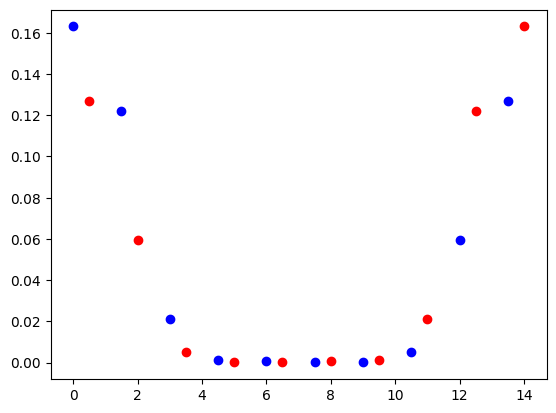

eigenvalue:  [ 0.58010627+0.j -6.20994663+0.j]


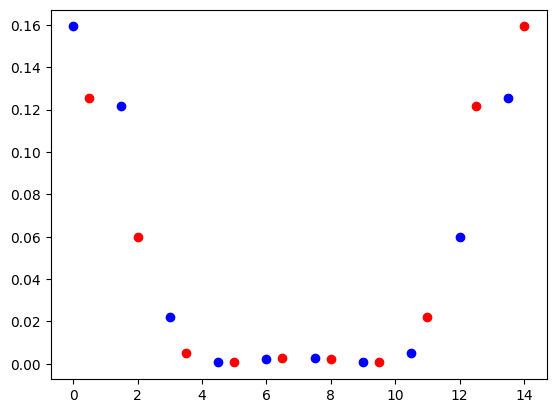

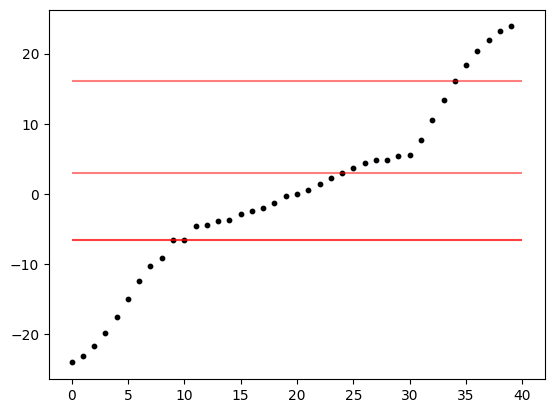

eigenvalue:  [ 0.65561159+0.j -6.51991608+0.j]


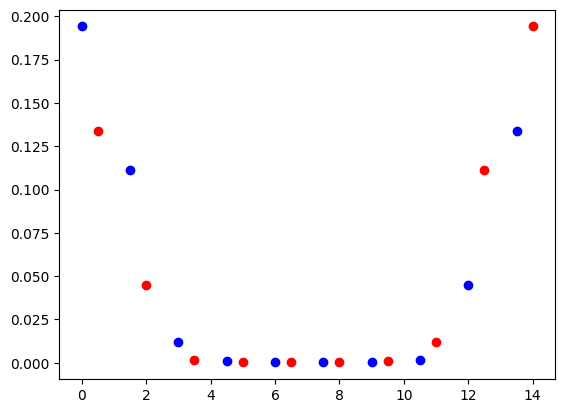

eigenvalue:  [ 0.65561159+0.j -6.51991608+0.j]


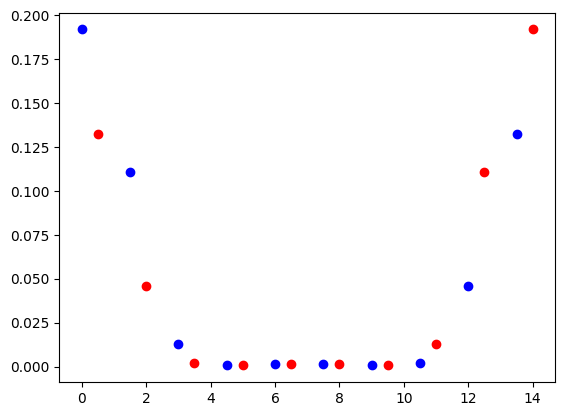

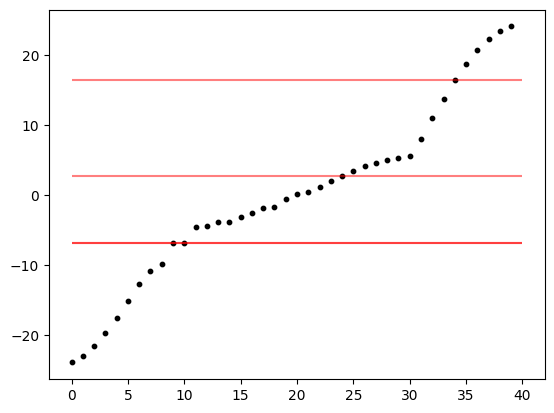

eigenvalue:  [ 0.71999795+0.j -6.84388257+0.j]


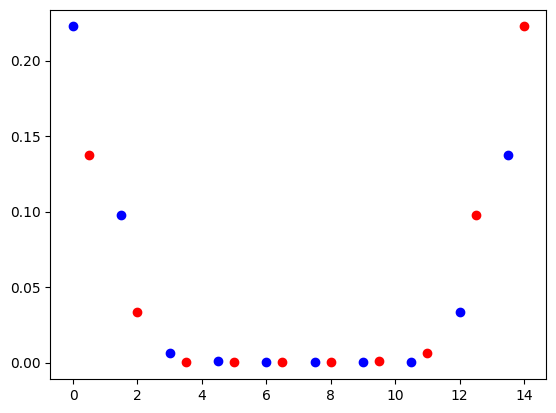

eigenvalue:  [ 0.71999795+0.j -6.84388257+0.j]


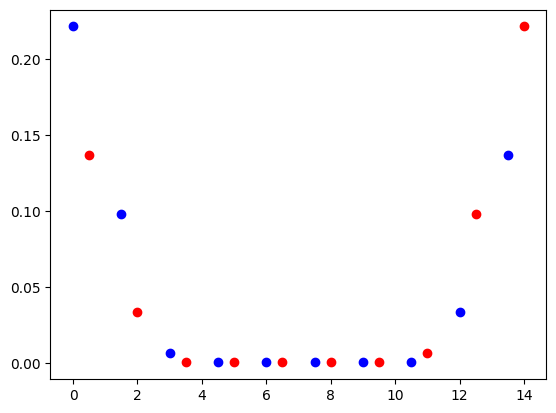

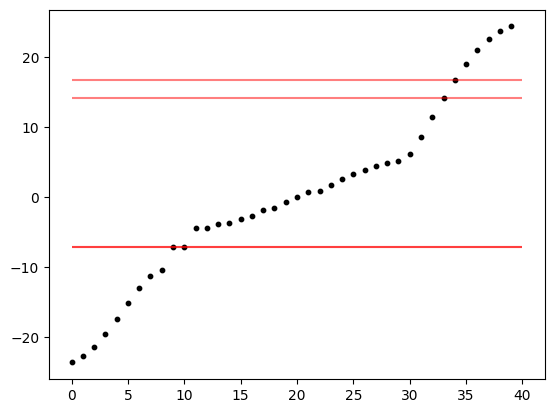

eigenvalue:  [ 0.77540601+0.j -7.16843513+0.j]


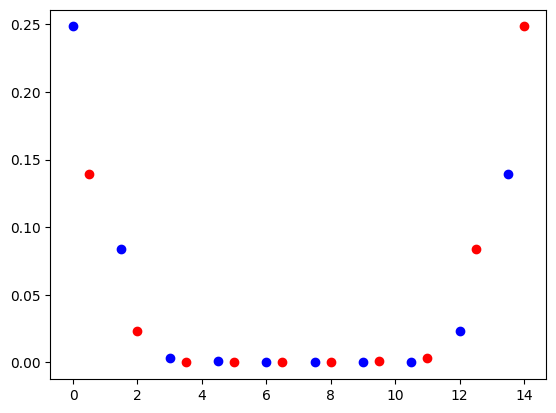

eigenvalue:  [ 0.77540601+0.j -7.16843513+0.j]


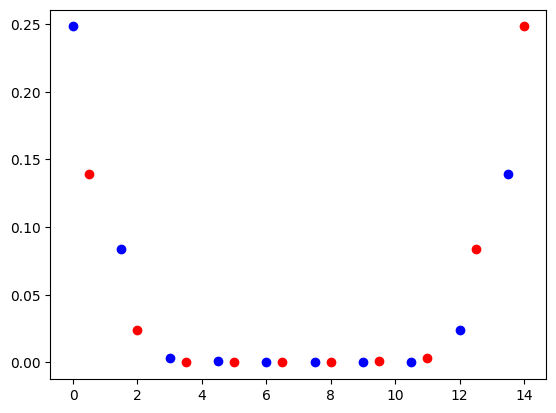

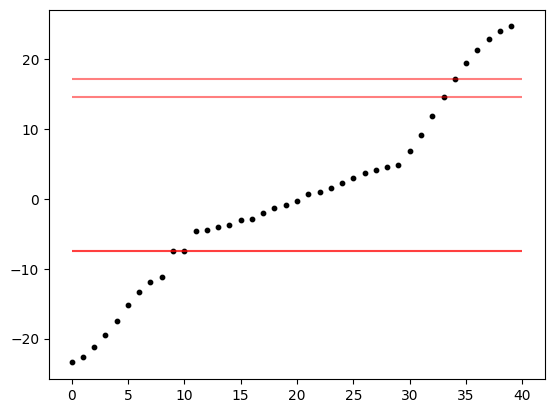

eigenvalue:  [ 0.82331015+0.j -7.48435165+0.j]


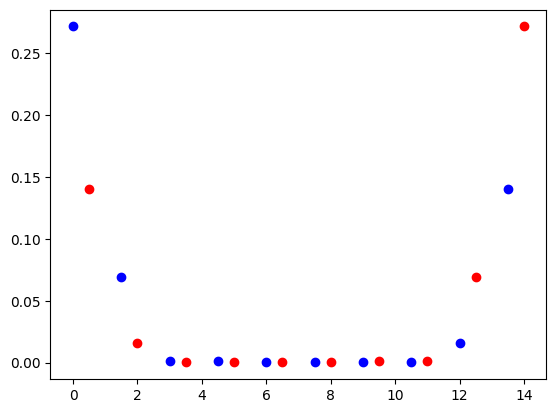

eigenvalue:  [ 0.82331015+0.j -7.48435165+0.j]


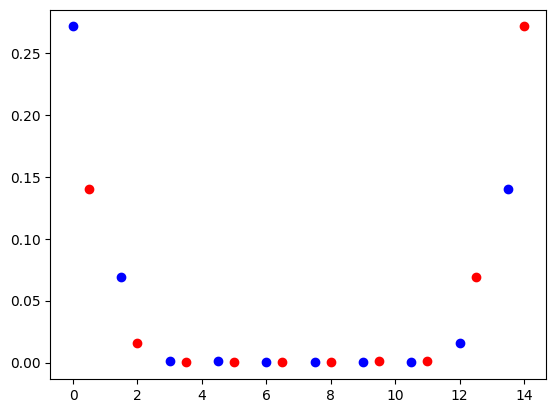

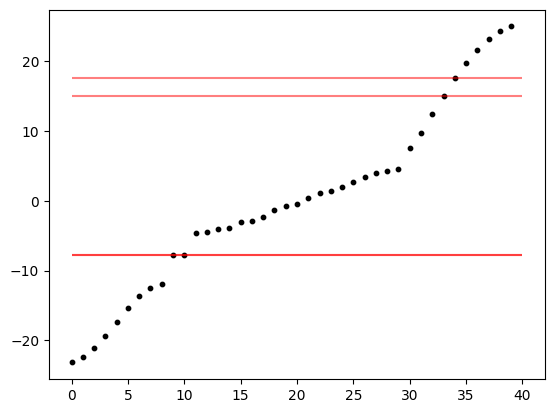

eigenvalue:  [ 0.86353261+0.j -7.78398673+0.j]


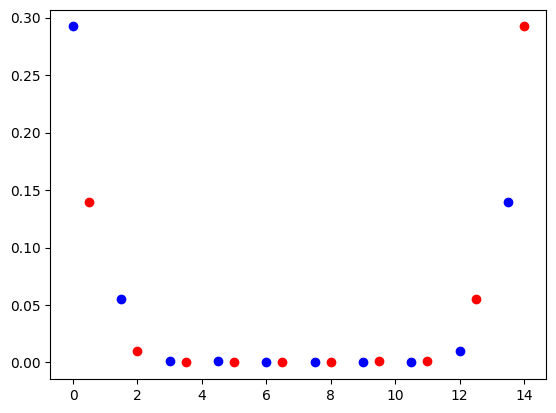

eigenvalue:  [ 0.86353261+0.j -7.78398673+0.j]


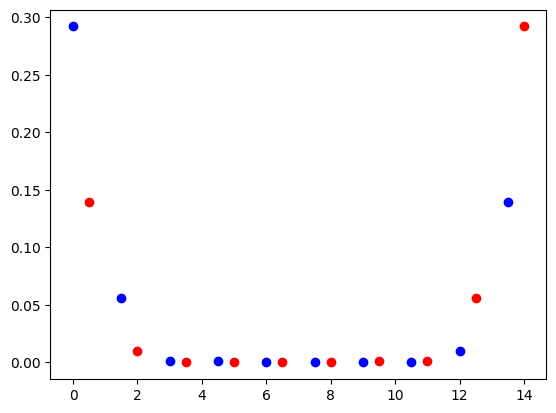

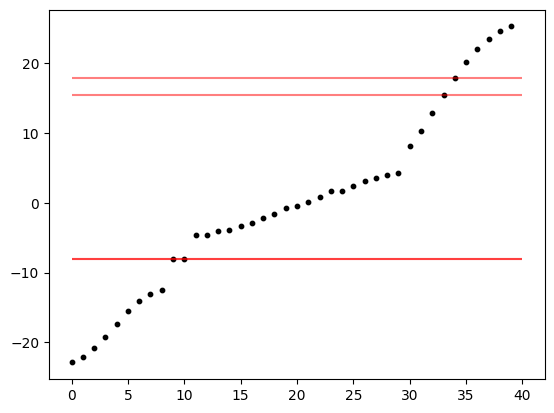

eigenvalue:  [ 0.89637373+0.j -8.06324493+0.j]


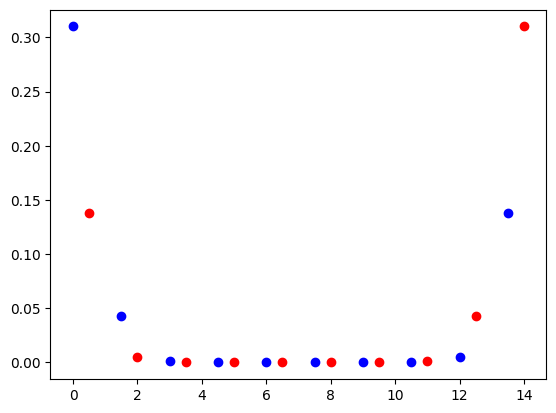

eigenvalue:  [ 0.89637373+0.j -8.06324493+0.j]


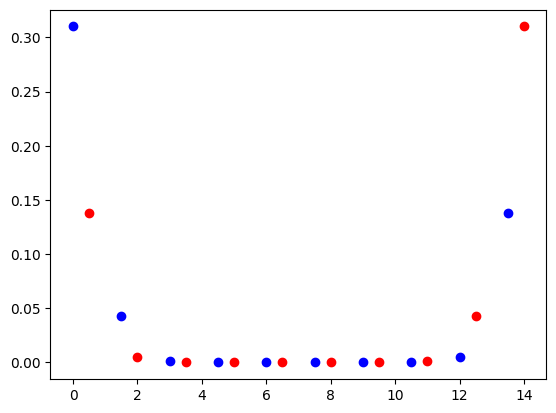

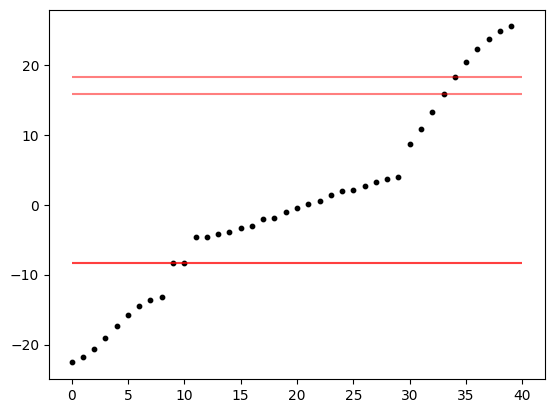

eigenvalue:  [ 0.92253732+0.j -8.31826691+0.j]


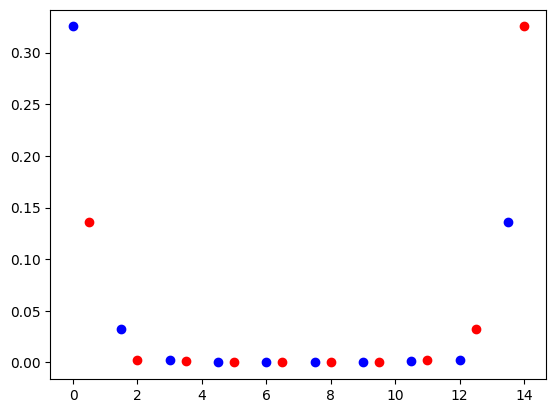

eigenvalue:  [ 0.92253732+0.j -8.31826691+0.j]


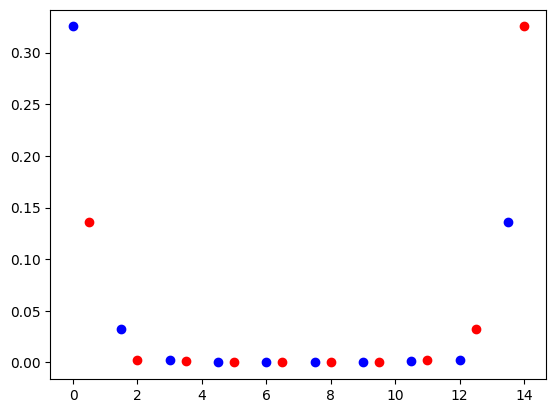

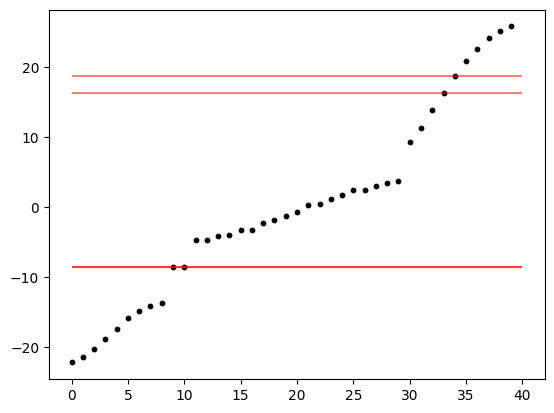

eigenvalue:  [ 0.94269442+0.j -8.54554153+0.j]


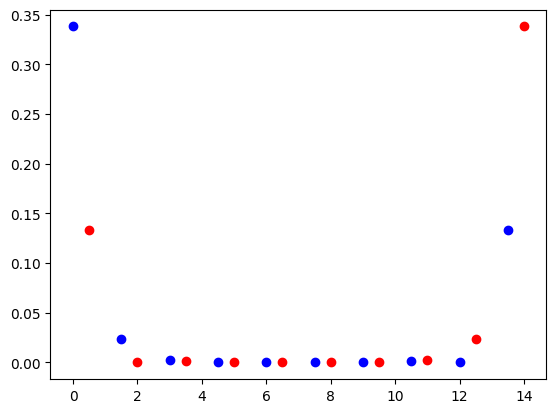

eigenvalue:  [ 0.94269442+0.j -8.54554153+0.j]


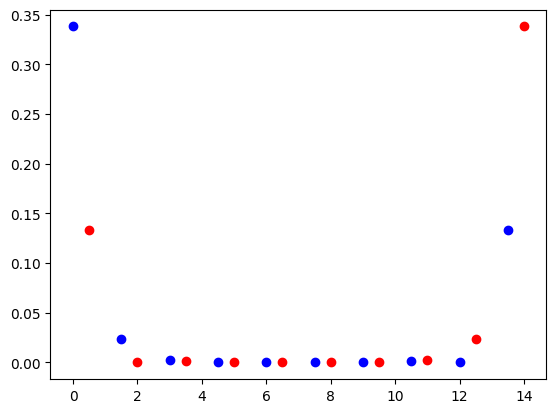

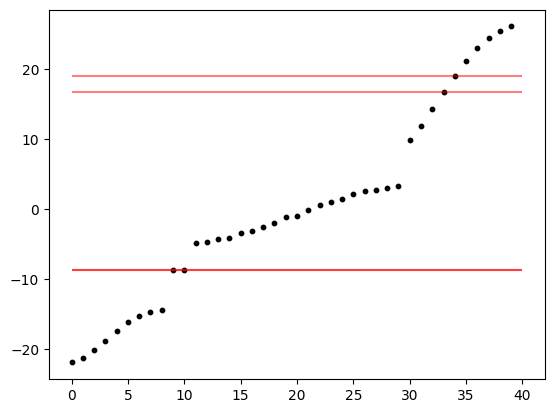

eigenvalue:  [ 0.95702205+0.j -8.74301665+0.j]


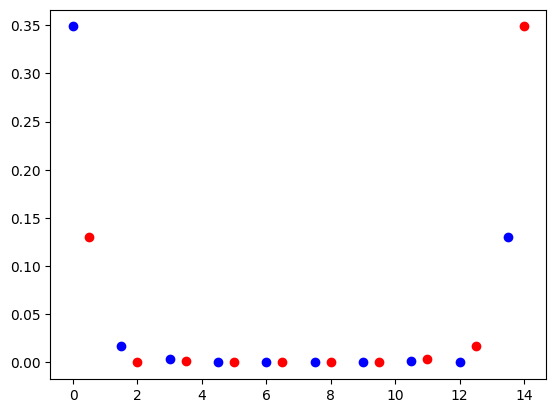

eigenvalue:  [ 0.95702205+0.j -8.74301665+0.j]


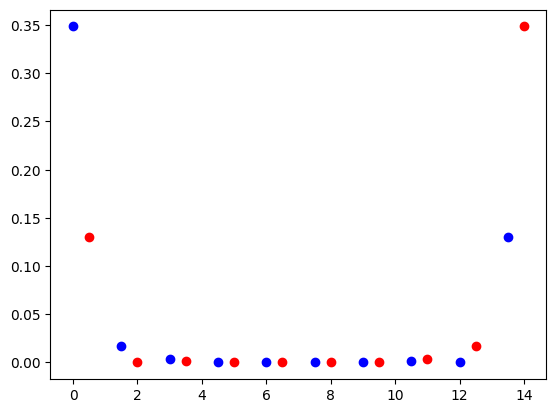

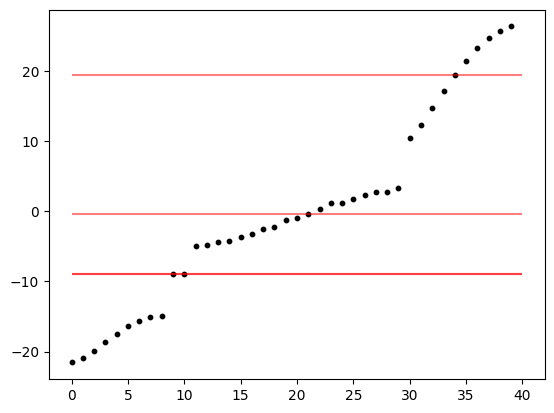

eigenvalue:  [ 0.96602233+0.j -8.9088739 +0.j]


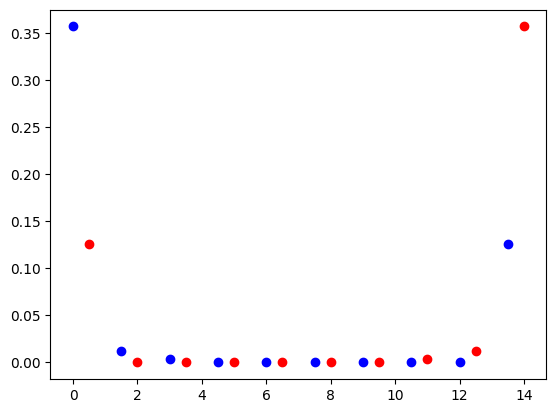

eigenvalue:  [ 0.96602233+0.j -8.9088739 +0.j]


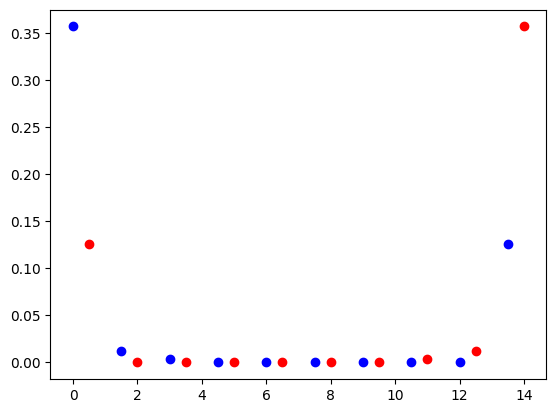

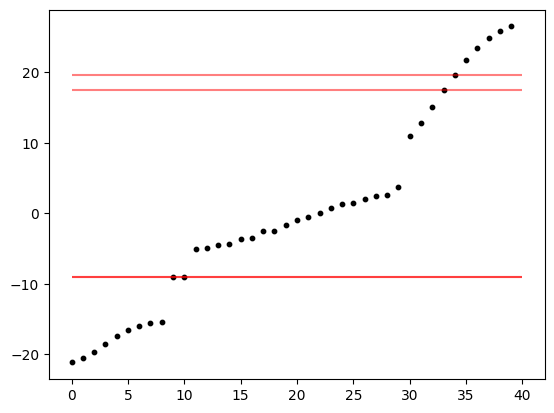

eigenvalue:  [ 0.97028386+0.j -9.04170095+0.j]


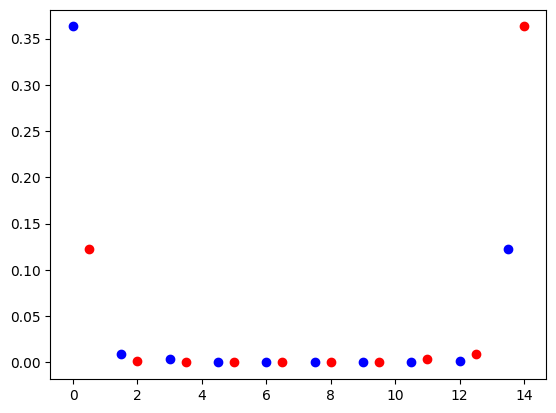

eigenvalue:  [ 0.97028386+0.j -9.04170095+0.j]


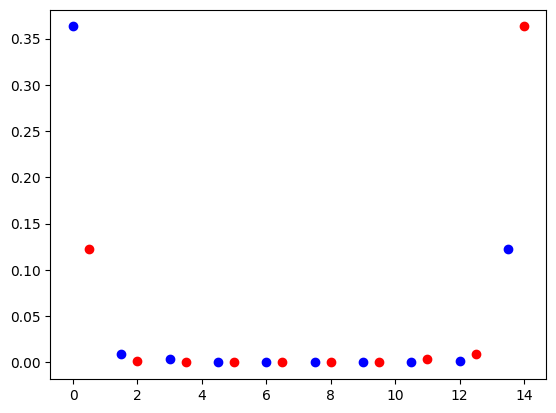

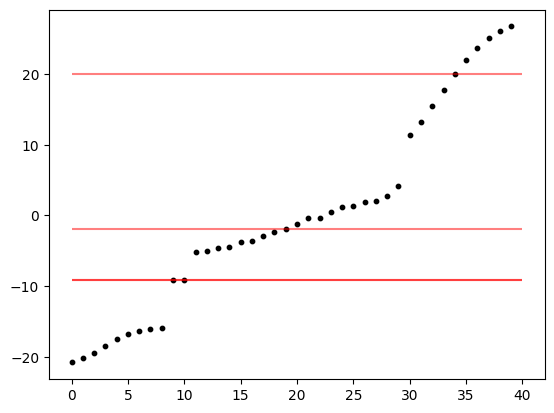

eigenvalue:  [ 0.9701742 +0.j -9.14042379+0.j]


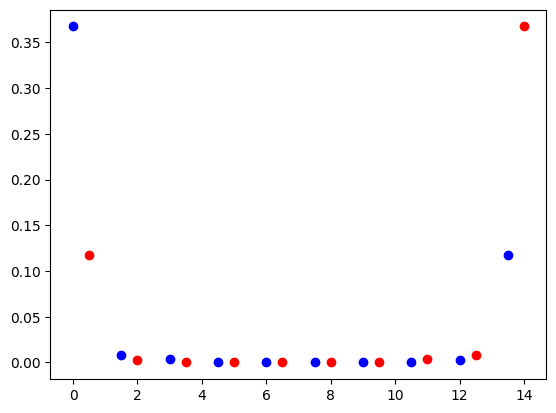

eigenvalue:  [ 0.9701742 +0.j -9.14042379+0.j]


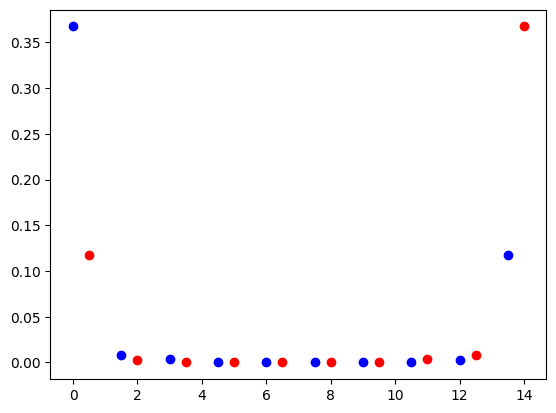

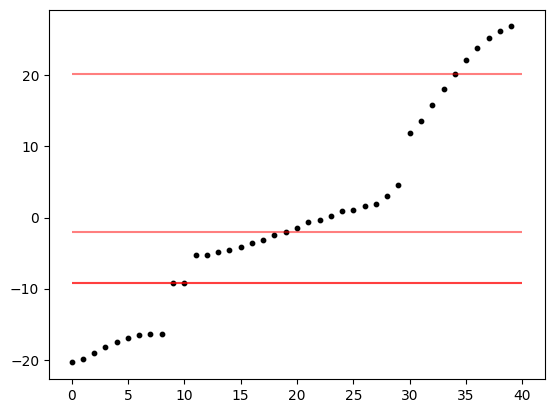

eigenvalue:  [ 0.96613522+0.j -9.20452312+0.j]


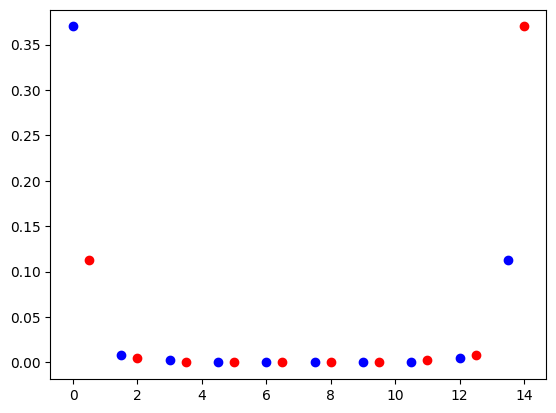

eigenvalue:  [ 0.96613522+0.j -9.20452312+0.j]


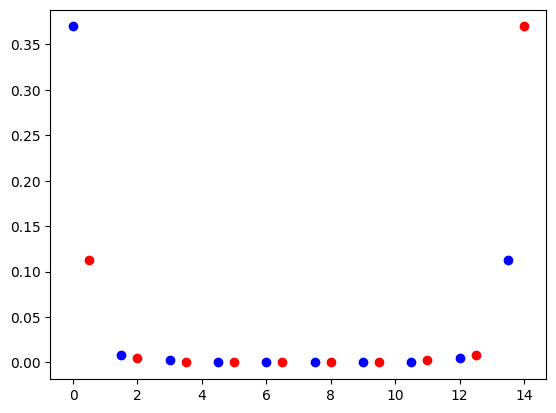

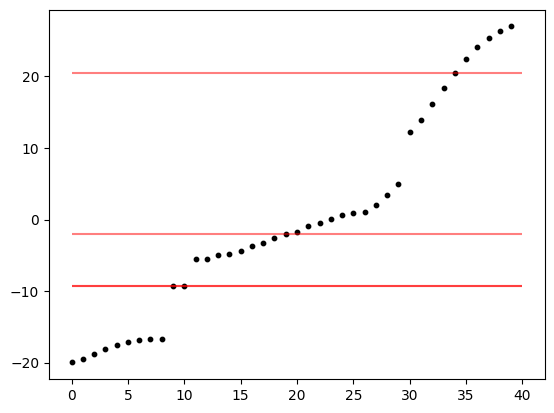

eigenvalue:  [ 0.95866455+0.j -9.23372929+0.j]


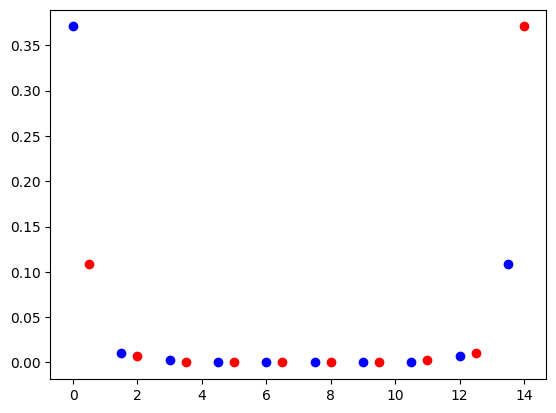

eigenvalue:  [ 0.95866455+0.j -9.23372929+0.j]


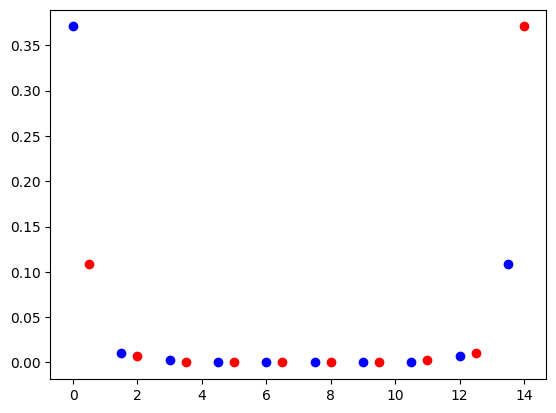

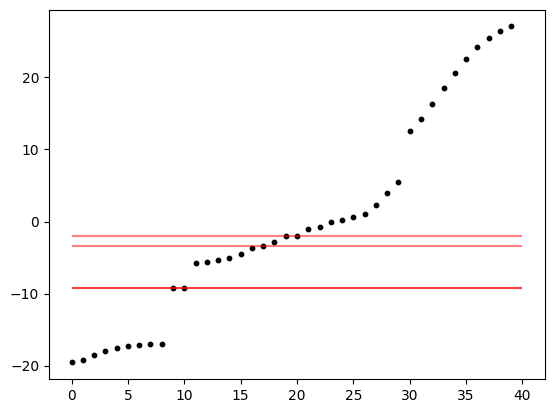

eigenvalue:  [ 0.94807086+0.j -9.22804743+0.j]


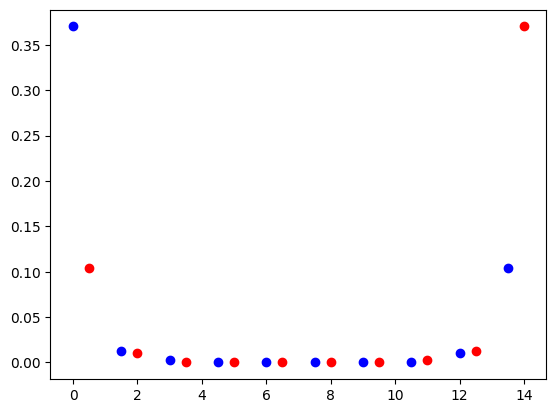

eigenvalue:  [ 0.94807086+0.j -9.22804743+0.j]


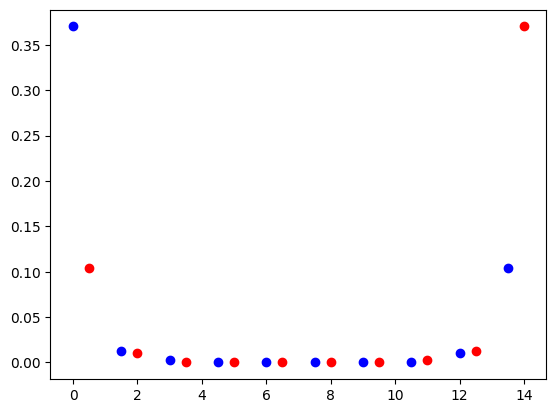

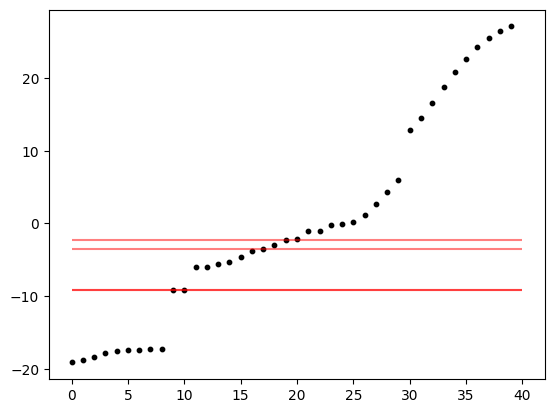

eigenvalue:  [ 0.93443527+0.j -9.1881476 +0.j]


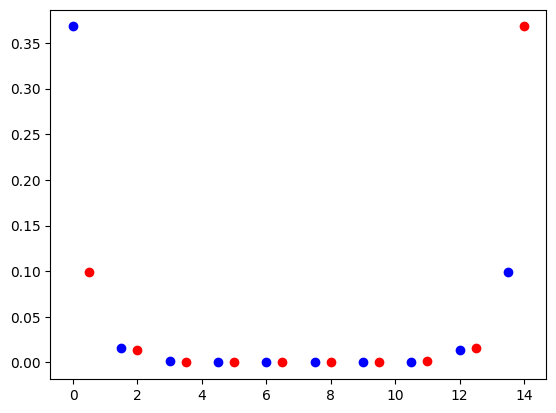

eigenvalue:  [ 0.93443527+0.j -9.1881476 +0.j]


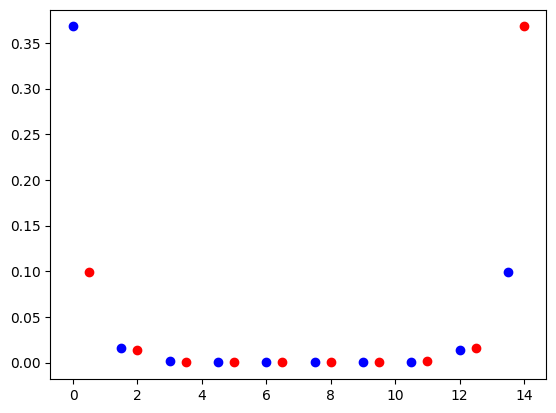

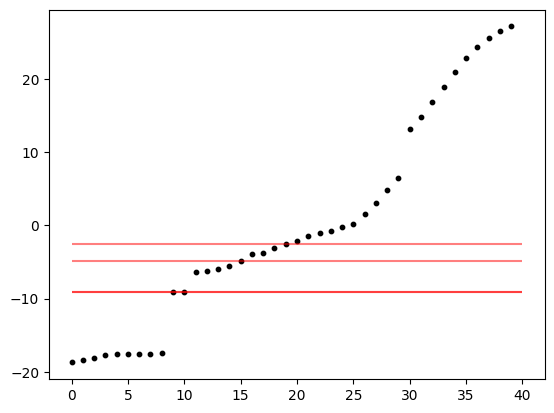

eigenvalue:  [ 0.91747063+0.j -9.11537461+0.j]


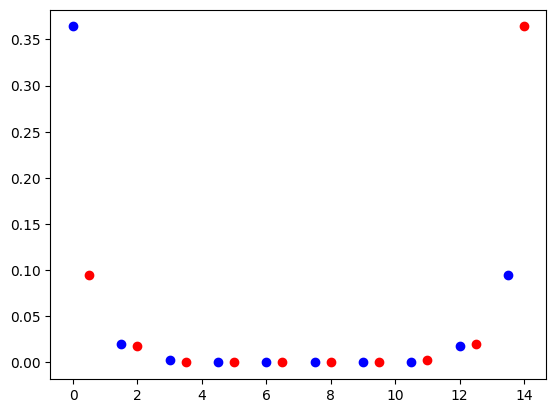

eigenvalue:  [ 0.91747063+0.j -9.11537461+0.j]


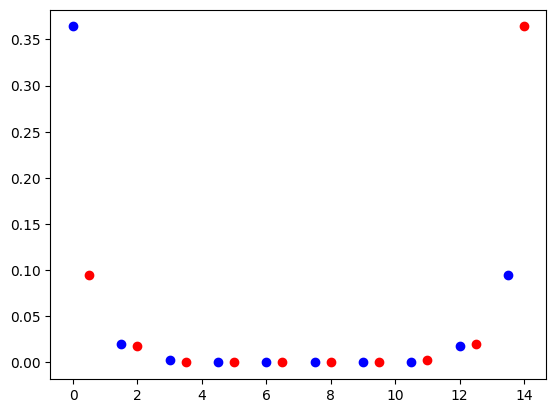

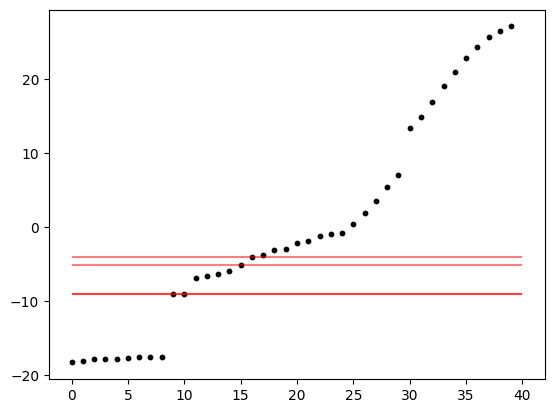

eigenvalue:  [ 0.89617602+0.j -9.01152701+0.j]


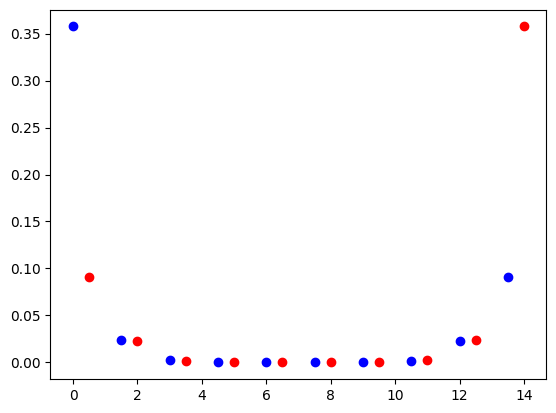

eigenvalue:  [ 0.89617602+0.j -9.01152701+0.j]


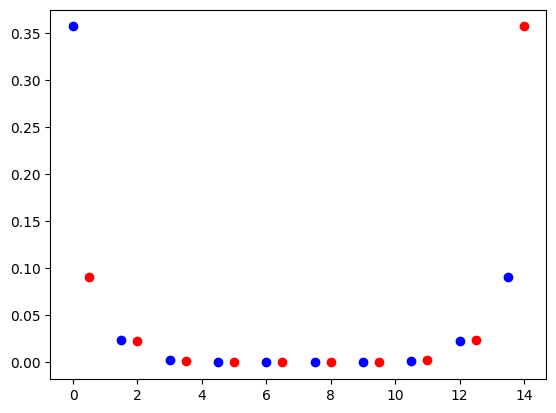

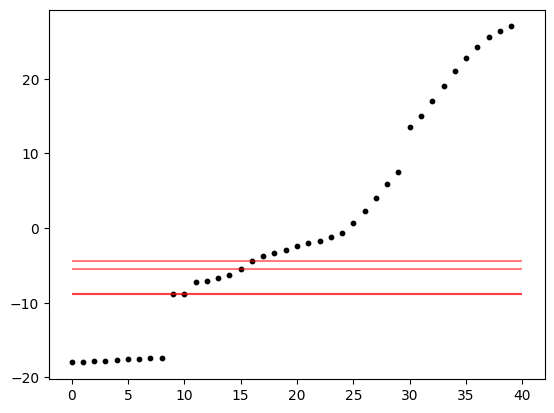

eigenvalue:  [ 0.86618805+0.j -8.8812996 +0.j]


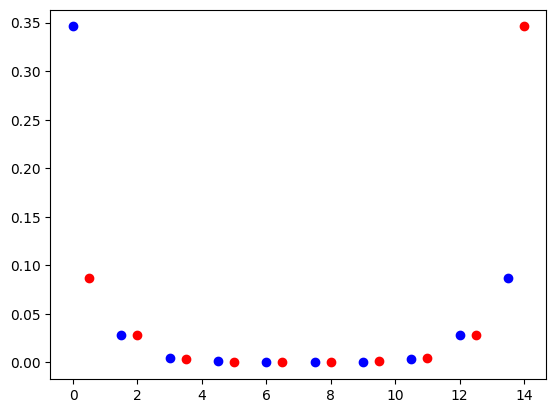

eigenvalue:  [ 0.86618805+0.j -8.8812996 +0.j]


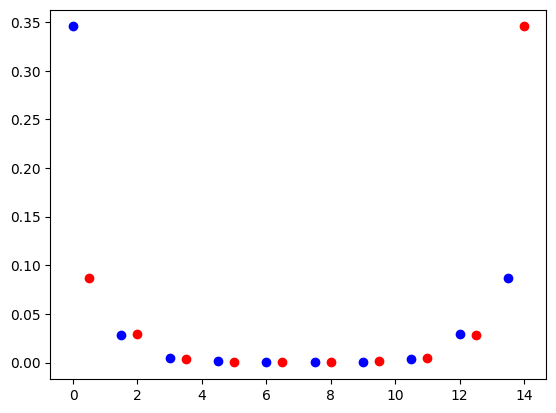

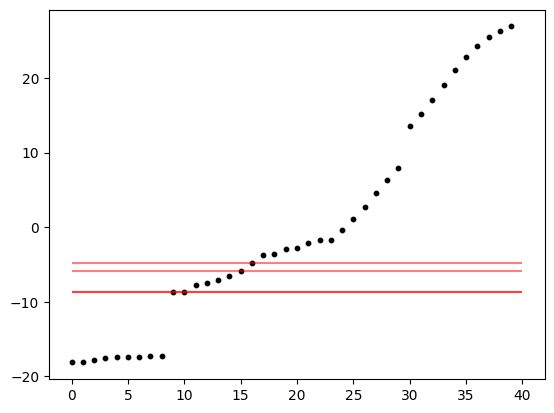

eigenvalue:  [ 0.81086004+0.j -8.73642943+0.j]


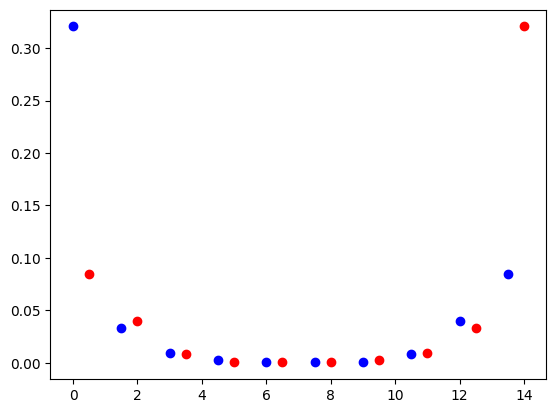

eigenvalue:  [ 0.81086004+0.j -8.73642943+0.j]


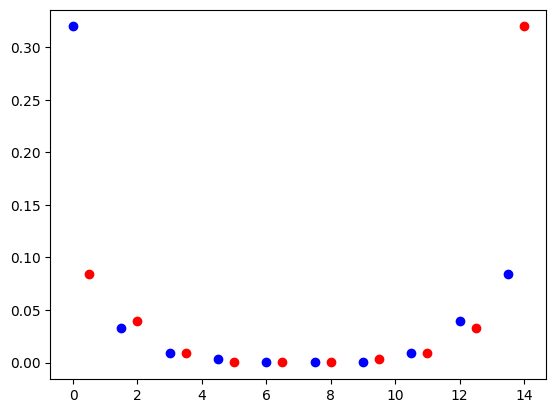

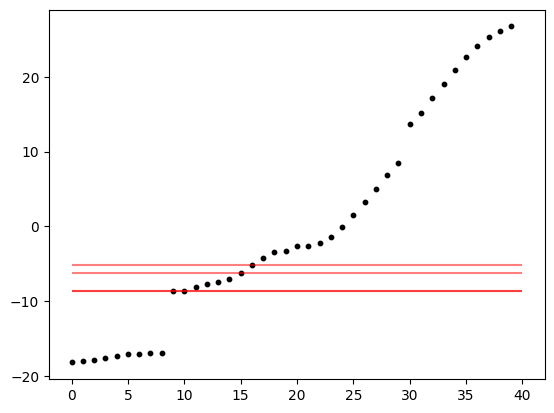

eigenvalue:  [ 0.66040587+0.j -8.62010608+0.j]


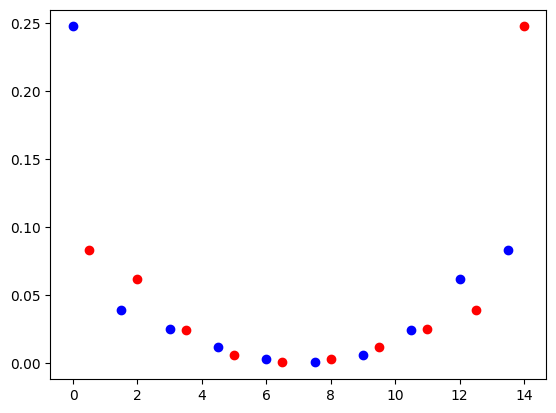

eigenvalue:  [ 0.66040587+0.j -8.62010608+0.j]


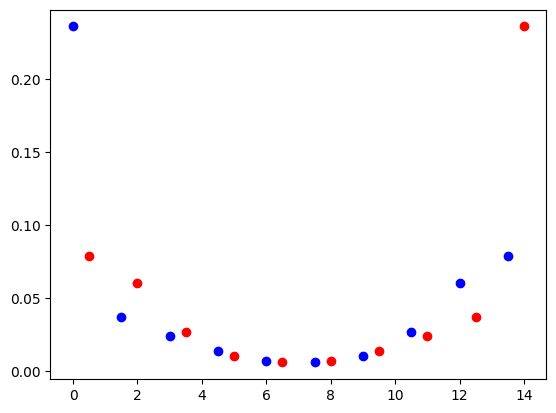

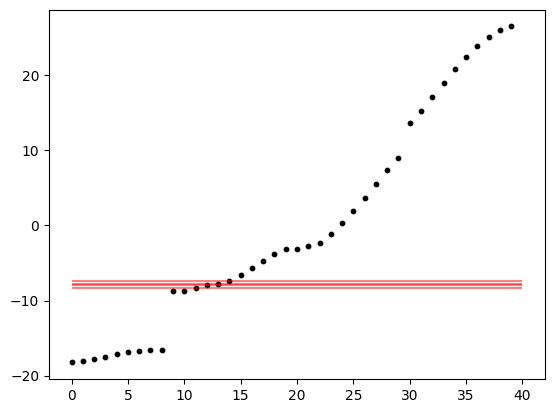

eigenvalue:  [ 0.60058053+0.j -7.9381722 +0.j]


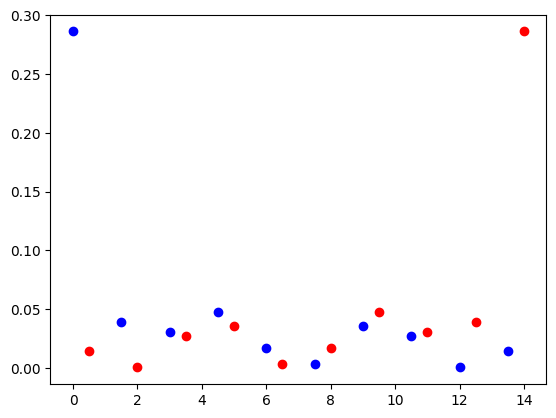

eigenvalue:  [ 0.60058053+0.j -7.9381722 +0.j]


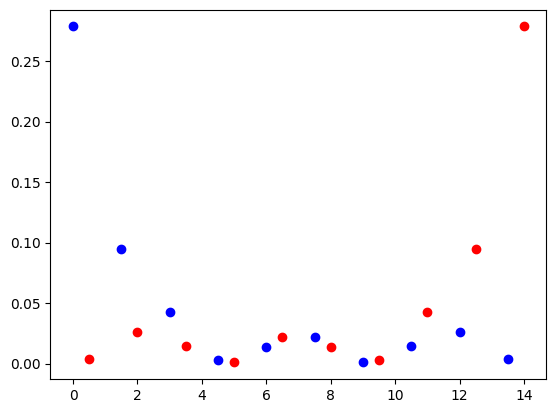

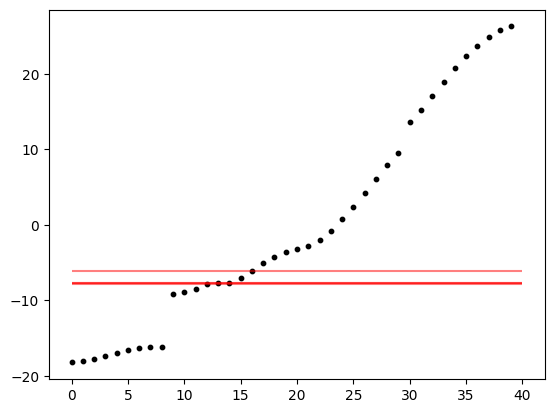

eigenvalue:  [ 0.8461844+0.j -7.7772535+0.j]


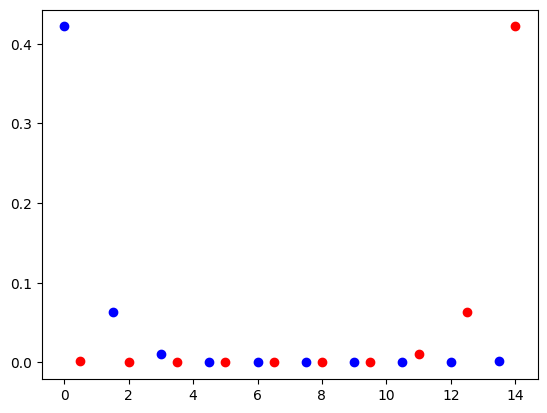

eigenvalue:  [ 0.8461844+0.j -7.7772535+0.j]


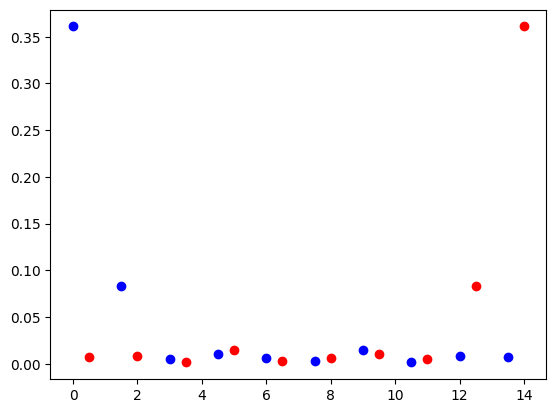

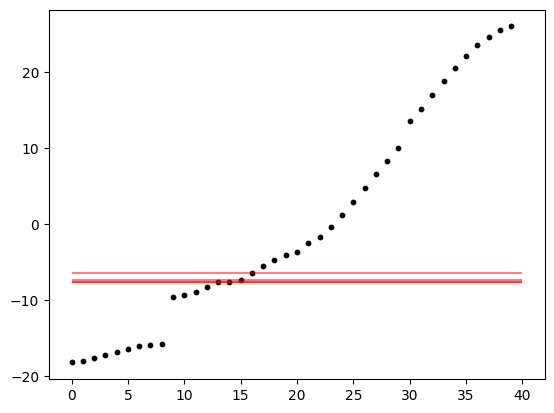

eigenvalue:  [ 0.8566665 +0.j -7.60992815+0.j]


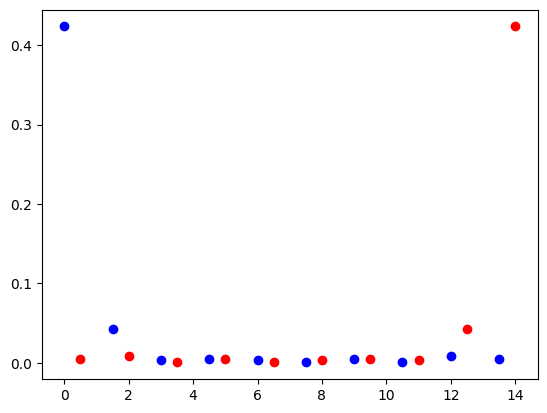

eigenvalue:  [ 0.8566665 +0.j -7.60992815+0.j]


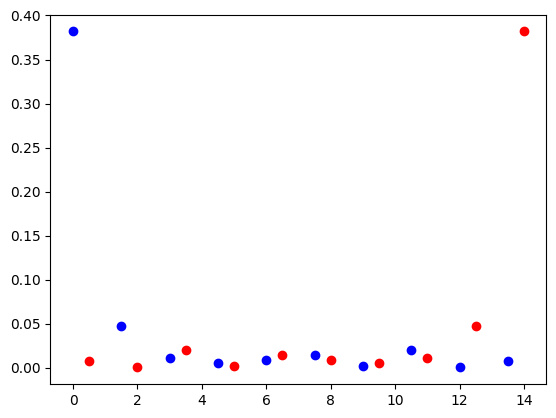

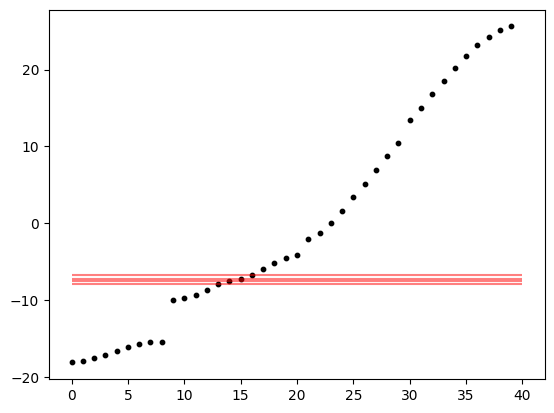

eigenvalue:  [ 0.74080261+0.j -7.46807357+0.j]


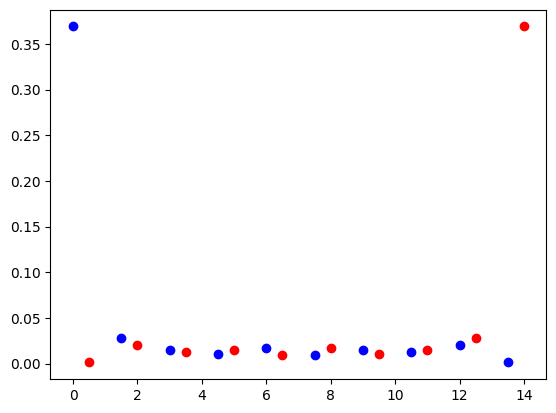

eigenvalue:  [ 0.74080261+0.j -7.46807357+0.j]


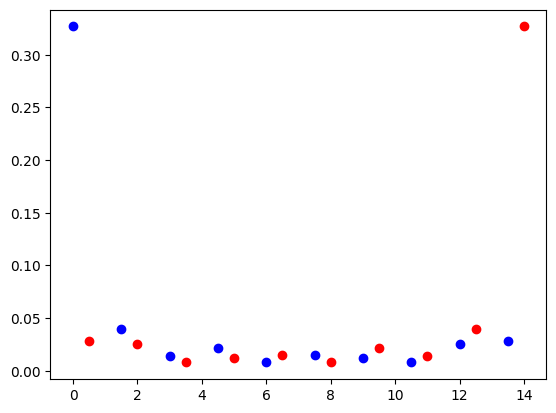

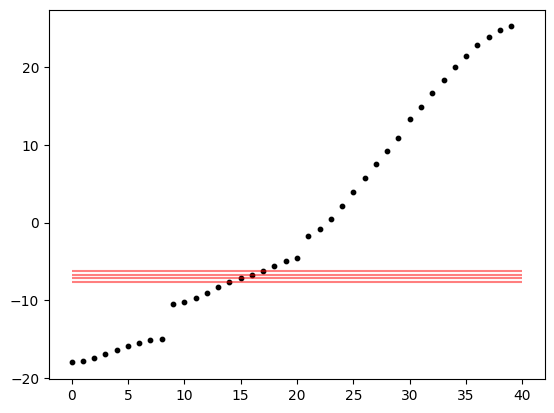

eigenvalue:  [ 0.63433137+0.j -7.11125321+0.j]


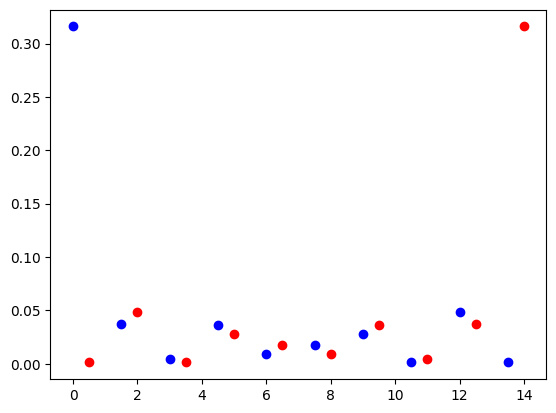

eigenvalue:  [ 0.63433137+0.j -7.11125321+0.j]


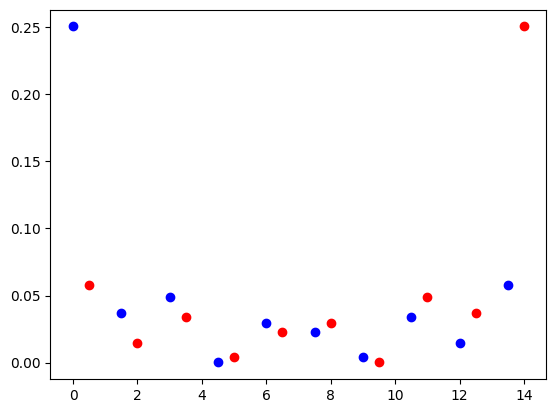

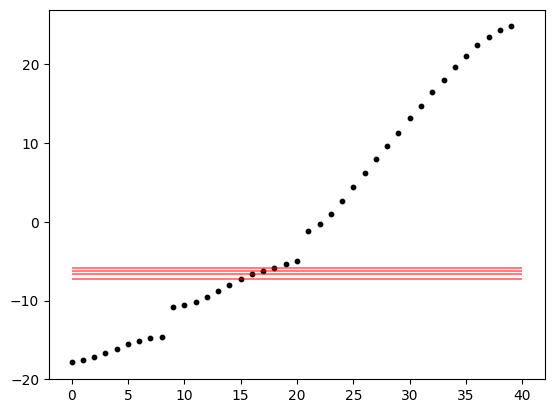

eigenvalue:  [ 0.6057823 +0.j -6.28918484+0.j]


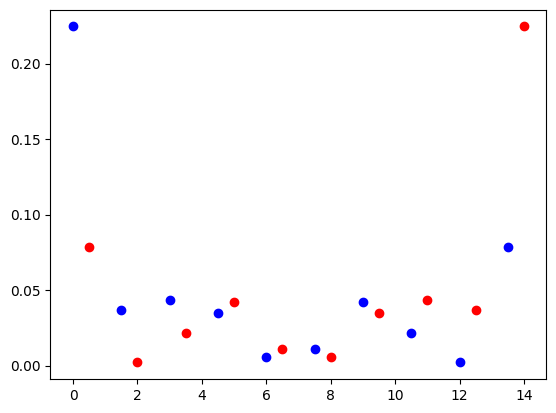

eigenvalue:  [ 0.6057823 +0.j -6.28918484+0.j]


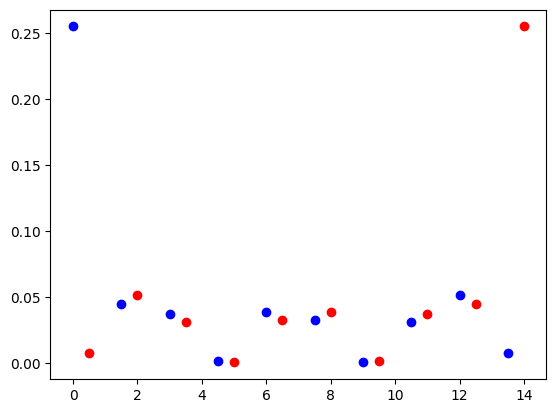

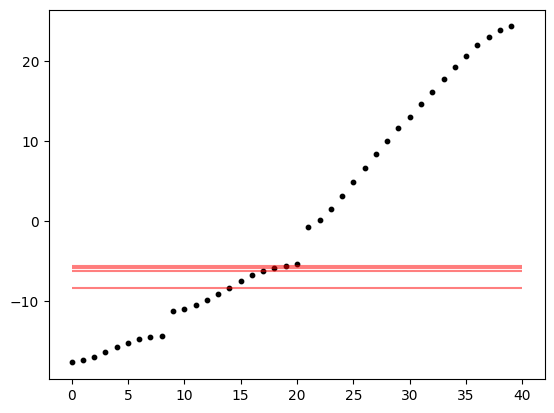

eigenvalue:  [ 0.60186141+0.j -5.85358886+0.j]


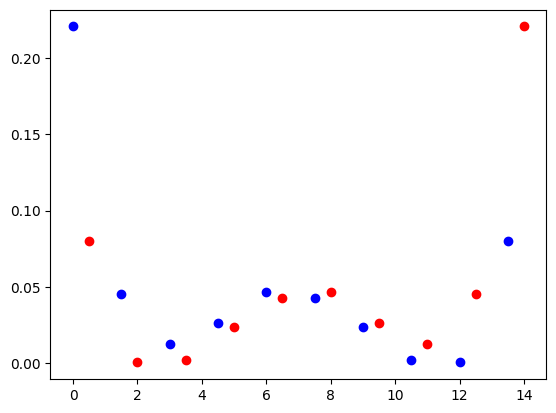

eigenvalue:  [ 0.60186141+0.j -5.85358886+0.j]


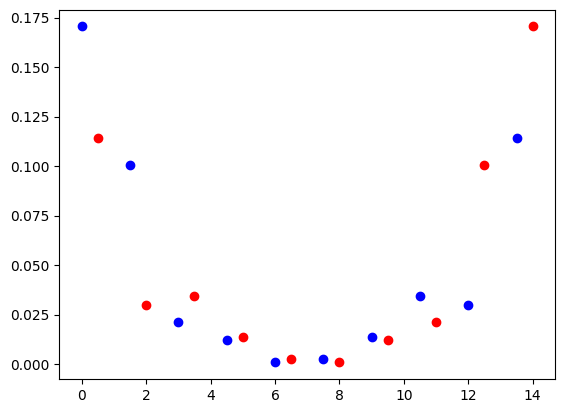

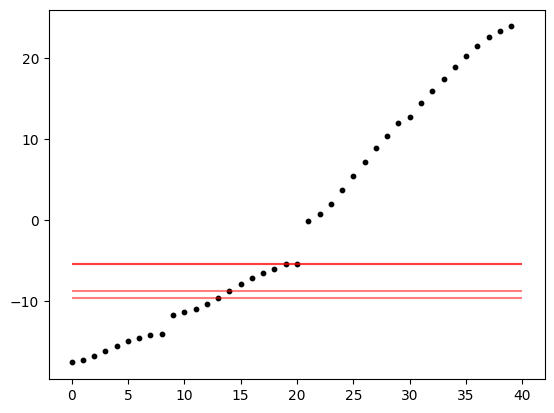

eigenvalue:  [ 0.81650986+0.j -5.43304041+0.j]


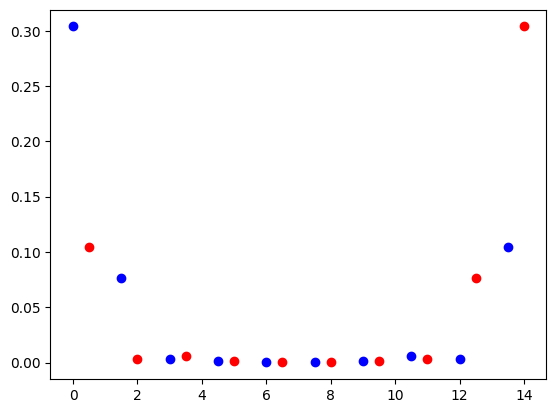

eigenvalue:  [ 0.81650986+0.j -5.43304041+0.j]


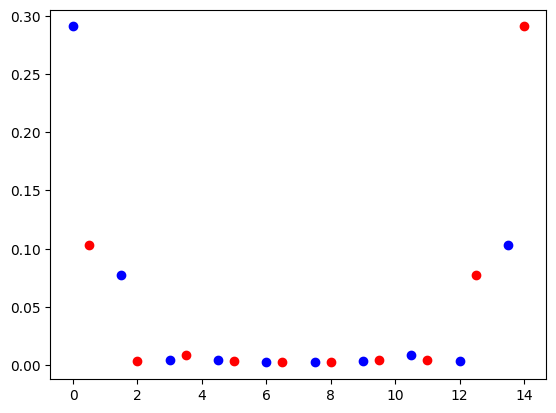

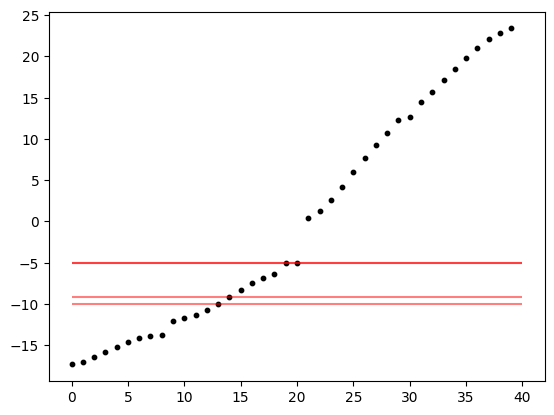

eigenvalue:  [ 0.85924103+0.j -5.08013098+0.j]


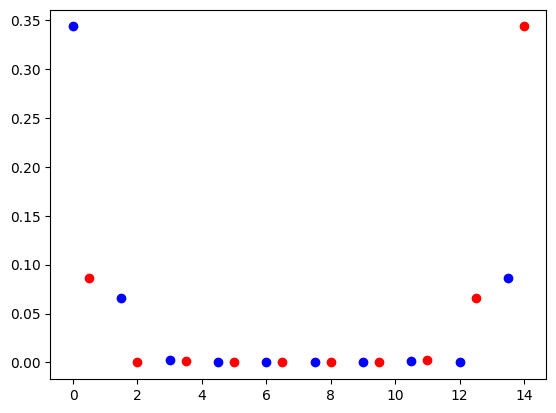

eigenvalue:  [ 0.85924103+0.j -5.08013098+0.j]


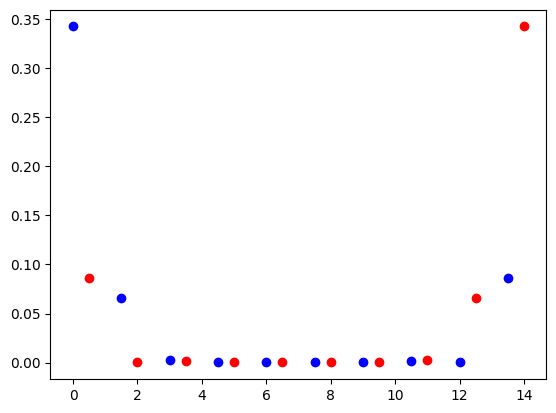

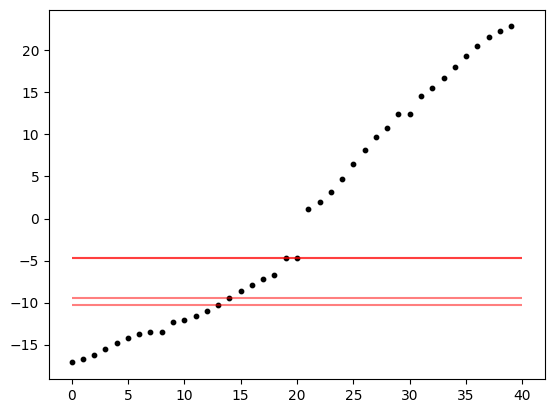

eigenvalue:  [ 0.87342248+0.j -4.68016274+0.j]


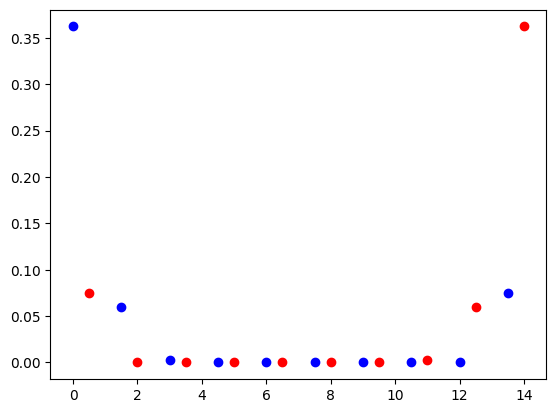

eigenvalue:  [ 0.87342248+0.j -4.68016274+0.j]


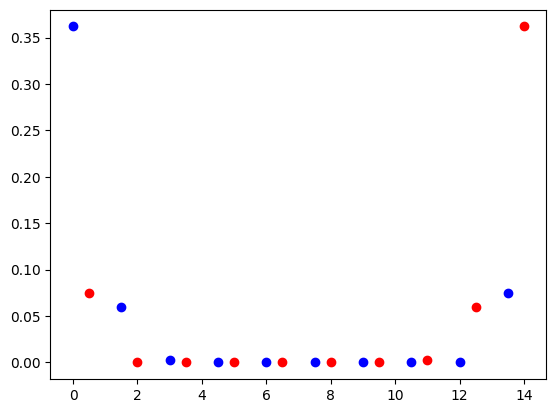

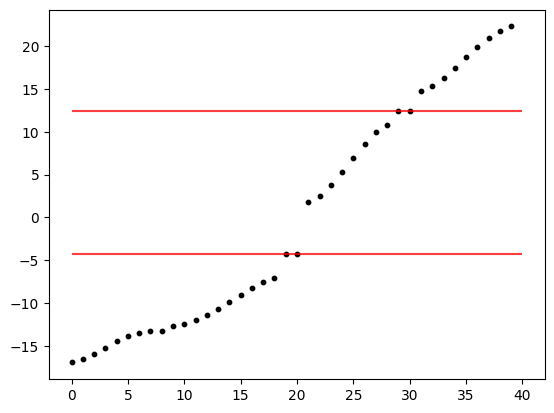

eigenvalue:  [ 0.88274828+0.j -4.26017987+0.j]


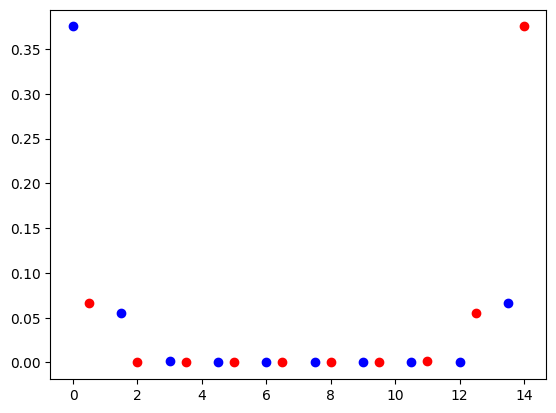

eigenvalue:  [ 0.88274828+0.j -4.26017987+0.j]


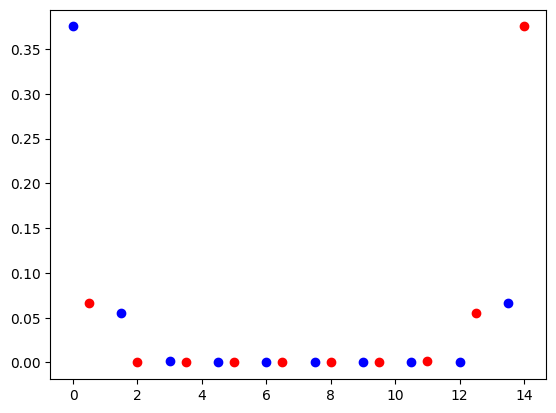

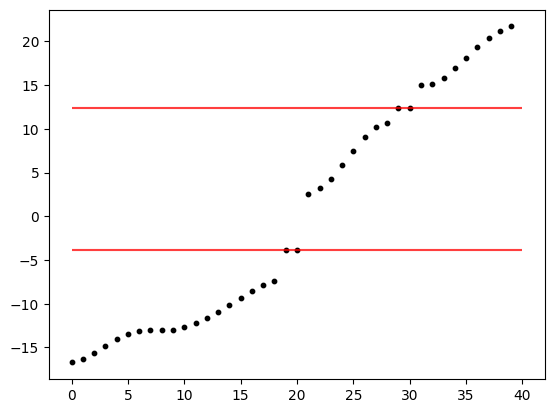

eigenvalue:  [ 0.89099156+0.j -3.83058941+0.j]


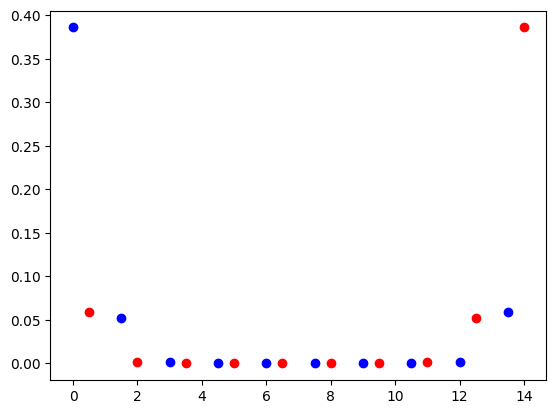

eigenvalue:  [ 0.89099156+0.j -3.83058941+0.j]


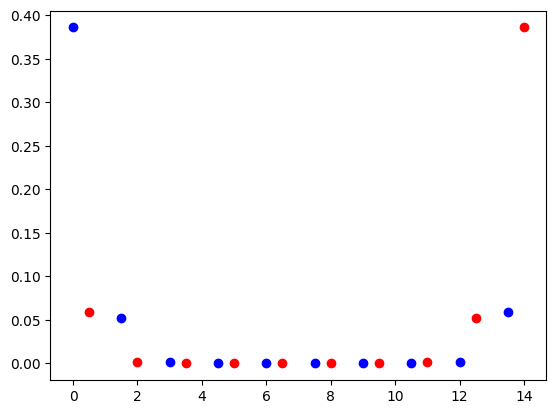

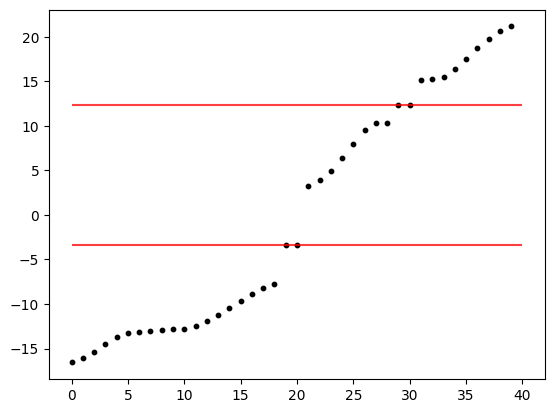

eigenvalue:  [ 0.8987725 +0.j -3.39778234+0.j]


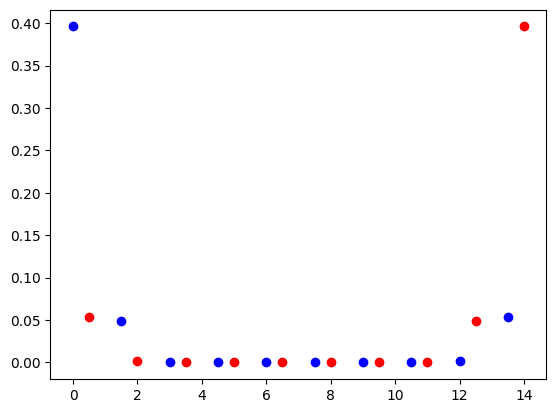

eigenvalue:  [ 0.8987725 +0.j -3.39778234+0.j]


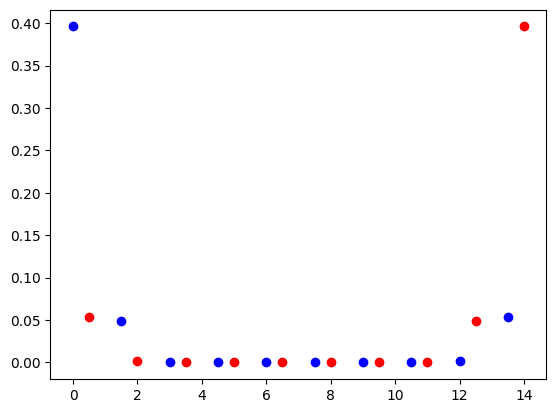

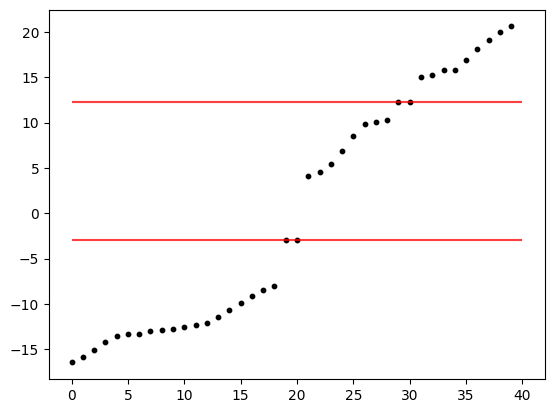

eigenvalue:  [ 0.9058255+0.j -2.9667605+0.j]


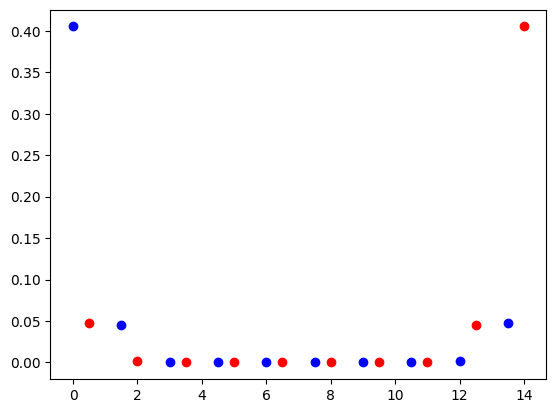

eigenvalue:  [ 0.9058255+0.j -2.9667605+0.j]


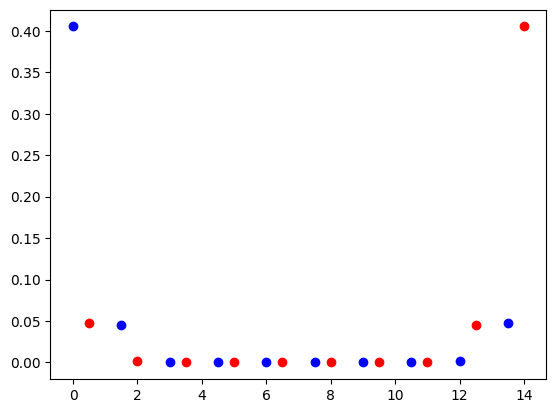

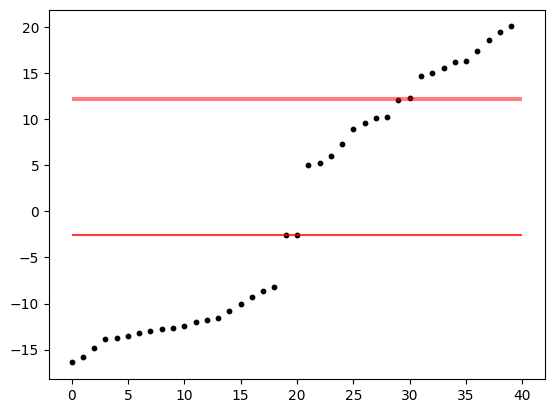

eigenvalue:  [ 0.91139723+0.j -2.54126709+0.j]


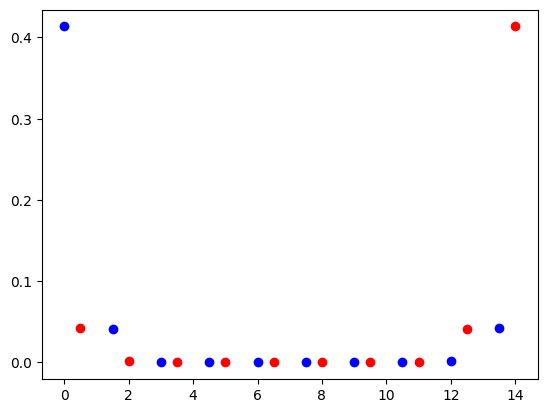

eigenvalue:  [ 0.91139723+0.j -2.54126709+0.j]


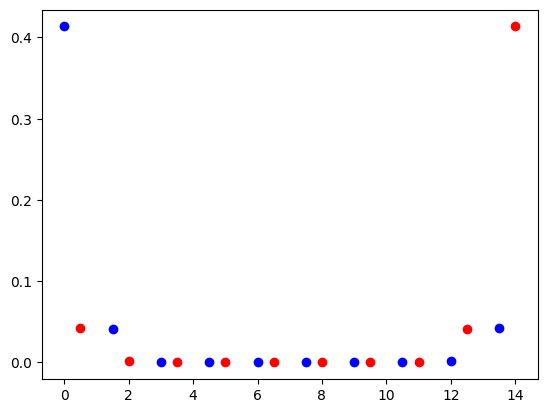

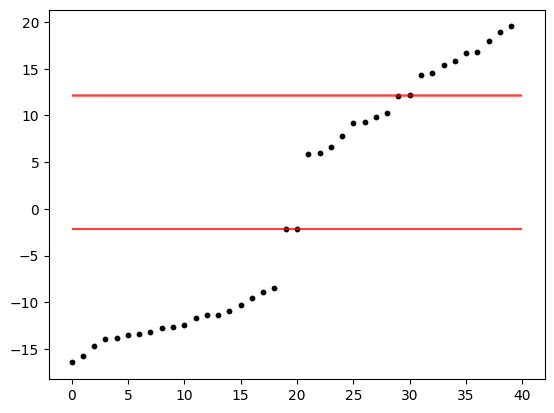

eigenvalue:  [ 0.91430508+0.j -2.12605334+0.j]


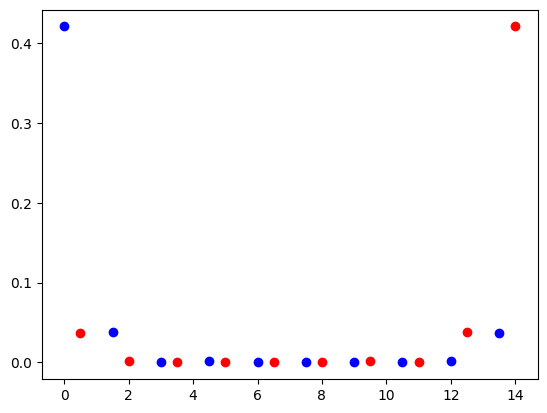

eigenvalue:  [ 0.91430508+0.j -2.12605334+0.j]


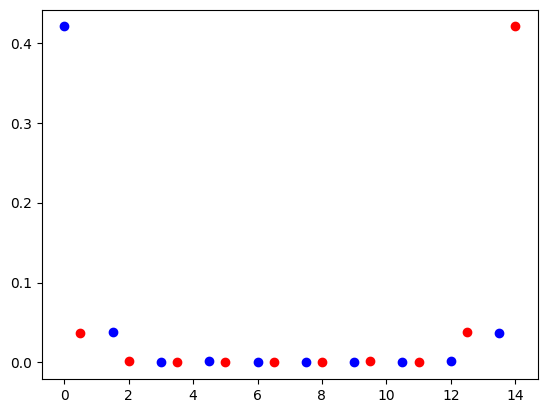

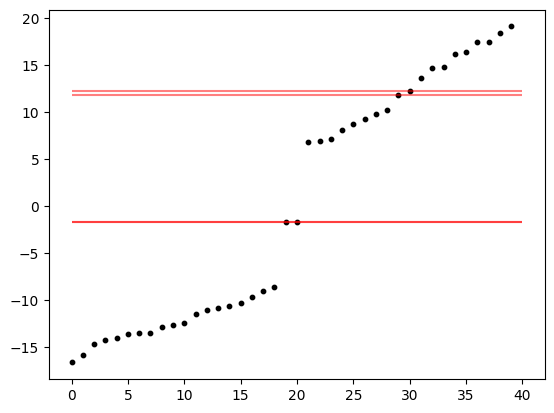

eigenvalue:  [ 0.91235988+0.j -1.72461937+0.j]


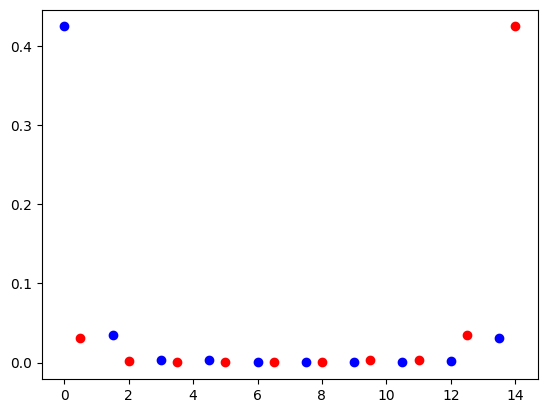

eigenvalue:  [ 0.91235988+0.j -1.72461937+0.j]


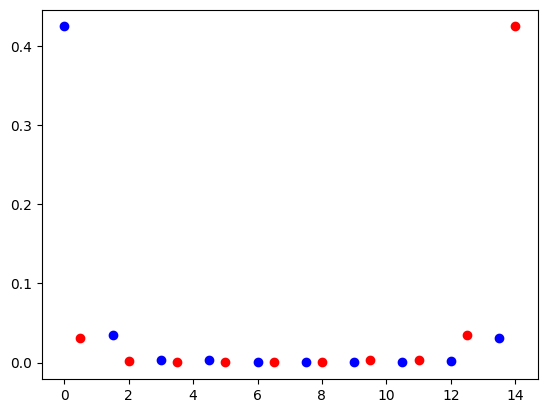

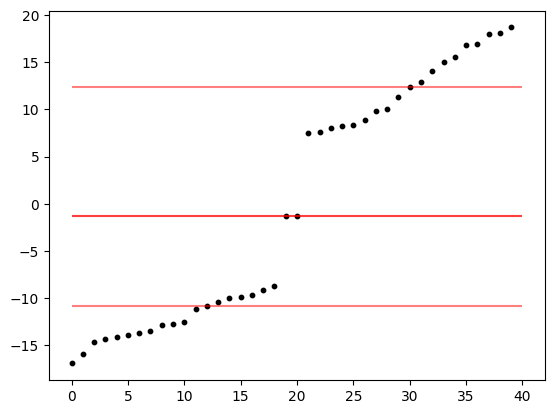

eigenvalue:  [ 0.90169347+0.j -1.34117452+0.j]


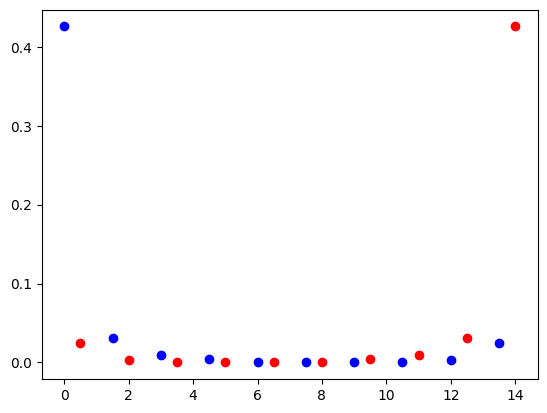

eigenvalue:  [ 0.90169347+0.j -1.34117452+0.j]


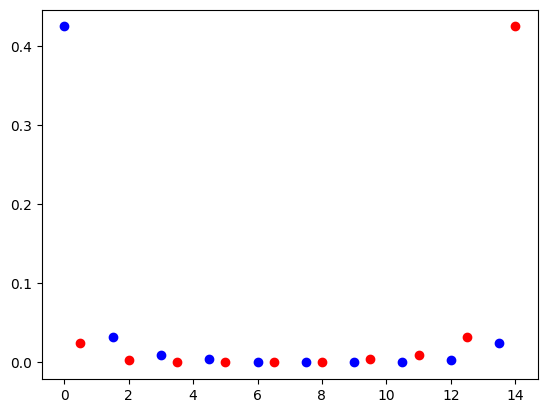

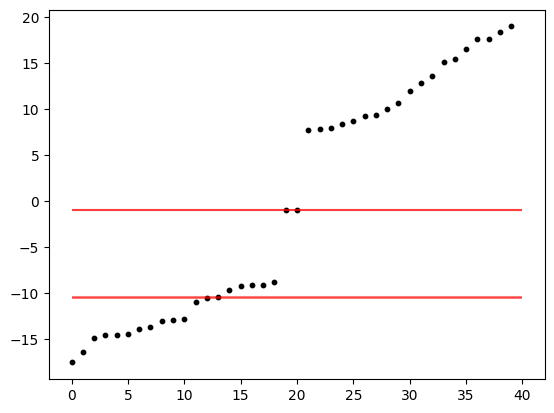

eigenvalue:  [ 0.87489455+0.j -0.98150842+0.j]


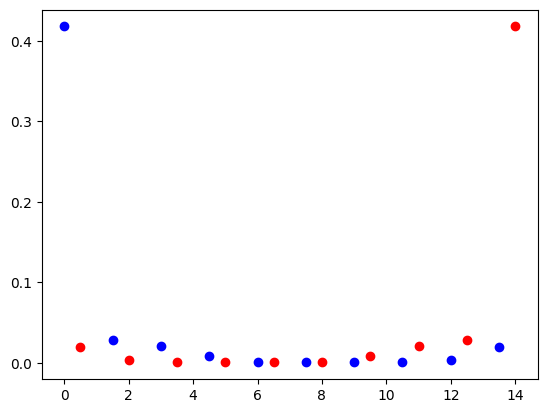

eigenvalue:  [ 0.87489455+0.j -0.98150842+0.j]


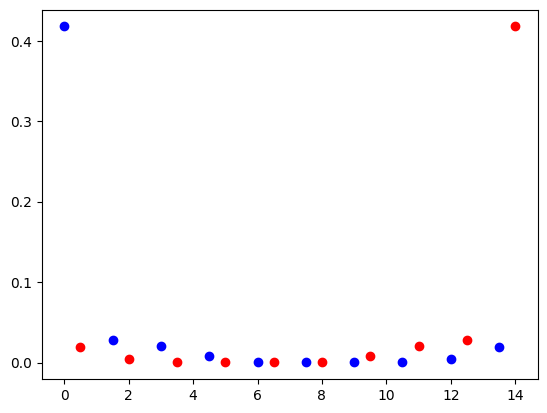

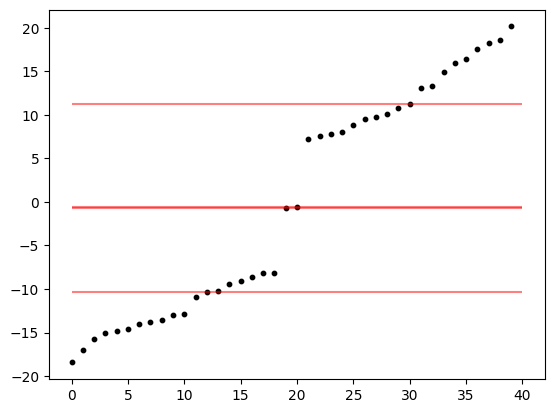

eigenvalue:  [ 0.81811681+0.j -0.54022618+0.j]


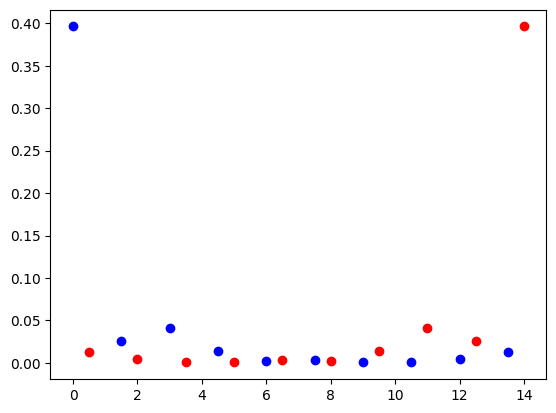

eigenvalue:  [ 0.81811681+0.j -0.54022618+0.j]


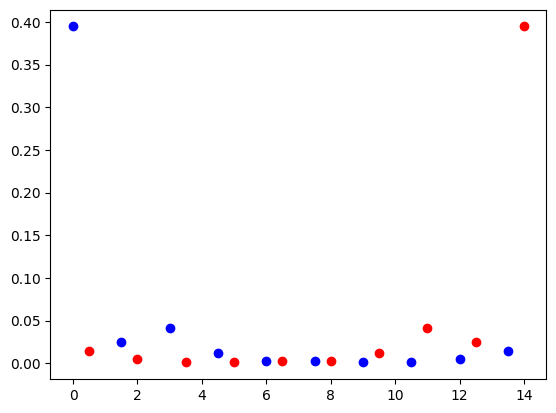

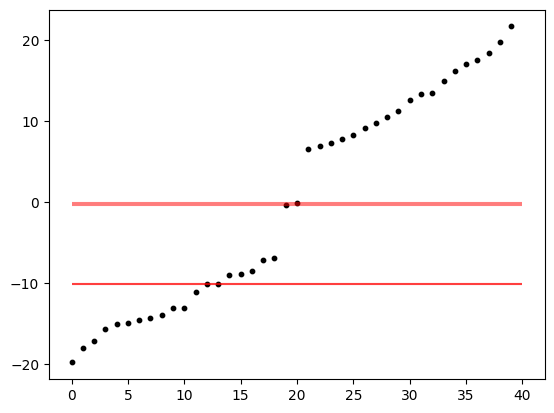

eigenvalue:  [ 0.71102357+0.j -0.13244951+0.j]


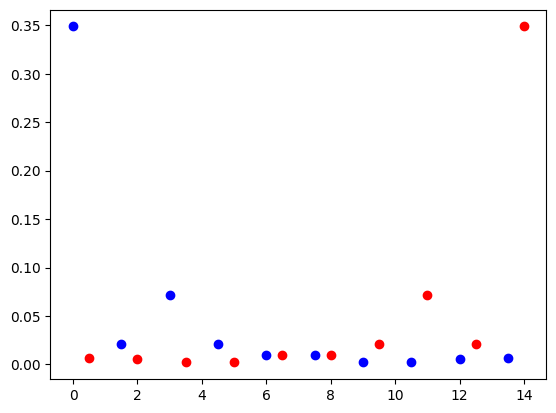

eigenvalue:  [ 0.71102357+0.j -0.13244951+0.j]


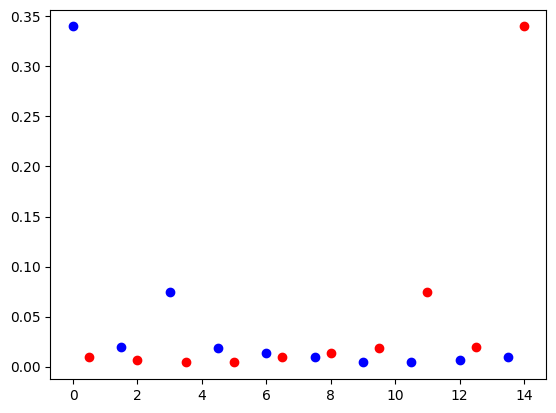

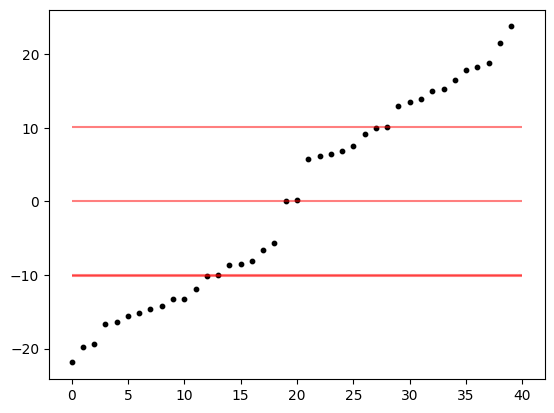

eigenvalue:  [ 0.64518675+0.j -9.9556945 +0.j]


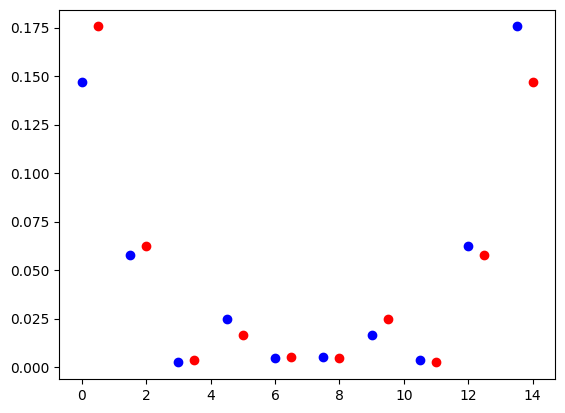

eigenvalue:  [ 0.64518675+0.j -9.9556945 +0.j]


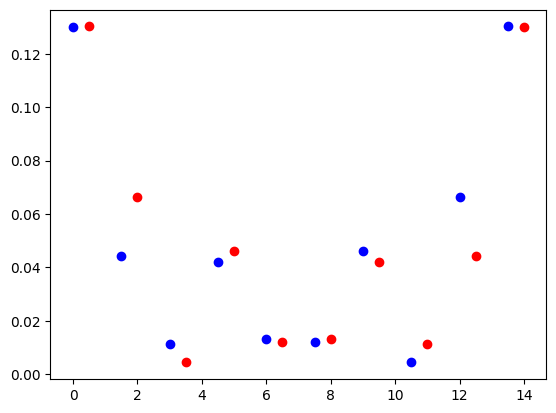

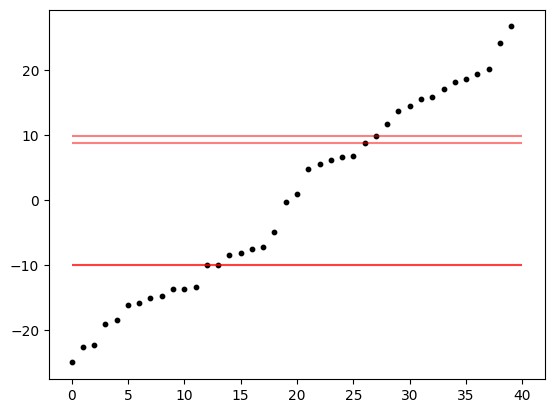

eigenvalue:  [ 0.66252702+0.j -9.92658874+0.j]


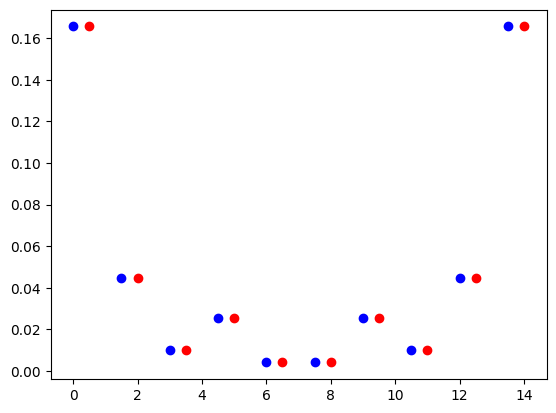

eigenvalue:  [ 0.66252702+0.j -9.92658874+0.j]


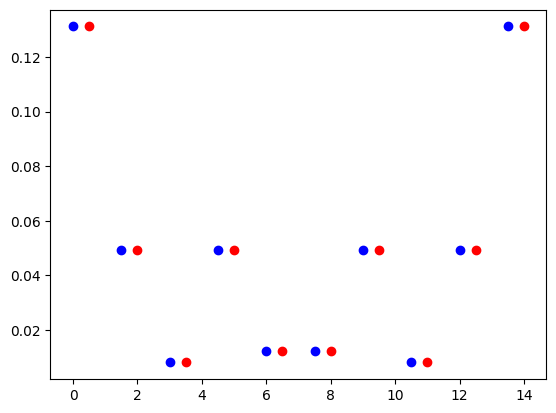

In [72]:
def find_edge_states(vec):
    return np.abs(vec[:,1])**2+np.abs(vec[:,latticeA.shape[1]])**2+np.abs(vec[:,latticeA.shape[1]+1])**2+np.abs(vec[:,(latticeA.shape[1])*2])**2\
    + np.abs(vec[:,2*latticeA.shape[1]+1])**2+np.abs(vec[:,latticeB.shape[1]+2*latticeA.shape[1]])**2+np.abs(vec[:,2*latticeA.shape[1]+latticeB.shape[1]+1])**2+np.abs(vec[:,2*latticeA.shape[1]+(latticeB.shape[1])*2])**2


for n in range(alphas.shape[0]):
    edge_indicator = find_edge_states(eigenvals[n,:,:])
    edge = sort_eigenvalues(edge_indicator, eigenvals[n,:,:].T)[::-1,:]
    fig, ax1 = plt.subplots(1,1)
    # ax.scatter(np.arange(edge.shape[0]), edge[:,0], color='black', s=10)
    ax1.scatter(np.arange(edge.shape[0]), eigenvals[n,:,0] , color='black', s=10)
    # plt.show()#edge[:,0]
    ax1.hlines(edge[:4,1], np.zeros(4), np.ones(4)*40 , color='red', alpha=0.5)
    plt.show()
    for ind in range(2):
        fig, ax = plt.subplots(1,1)
        vecA = np.abs(edge[ind,2:latticeA.shape[1]+2])**2 + np.abs(edge[ind,latticeA.shape[1]+2:2*latticeA.shape[1]+2])**2
        vecB = np.abs(edge[ind,2*latticeA.shape[1]+2:2*latticeA.shape[1]+2+latticeB.shape[1]])**2 + np.abs(edge[ind,2*latticeA.shape[1]+2+latticeB.shape[1]:2*latticeA.shape[1]+2+latticeB.shape[1]*2:])**2

        print('eigenvalue: ', edge[0,:2])
        # print('eig: ', vecA[n,:])
        ax.scatter(latticeA[0,:],vecA, color='blue')
        ax.scatter(latticeB[0,:],vecB, color='red')
        plt.show()


/home/christian/Documents/master/python_env/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/christian/Documents/master/python_env/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


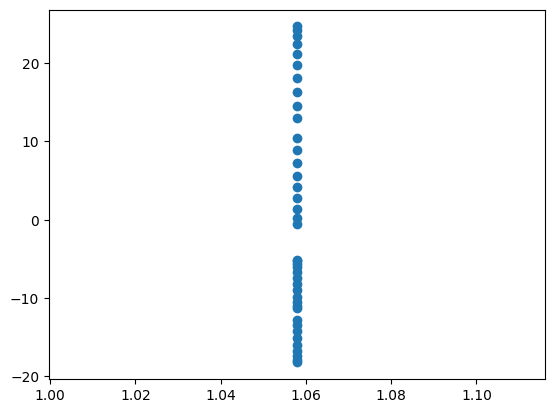

In [ ]:
def find_val(val,array):
    return int(sort_eigenvalues(np.abs(val-array),np.arange(len(array)))[0,1])

def find_separate(array):
    distance = np.abs(array[:,1:]-array[:,:-1])
    criteria = distance[:,1:]*distance[:,:-1]
    
    energies = np.ones(array.shape[0])*np.nan
    for i in range(array.shape[0]):
        ordered = sort_eigenvalues(criteria[i],np.arange(1,array.shape[1]))
        if ordered[-1,0]<1:
            energies[i] = array[i,int(ordered[-1,1])]
    return energies
            
    
    

index = find_val(np.pi/3,angles)
fig, ax = plt.subplots(1,1)
ax.scatter(angles[index]*np.ones(eigenvals.shape[1]),eigenvals[index,:,0])
plt.show()


eigenvalue:  (-8.9137738716028e-05+0j)


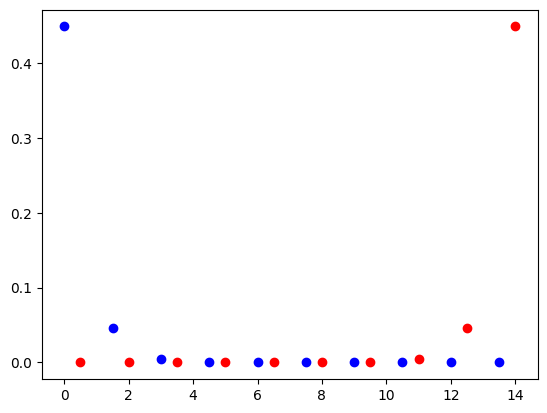

eigenvalue:  (8.913773871203516e-05+0j)


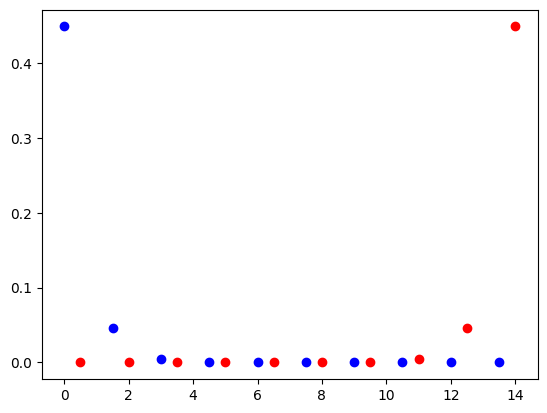

eigenvalue:  (-0.20783138352899738+0j)


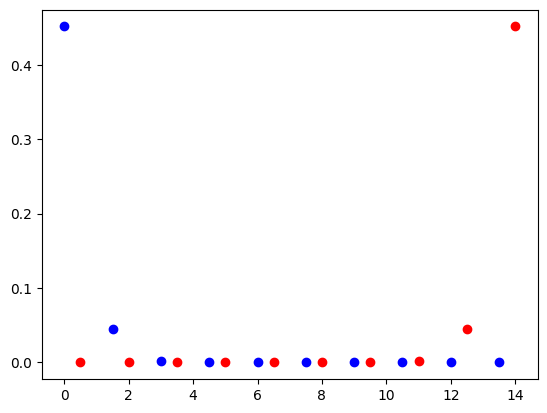

eigenvalue:  (-0.20782946451677448+0j)


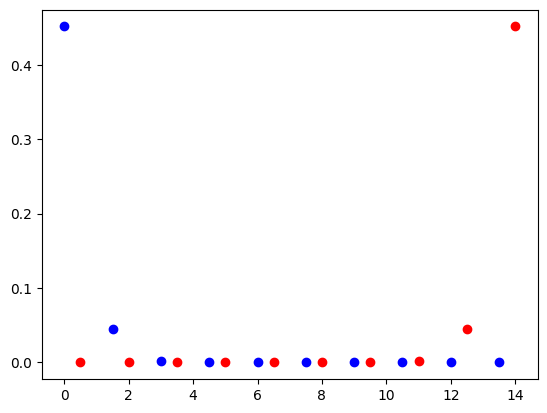

eigenvalue:  (-0.21135336550199277+0j)


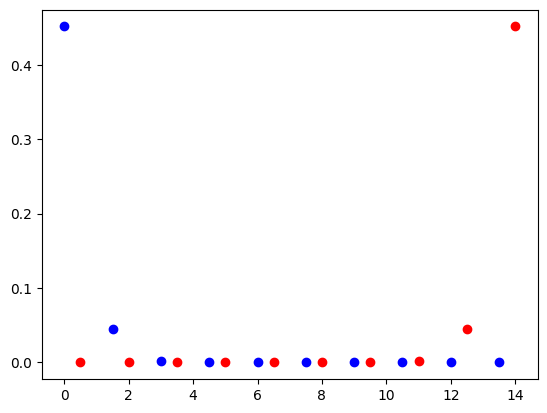

eigenvalue:  (-0.21135115225236978+0j)


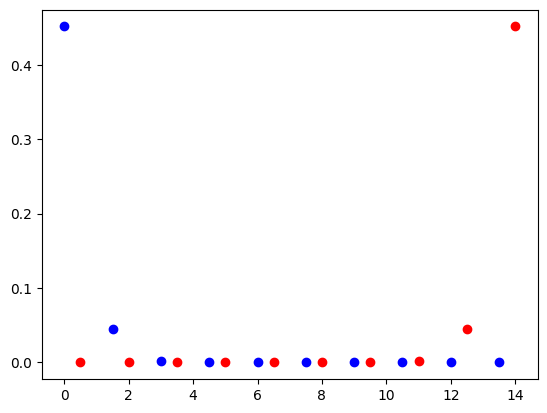

eigenvalue:  (-0.21126766533690444+0j)


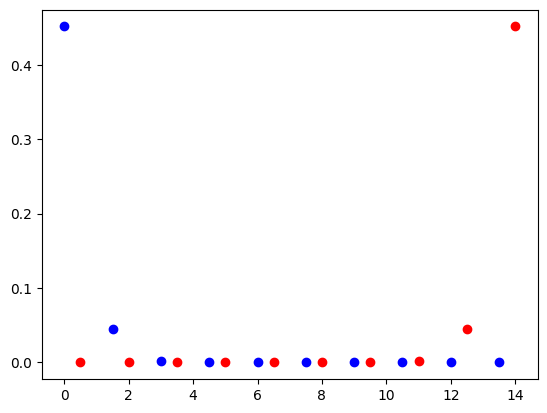

eigenvalue:  (-0.2112640171205971+0j)


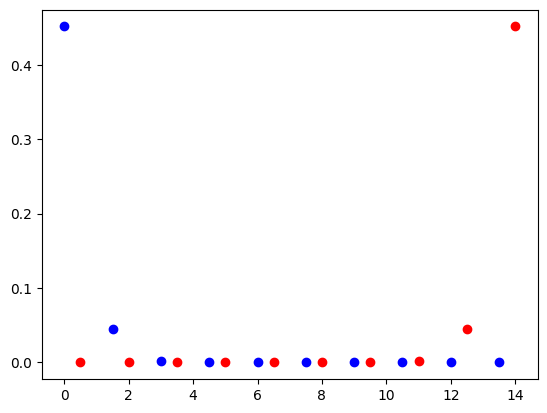

eigenvalue:  (-0.211369134869333+0j)


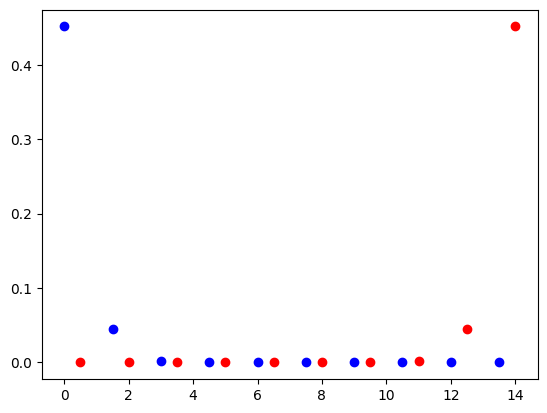

eigenvalue:  (-0.21136354684682931+0j)


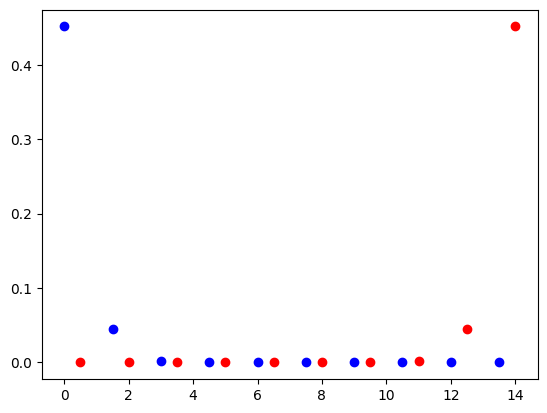

eigenvalue:  (-0.21137142613892546+0j)


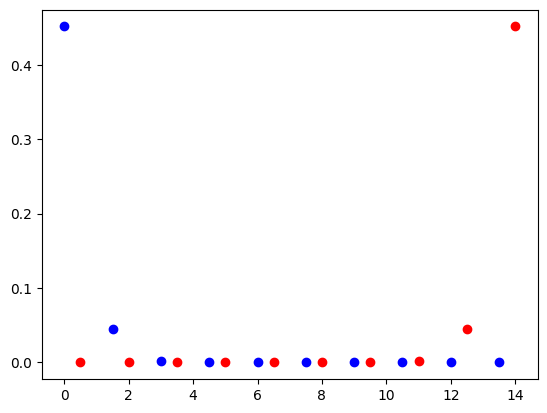

eigenvalue:  (-0.21136606786430046+0j)


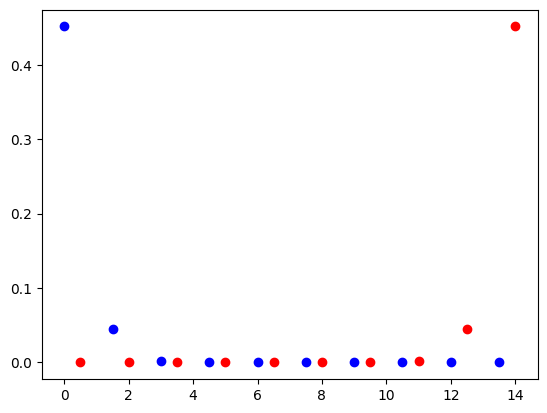

eigenvalue:  (-0.21137213980426287+0j)


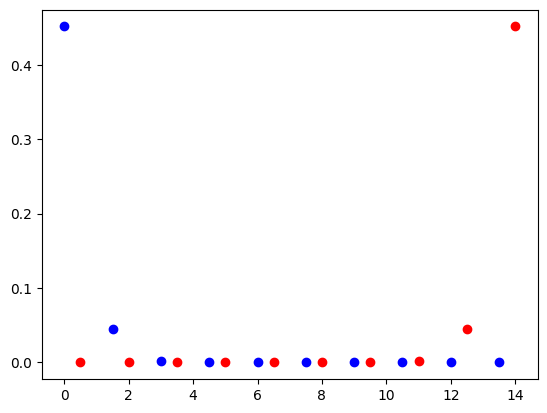

eigenvalue:  (-0.21136441421947616+0j)


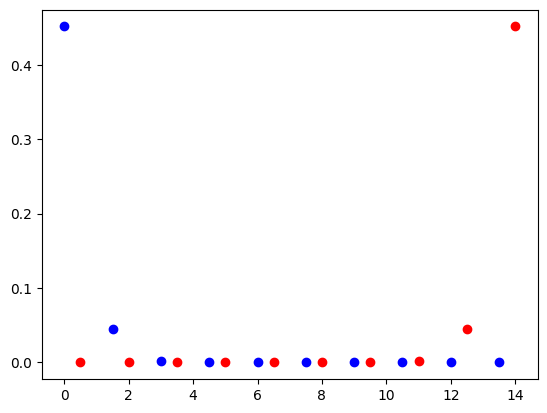

eigenvalue:  (-0.21137554991634636+0j)


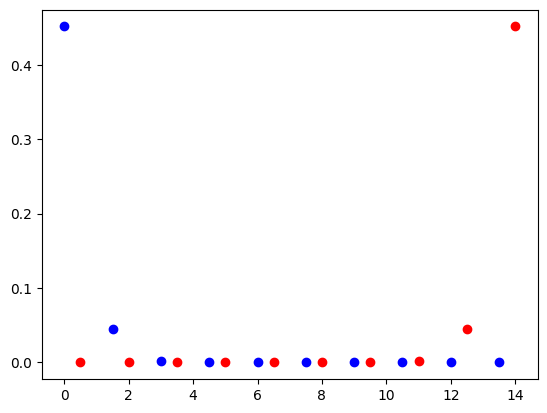

eigenvalue:  (-0.21136097741754842+0j)


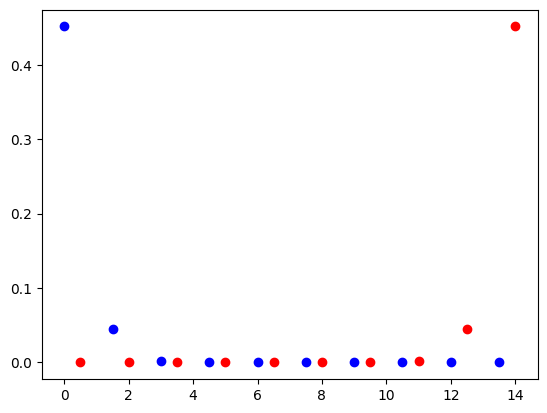

eigenvalue:  (-0.21137508224284277+0j)


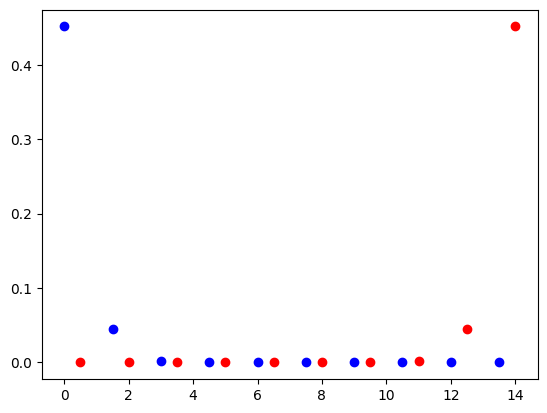

eigenvalue:  (-0.21136138946778243+0j)


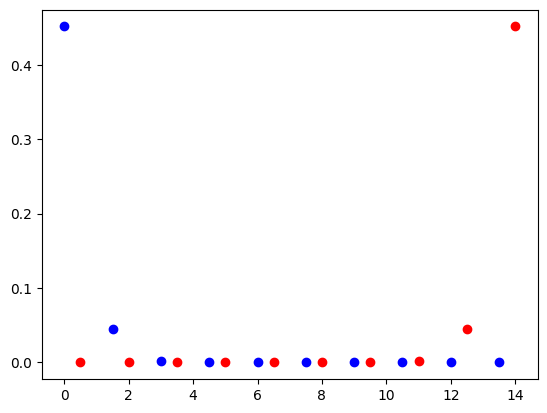

In [65]:
for j in range(9):
    
    for i in range(19,21):
        fig, ax = plt.subplots(1,1)
        vecA = np.abs(eigenvals[j,i,1:latticeA.shape[1]+1])**2 + np.abs(eigenvals[j,i,latticeA.shape[1]+1:2*latticeA.shape[1]+1])**2
        vecB = np.abs(eigenvals[j,i,2*latticeA.shape[1]+1:2*latticeA.shape[1]+1+latticeB.shape[1]])**2 + np.abs(eigenvals[j,i,2*latticeA.shape[1]+1+latticeB.shape[1]:2*latticeA.shape[1]+1+latticeB.shape[1]*2])**2
        print('eigenvalue: ', eigenvals[j,i,0])
        # print('A',vecA)
        # print('B',vecB)
        ax.scatter(latticeA[0,:],vecA, color='blue')
        ax.scatter(latticeB[0,:],vecB, color='red')
        plt.show()



# for n in range(alphas.shape[0]):
#     edge_indicator = find_edge_states(eigenvals[n,:,:])
#     edge = sort_eigenvalues(edge_indicator, eigenvals[n,:,:])[::-1]
#     fig, ax = plt.subplots(1,1)
#     ax.scatter(np.arange(edge.shape[0]), edge[:,0], color='black', s=10)
#     plt.show()
#     for ind in range(2):
#         fig, ax = plt.subplots(1,1)
#         vecA = np.abs(edge[ind,2:latticeA.shape[1]+2])**2 + np.abs(edge[ind,latticeA.shape[1]+2:2*latticeA.shape[1]+2])**2
#         vecB = np.abs(edge[ind,2*latticeA.shape[1]+2:2*latticeA.shape[1]+2+latticeB.shape[1]])**2 + np.abs(edge[ind,2*latticeA.shape[1]+2+latticeB.shape[1]:2*latticeA.shape[1]+2+latticeB.shape[1]*2:])**2

#         print('eigenvalue: ', edge[0,:2])
#         # print('eig: ', vecA[n,:])
#         ax.scatter(latticeA[0,:],vecA, color='blue')
#         ax.scatter(latticeB[0,:],vecB, color='red')
#         plt.show()

In [ ]:
open_D_mat(0.2,0.5,4,bare_interaction,no_onsite_interaction,100)

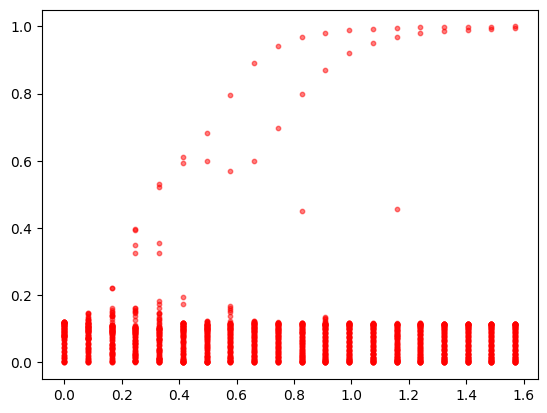

In [54]:
fig, ax = plt.subplots(1,1)
for i in range(len(alphas)):
    edge_indicator = find_edge_states(eigenvals[i,:,:])
    ax.scatter(alphas[i]*np.ones(edge_indicator.shape[0]), edge_indicator, color='red', s=10, alpha=0.5)
plt.show()

/home/christian/Documents/master/python_env/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/christian/Documents/master/python_env/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


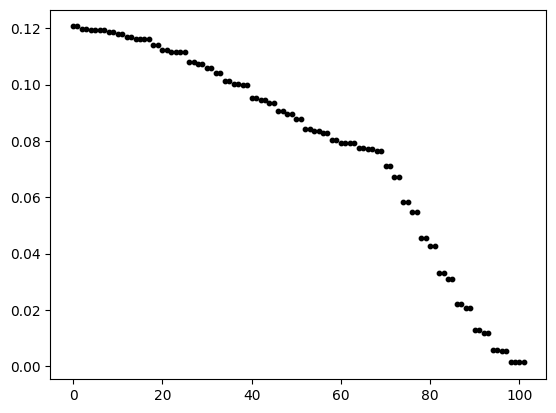

eigenvalue:  [1.20646238e-01+0.j 3.63451543e+05+0.j]


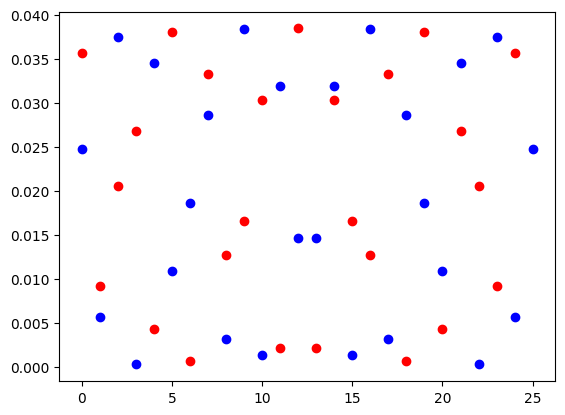

eigenvalue:  [1.20646238e-01+0.j 3.63451543e+05+0.j]


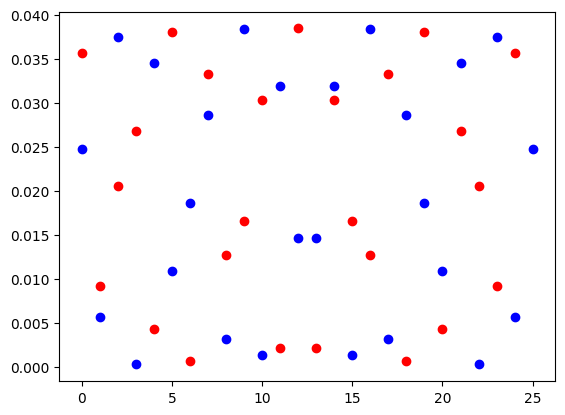

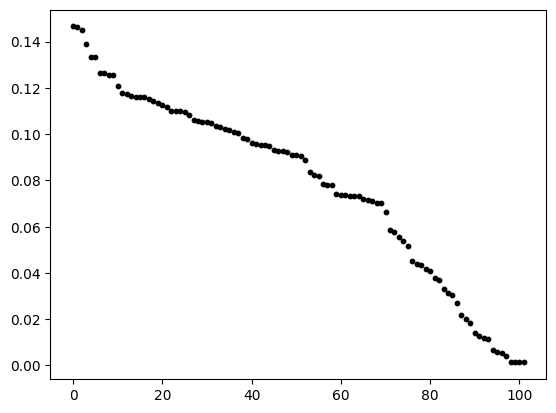

eigenvalue:  [ 1.46535771e-01+0.j -2.59527706e+05+0.j]


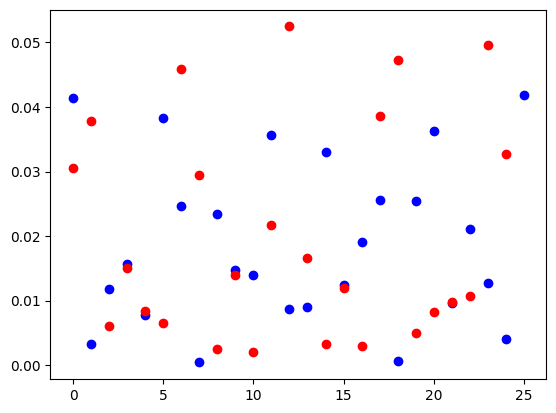

eigenvalue:  [ 1.46535771e-01+0.j -2.59527706e+05+0.j]


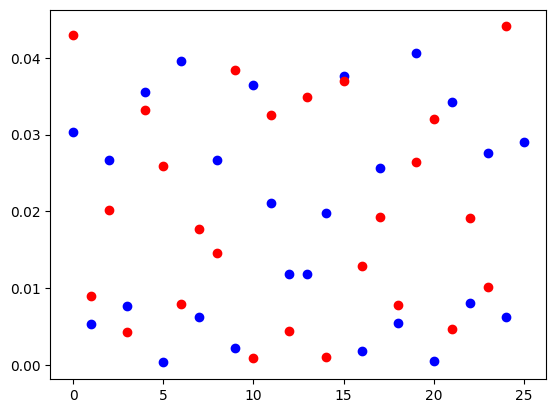

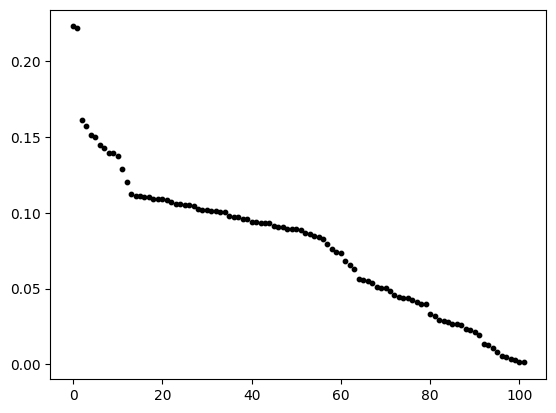

eigenvalue:  [ 2.22792540e-01+0.j -5.01677755e+03+0.j]


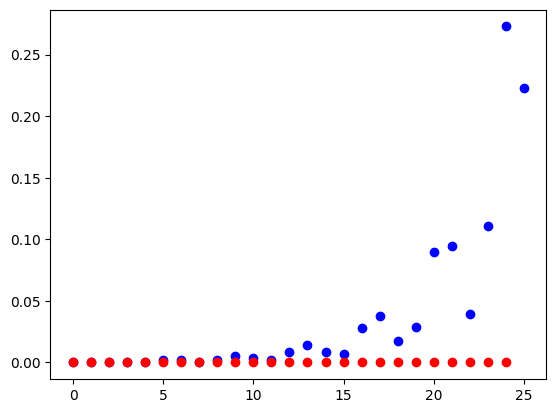

eigenvalue:  [ 2.22792540e-01+0.j -5.01677755e+03+0.j]


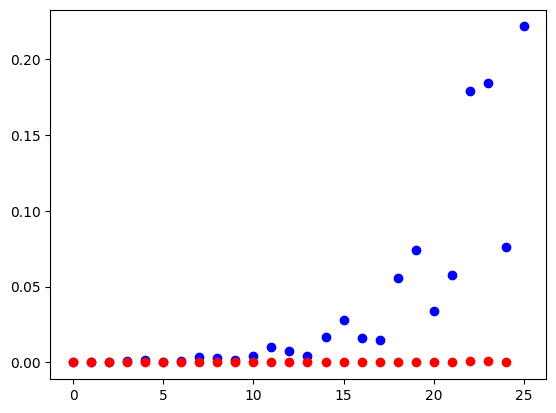

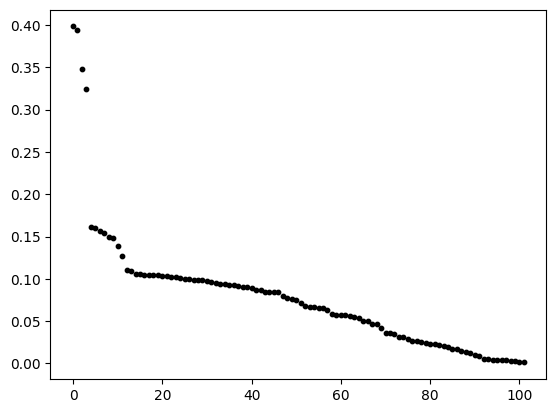

eigenvalue:  [3.98295168e-01+0.j 5.64055533e+03+0.j]


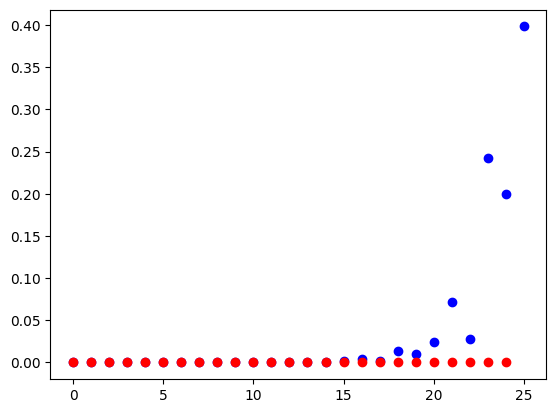

eigenvalue:  [3.98295168e-01+0.j 5.64055533e+03+0.j]


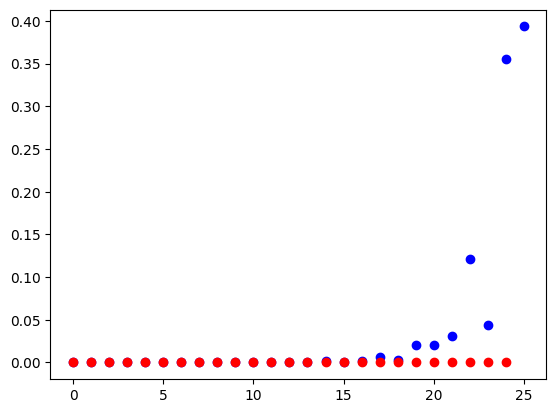

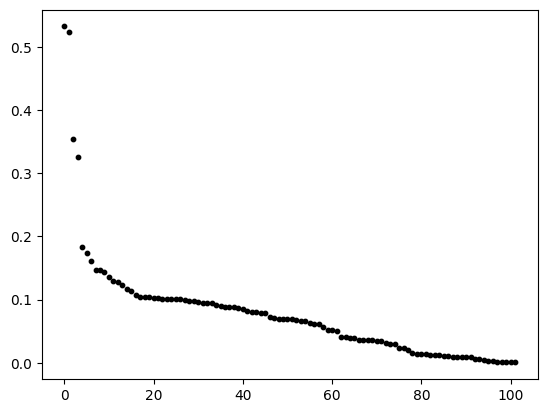

eigenvalue:  [5.32327007e-01+0.j 7.71838313e+03+0.j]


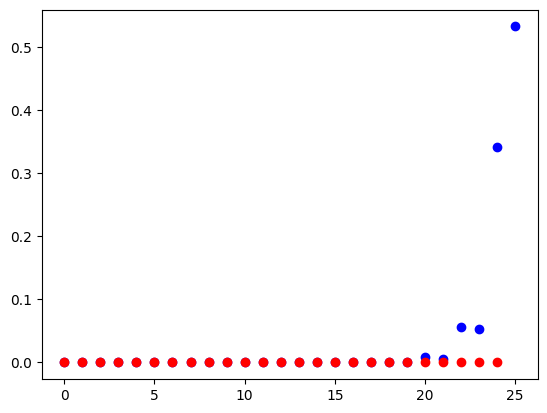

eigenvalue:  [5.32327007e-01+0.j 7.71838313e+03+0.j]


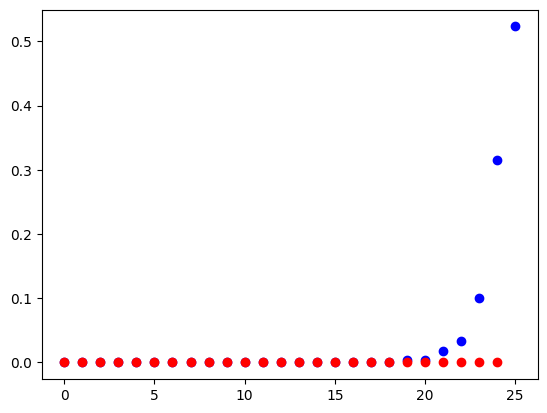

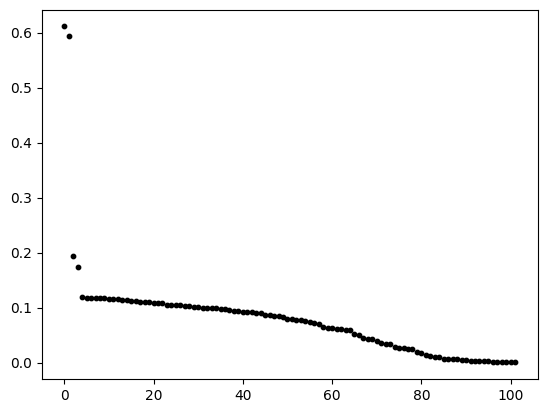

eigenvalue:  [6.11074192e-01+0.j 9.12782667e+03+0.j]


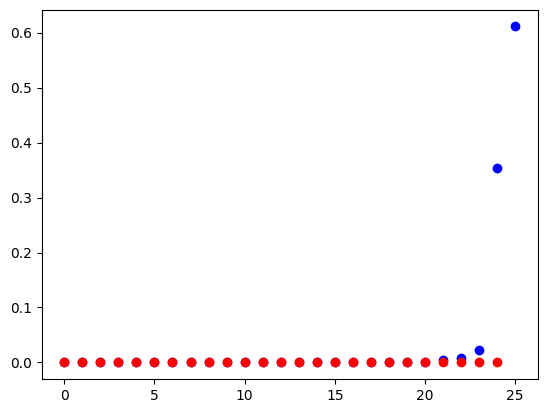

eigenvalue:  [6.11074192e-01+0.j 9.12782667e+03+0.j]


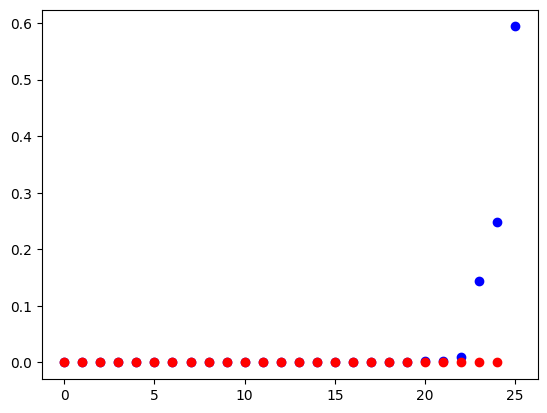

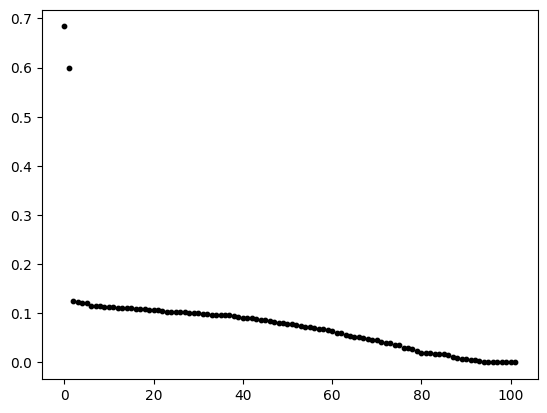

eigenvalue:  [6.83721593e-01+0.j 8.59129815e+03+0.j]


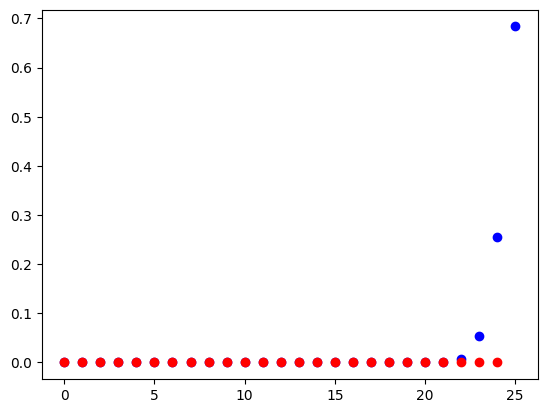

eigenvalue:  [6.83721593e-01+0.j 8.59129815e+03+0.j]


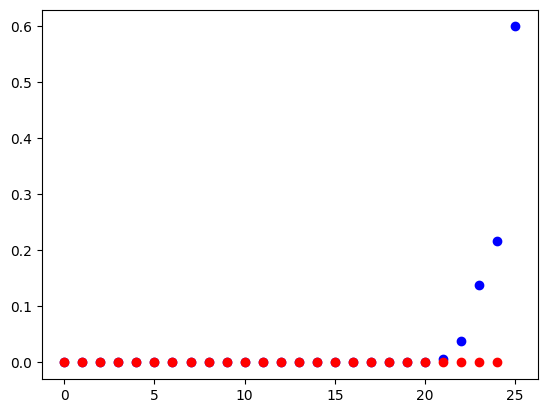

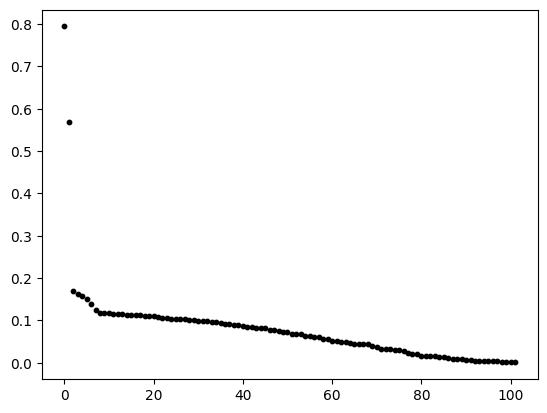

eigenvalue:  [7.94387382e-01+0.j 6.51013010e+03+0.j]


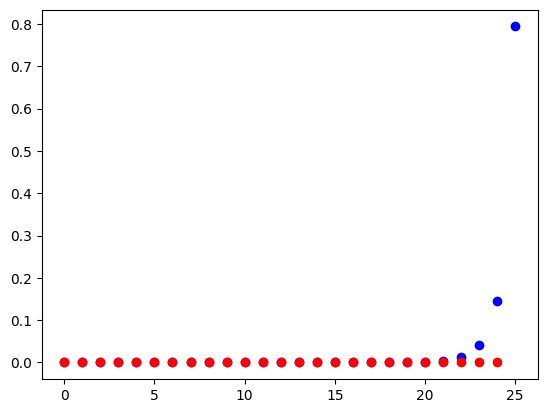

eigenvalue:  [7.94387382e-01+0.j 6.51013010e+03+0.j]


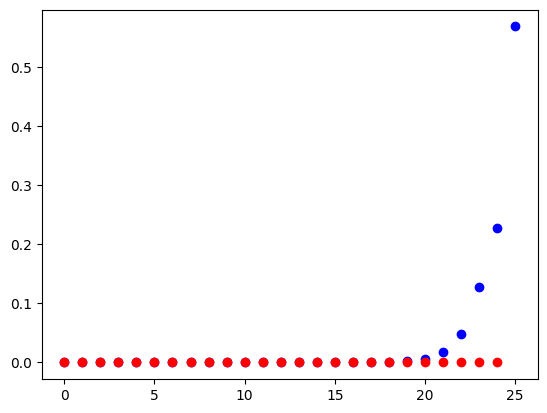

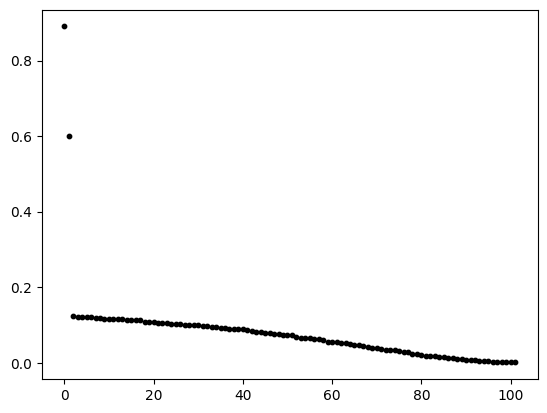

eigenvalue:  [8.90430231e-01+0.j 4.72208168e+03+0.j]


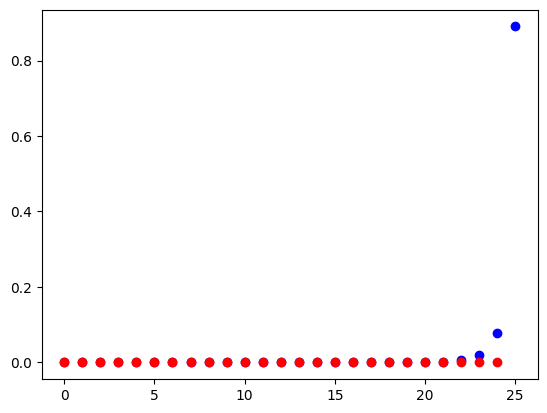

eigenvalue:  [8.90430231e-01+0.j 4.72208168e+03+0.j]


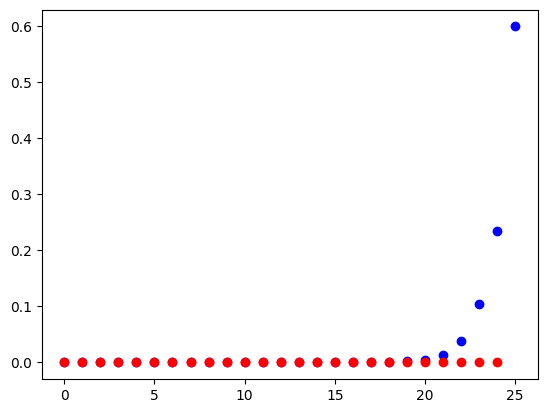

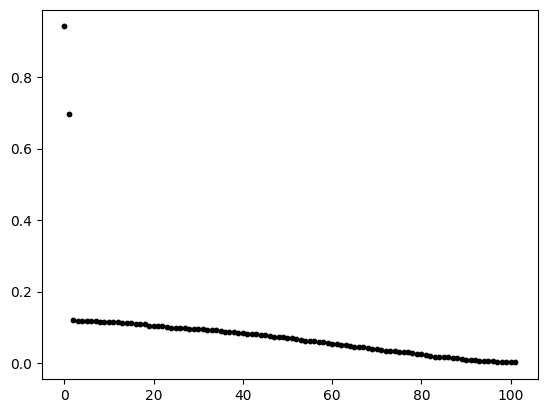

eigenvalue:  [9.41901333e-01+0.j 3.69166541e+03+0.j]


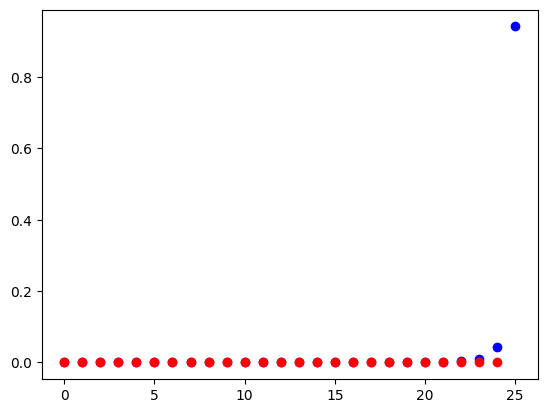

eigenvalue:  [9.41901333e-01+0.j 3.69166541e+03+0.j]


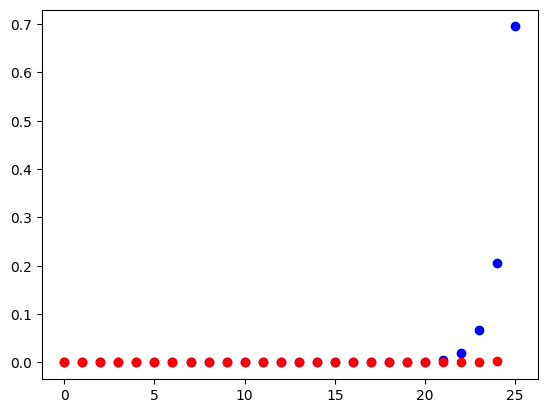

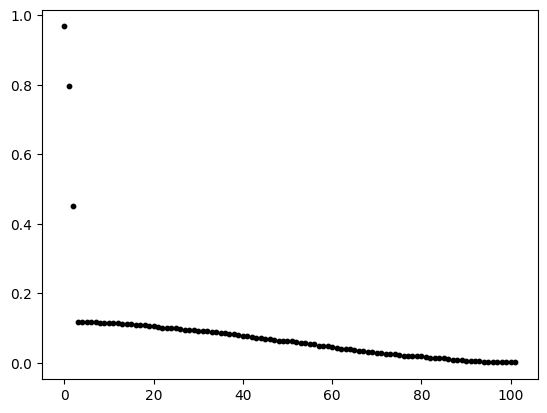

eigenvalue:  [9.67691983e-01+0.j 3.04572523e+03+0.j]


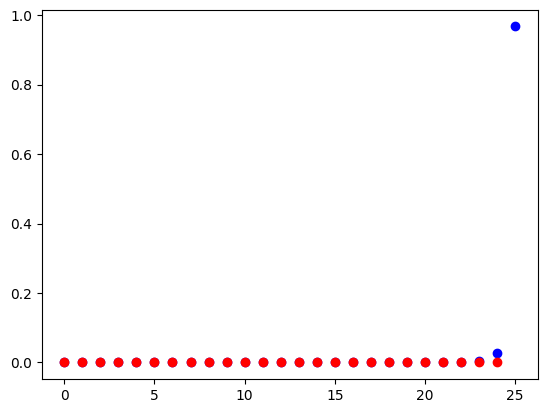

eigenvalue:  [9.67691983e-01+0.j 3.04572523e+03+0.j]


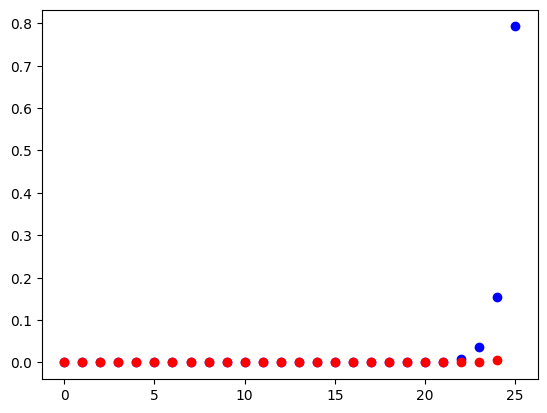

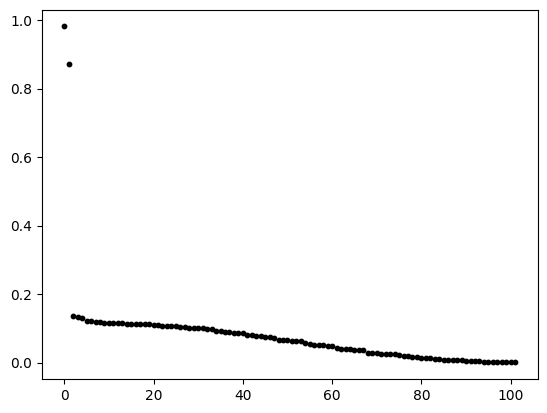

eigenvalue:  [9.81440384e-01+0.j 2.54850040e+03+0.j]


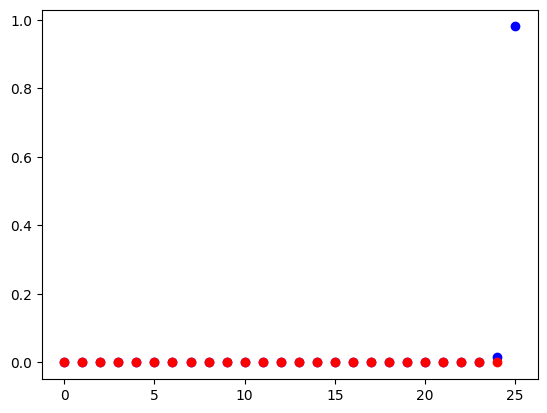

eigenvalue:  [9.81440384e-01+0.j 2.54850040e+03+0.j]


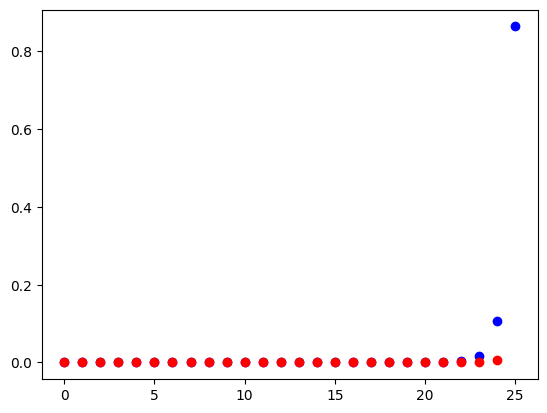

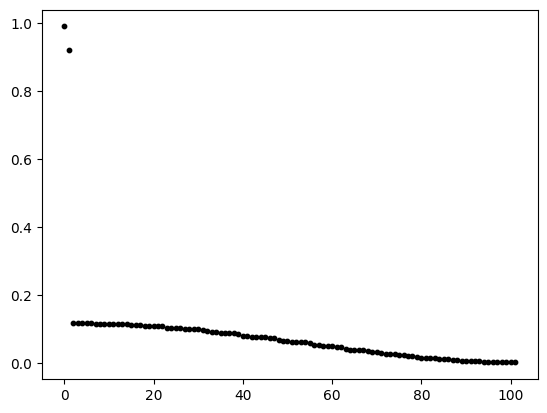

eigenvalue:  [9.89140136e-01+0.j 2.12096782e+03+0.j]


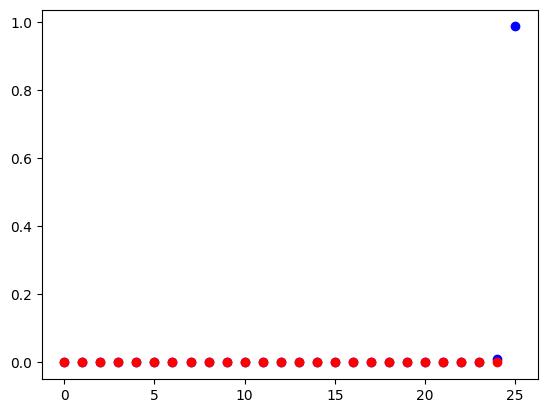

eigenvalue:  [9.89140136e-01+0.j 2.12096782e+03+0.j]


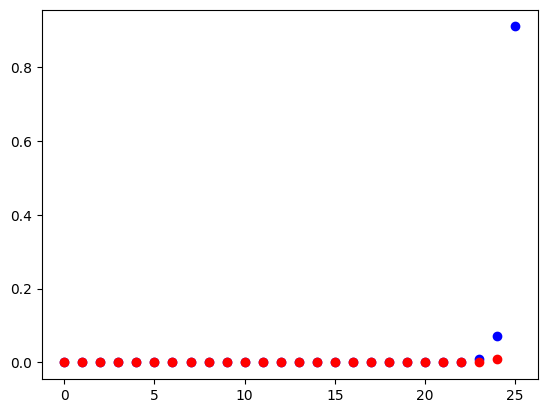

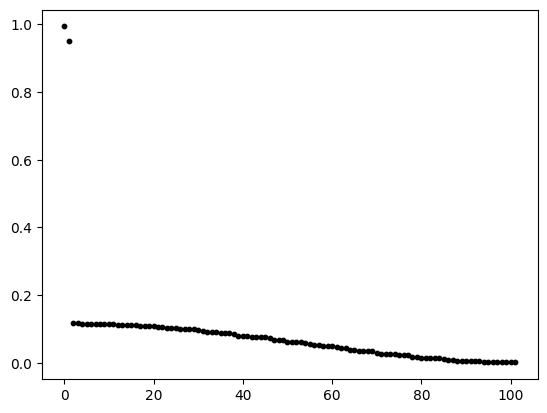

eigenvalue:  [9.93570052e-01+0.j 1.74523990e+03+0.j]


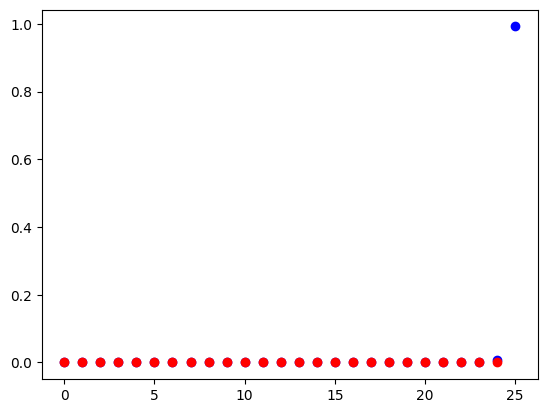

eigenvalue:  [9.93570052e-01+0.j 1.74523990e+03+0.j]


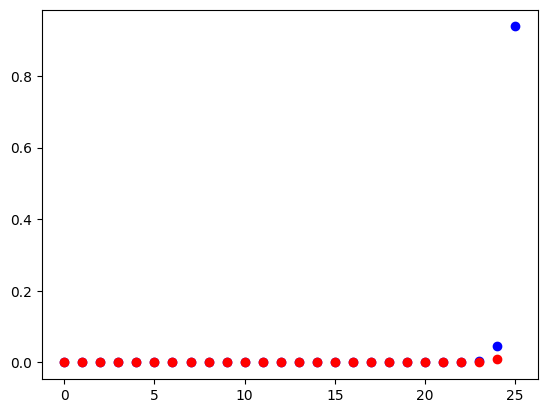

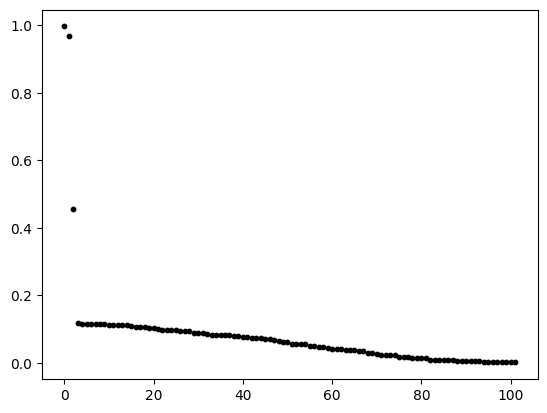

eigenvalue:  [9.96156980e-01+0.j 1.41948623e+03+0.j]


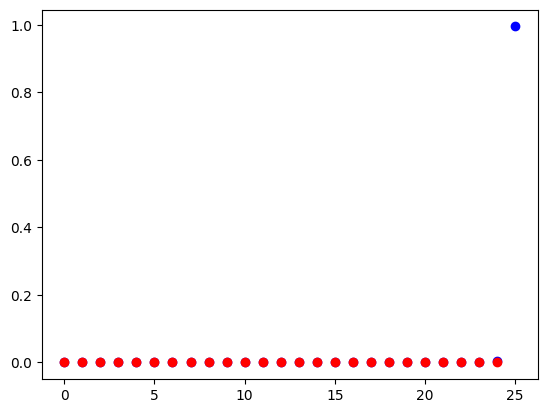

eigenvalue:  [9.96156980e-01+0.j 1.41948623e+03+0.j]


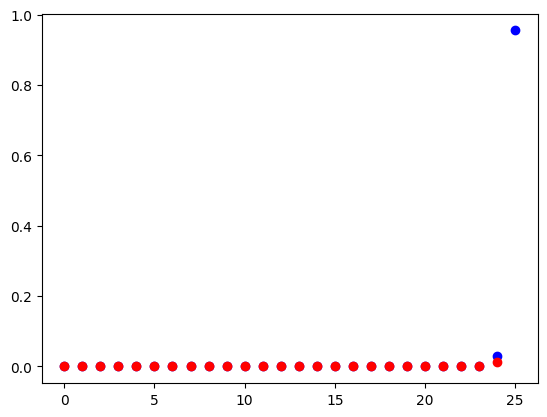

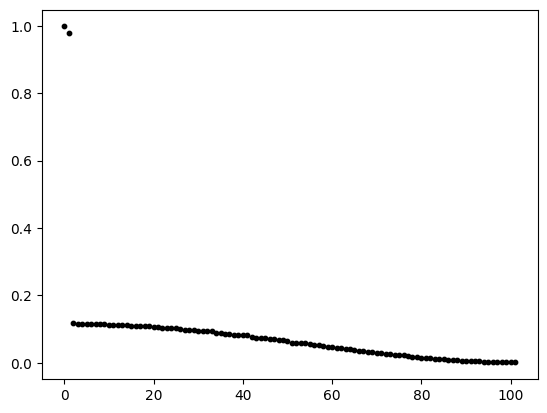

eigenvalue:  [9.97682719e-01+0.j 1.14297222e+03+0.j]


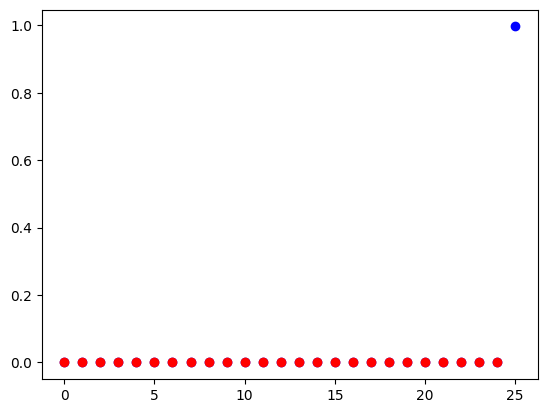

eigenvalue:  [9.97682719e-01+0.j 1.14297222e+03+0.j]


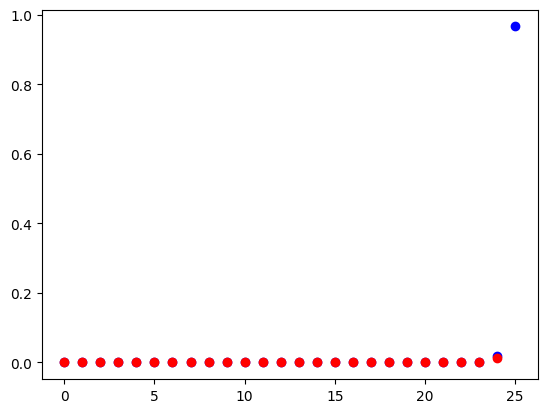

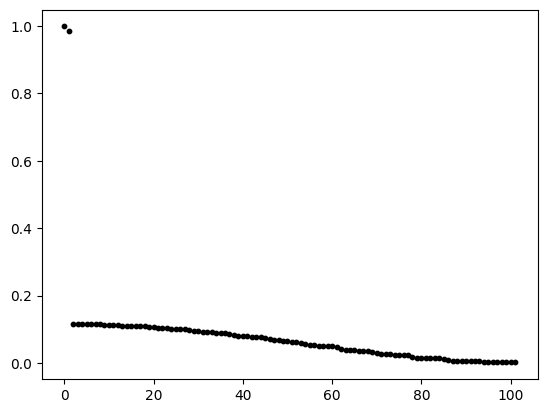

eigenvalue:  [  0.99859001+0.j 912.79630602+0.j]


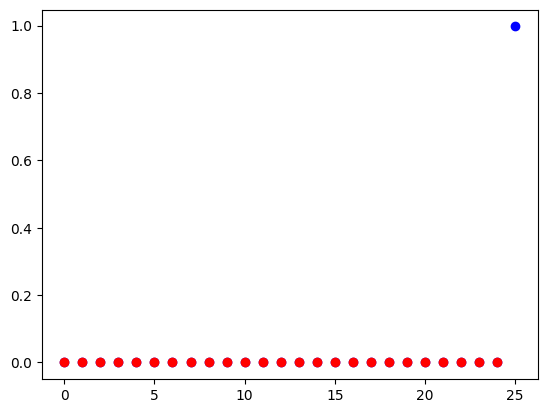

eigenvalue:  [  0.99859001+0.j 912.79630602+0.j]


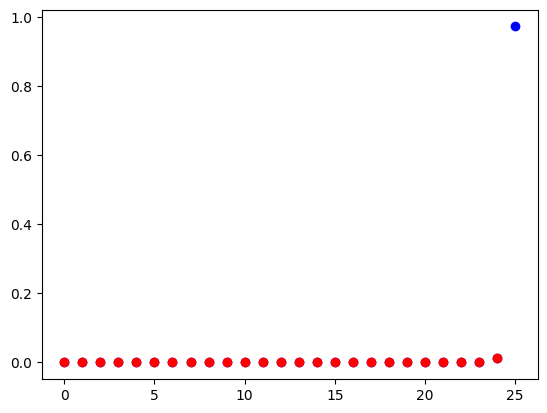

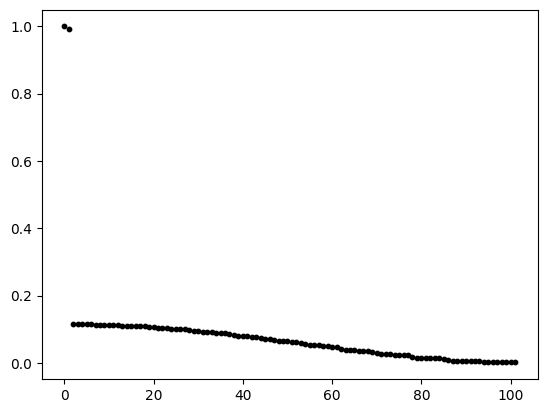

eigenvalue:  [  0.99913372+0.j 724.24181378+0.j]


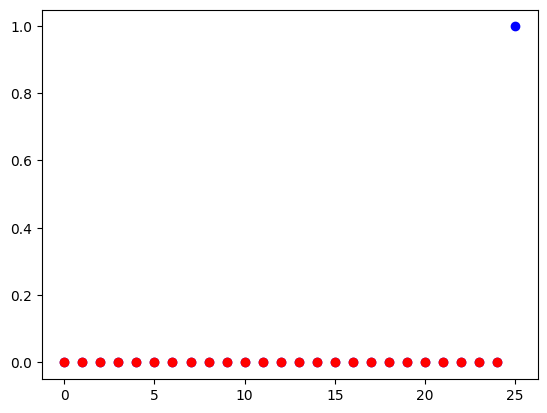

eigenvalue:  [  0.99913372+0.j 724.24181378+0.j]


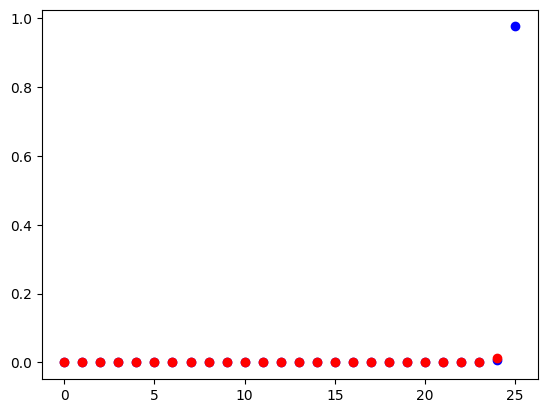

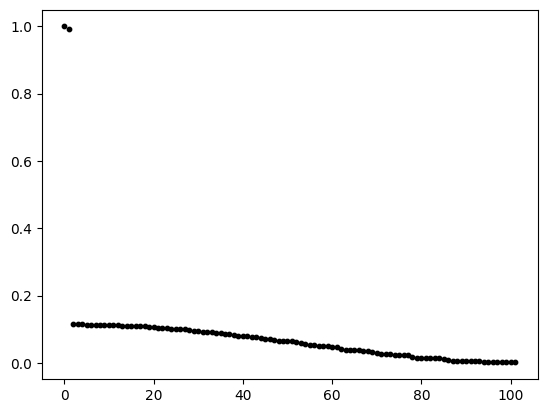

eigenvalue:  [  0.99946188+0.j 571.78570483+0.j]


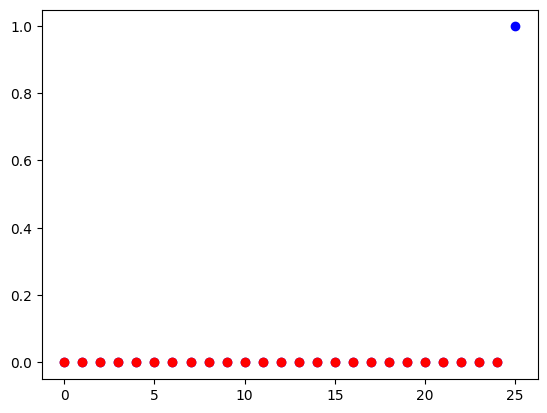

eigenvalue:  [  0.99946188+0.j 571.78570483+0.j]


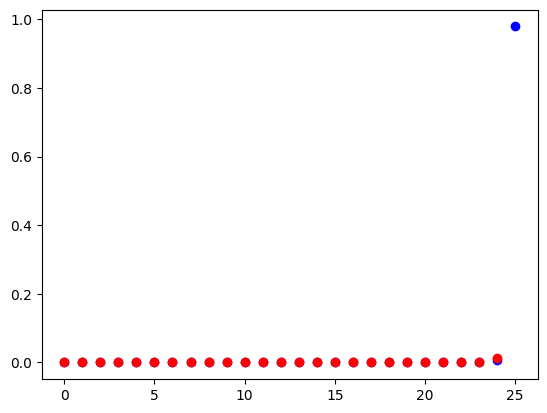

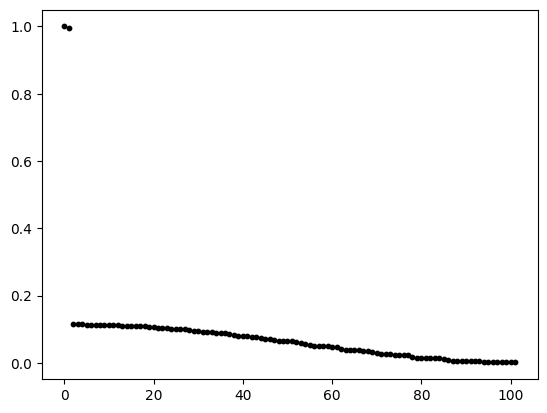

eigenvalue:  [  0.99966098+0.j 449.89632305+0.j]


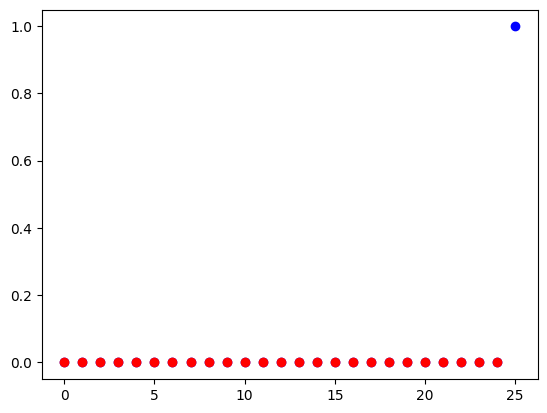

eigenvalue:  [  0.99966098+0.j 449.89632305+0.j]


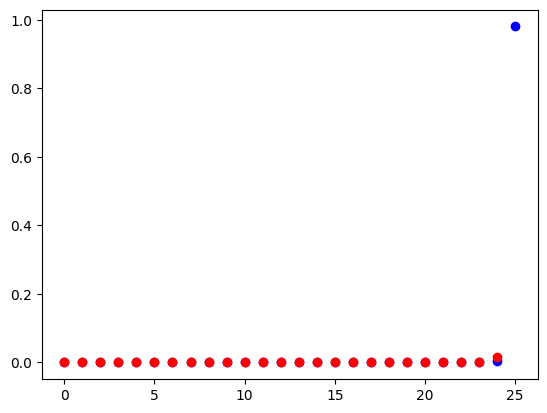

In [ ]:
# def sort_eigenvalues(eigenvalues: np.ndarray,eigenvectors: np.ndarray) -> np.ndarray:
#     """Sort eigenvalues in ascending order."""
#     # eigenvectors *= np.conjugate(eigenvectors[0, :])/np.array([np.absolute(eigenvectors[0,i]) for i in range(eigenvectors.shape[1])]) # Normalize the eigenvectors
#     comb = np.column_stack((eigenvalues.T, eigenvectors))
#     # return comb
#     sorted_comb = sorted(comb, key=lambda x: x[0])
#     return np.array(sorted_comb)
# eigenvals = sort_eigenvalues(eig, vecs)
def find_edge_states(vec):
    return np.abs(vec[:,1])**2+np.abs(vec[:,latticeA.shape[1]])**2+np.abs(vec[:,latticeA.shape[1]+1])**2+np.abs(vec[:,(latticeA.shape[1])*2])**2\
    + np.abs(vec[:,2*latticeA.shape[1]+1])**2+np.abs(vec[:,latticeB.shape[1]+2*latticeA.shape[1]])**2+np.abs(vec[:,2*latticeA.shape[1]+latticeB.shape[1]+1])**2+np.abs(vec[:,2*latticeA.shape[1]+(latticeB.shape[1])*2])**2

# vecA = np.abs(eigenvals[:,1:latticeA.shape[1]+1])**2 + np.abs(eigenvals[:,chain_length+1:chain_length+latticeA.shape[1]+1])**2
# vecB = np.abs(eigenvals[:,latticeA.shape[1]+1:chain_length+1])**2 + np.abs(eigenvals[:,chain_length+latticeA.shape[1]+1:])**2

for n in range(alphas.shape[0]):
    edge_indicator = find_edge_states(eigenvals[n,:,:])
    edge = sort_eigenvalues(edge_indicator, eigenvals[n,:,:])[::-1]
    fig, ax = plt.subplots(1,1)
    ax.scatter(np.arange(edge.shape[0]), edge[:,0], color='black', s=10)
    plt.show()
    for ind in range(2):
        fig, ax = plt.subplots(1,1)
        vecA = np.abs(edge[ind,2:latticeA.shape[1]+2])**2 + np.abs(edge[ind,latticeA.shape[1]+2:2*latticeA.shape[1]+2])**2
        vecB = np.abs(edge[ind,2*latticeA.shape[1]+2:2*latticeA.shape[1]+2+latticeB.shape[1]])**2 + np.abs(edge[ind,2*latticeA.shape[1]+2+latticeB.shape[1]:2*latticeA.shape[1]+2+latticeB.shape[1]*2:])**2

        print('eigenvalue: ', edge[0,:2])
        # print('eig: ', vecA[n,:])
        ax.scatter(latticeA[0,:],vecA, color='blue')
        ax.scatter(latticeB[0,:],vecB, color='red')
        plt.show()

In [77]:
# periodic boundary condition used

def delta_R(n:int, m:int, h:int, l:int) -> float:
    """Calculate the distance between two lattice points."""
    return np.array([3/2*(m-h), np.sqrt(3)*(n+m/2-h-l/2), 0])

def interaction_AA(i: int,j: int,k: np.ndarray, interaction: Callable[[], float], interaction_onsite: Callable[[], float],latticeA,latticeB,grid_size,interaction_cut) -> float:
    R0 = latticeA[:,latticeA.shape[1]//2]
    total_potential_eq = 0
    total_potential_mixed = 0
    total_potential_eq_mixed = 0
    
    # lattice A and B have same shape
    for n in range(latticeB.shape[1]):
        Del_R_vecB = latticeB[:,n] - R0
        if i!=j:
            total_potential_eq_mixed -= interaction(Del_R_vecB,i,j,interaction_cut)
    for n in range(latticeA.shape[1]):
        if n == latticeA.shape[1]//2:
            continue
        Del_R_vec = latticeA[:,n] - R0
        potential = interaction(Del_R_vec,i,j,interaction_cut)
        total_potential_mixed += np.exp(-1j * np.dot(Del_R_vec, k))*potential
        if i!=j:
            total_potential_eq -= potential
           
    return 0#(total_potential_eq+total_potential_mixed+ total_potential_eq_mixed+interaction_onsite(i,j))#, test

 

def interaction_AB(i,j,k, interaction,latticeA,latticeB,grid_size,interaction_cut):
    R0 = latticeA[:,latticeA.shape[1]//2]
    total_potential_mixed = 0
    for n in range(latticeB.shape[1]):
        Del_R_vec = latticeB[:,n] - R0
        
        total_potential_mixed += np.exp(-1j * np.dot(Del_R_vec, k))*interaction(Del_R_vec,i,j,interaction_cut)
    # return 0
    return total_potential_mixed


def D_mat(k: np.ndarray,frac: float, alpha: float, interaction: Callable[[],float], interaction_onsite: Callable[[],float],chain_length,*interaction_cut) -> np.ndarray:
    """Calculate the D matrix for the given k vector."""
    latticeA = np.zeros((2,chain_length//2+chain_length%2))
    latticeB = np.zeros((2,chain_length//2))
    a = 1
    
    for n in range(latticeA.shape[1]):
        latticeA[:,n] = n*np.array([1,0])
    for n in range(latticeB.shape[1]):
        latticeB[:,n] = n*np.array([1,0])+ np.array([frac*a*np.cos(alpha),frac*a*np.sin(alpha)])
    dmat = np.zeros((4,4),dtype=complex)
    if not interaction_cut:
        interaction_cut = [chain_length*10**6]
    for i in range(4):
        for j in range(4):
            if i < 2 and j < 2:
          
                dmat[i, j] = interaction_AA(i, j, k,interaction,interaction_onsite,latticeA,latticeB,chain_length,*interaction_cut)
            elif i >= 2 and j >= 2:
                dmat[i, j] = interaction_AA(i-2, j-2, k,interaction,interaction_onsite,latticeB,latticeA,chain_length,*interaction_cut)
            elif i < 2 and j >= 2:
               
                dmat[i, j] = interaction_AB(i,j-2,k,interaction,latticeA,latticeB,chain_length,*interaction_cut)
            elif i >= 2 and j < 2:
                
                dmat[i, j] = interaction_AB(i-2,j,k,interaction,latticeB,latticeA,chain_length,*interaction_cut)

    return dmat
dmat = D_mat(k1,0.5,np.pi/4,bare_interaction,no_onsite_interaction,100)
eigvals, eigvecs = np.linalg.eig(dmat)
for i in  range(eigvecs.shape[1]):
    print("eigenvcec: ",eigvecs[:,i])

eigenvcec:  [0.52362753+0.00000000e+00j 0.47519913-4.99907165e-17j
 0.31716113-4.16646866e-01j 0.28782805-3.78112715e-01j]
eigenvcec:  [ 0.52362753+0.00000000e+00j  0.47519913-7.34077860e-17j
 -0.31716113+4.16646866e-01j -0.28782805+3.78112715e-01j]
eigenvcec:  [ 0.28782805+3.78112714e-01j -0.31716113-4.16646865e-01j
 -0.47519913+1.94289029e-16j  0.52362753+0.00000000e+00j]
eigenvcec:  [-0.28782805-3.78112714e-01j  0.31716113+4.16646865e-01j
 -0.47519913+1.66533454e-16j  0.52362753+0.00000000e+00j]


/home/christian/Documents/master/python_env/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/christian/Documents/master/python_env/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


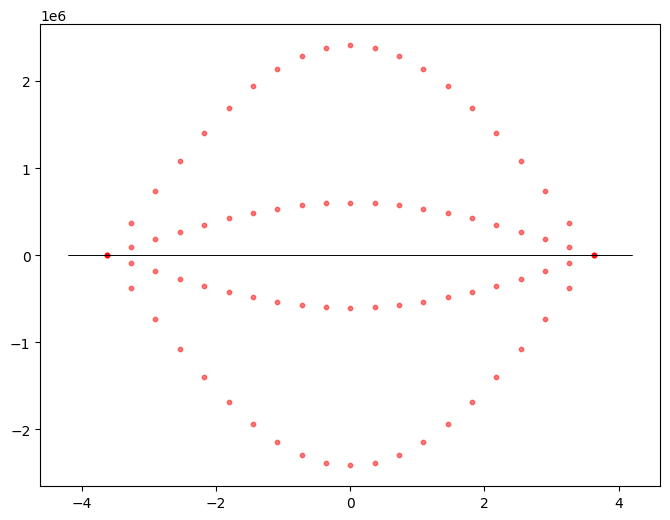

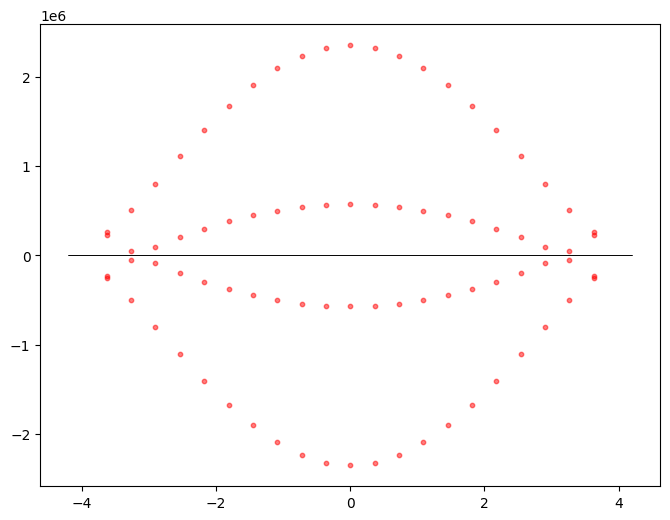

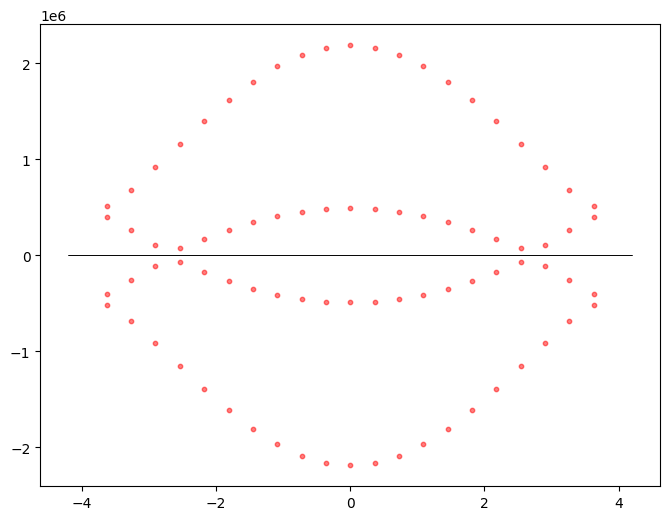

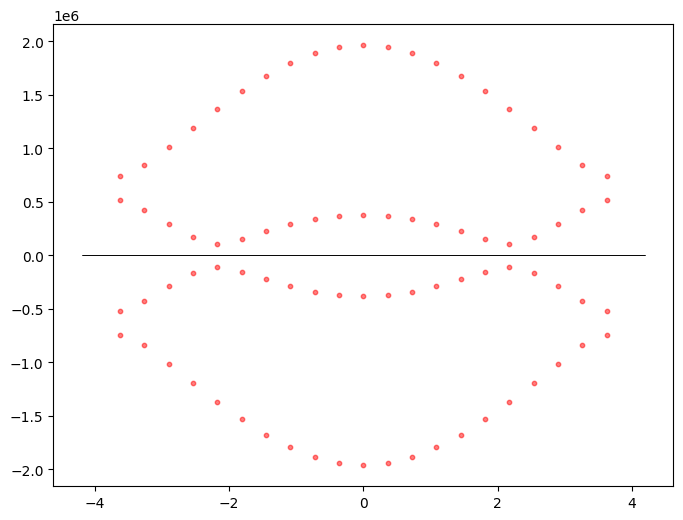

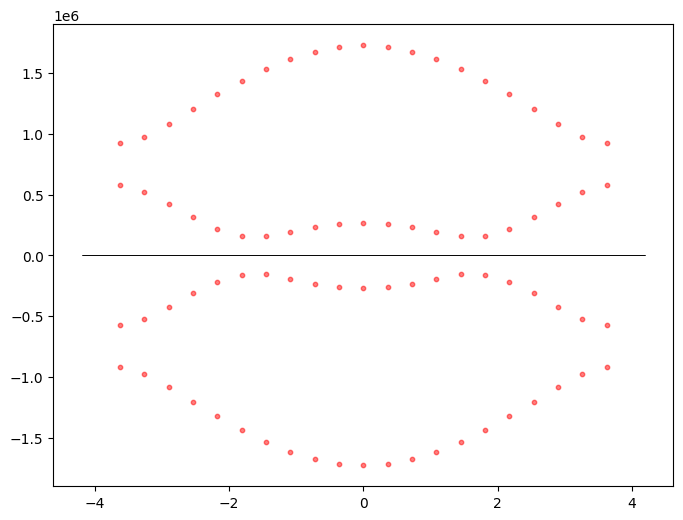

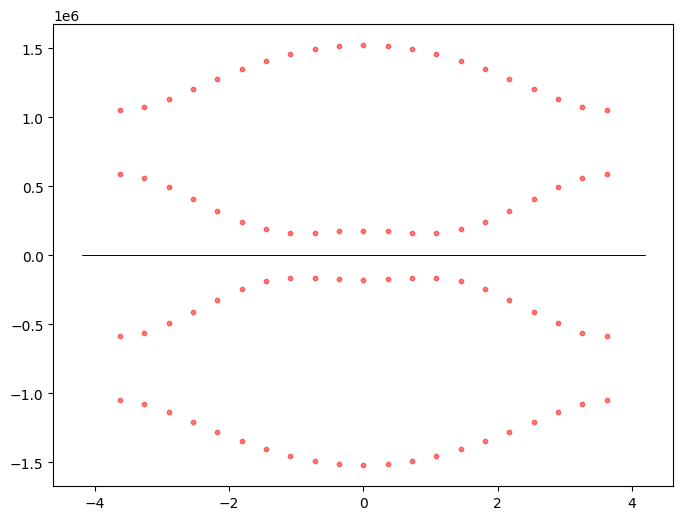

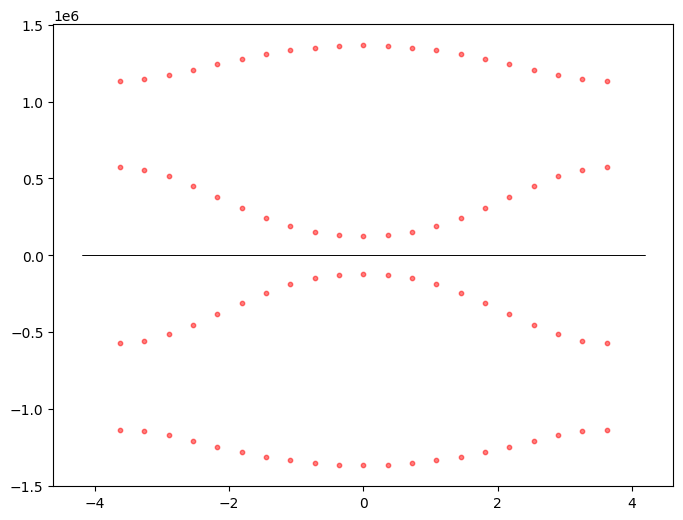

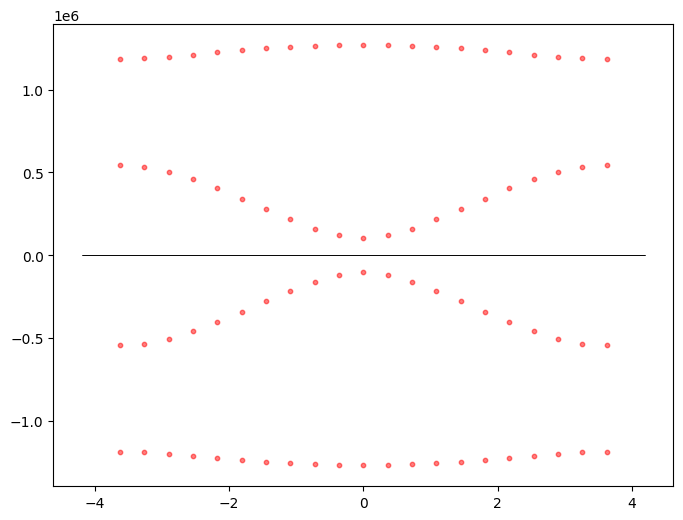

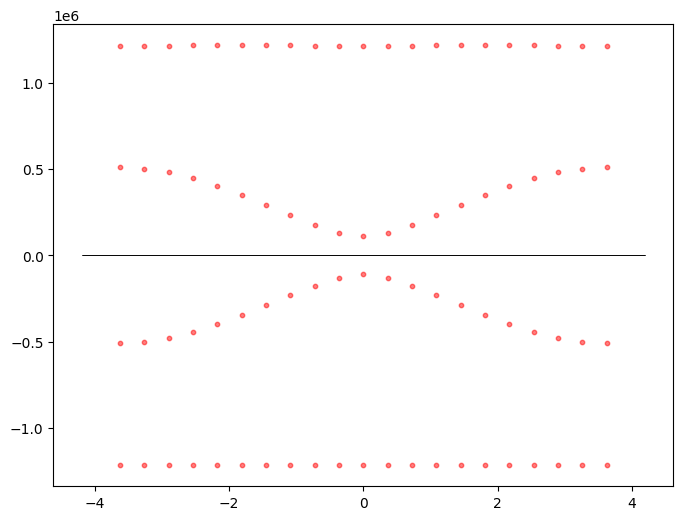

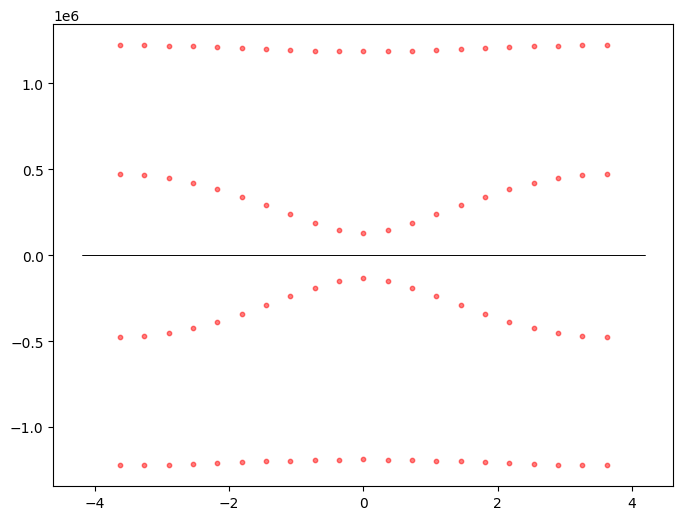

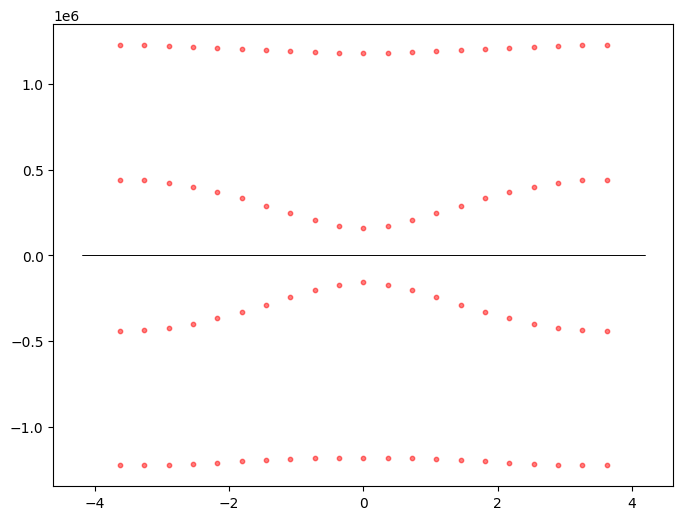

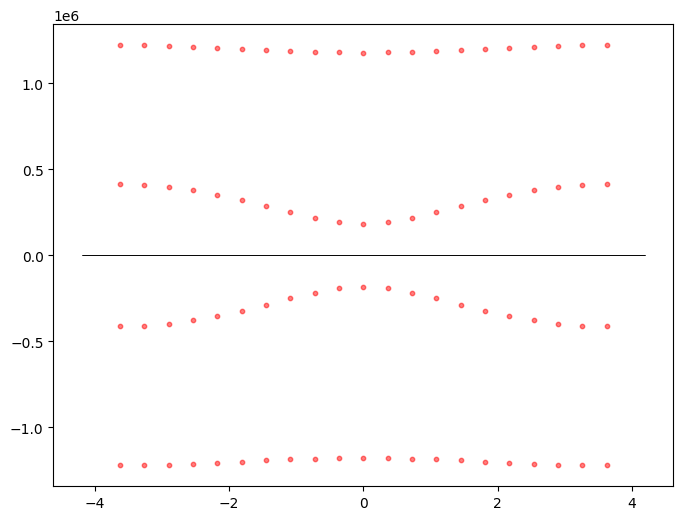

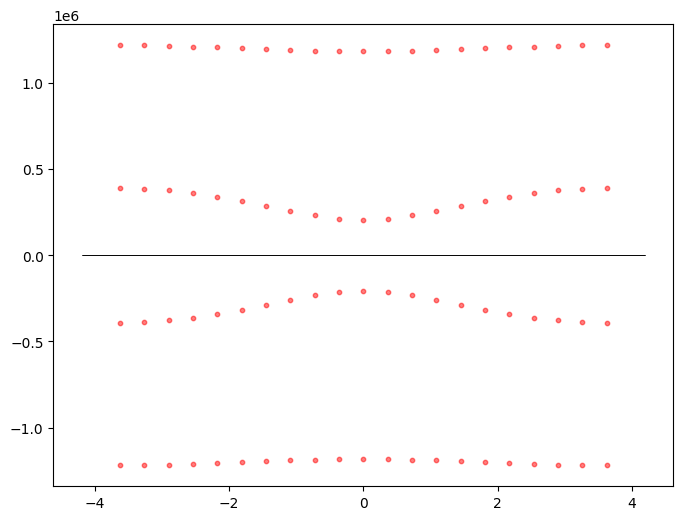

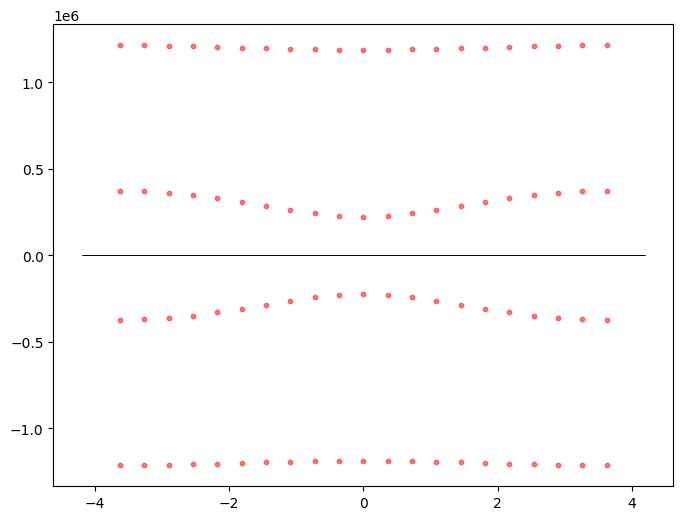

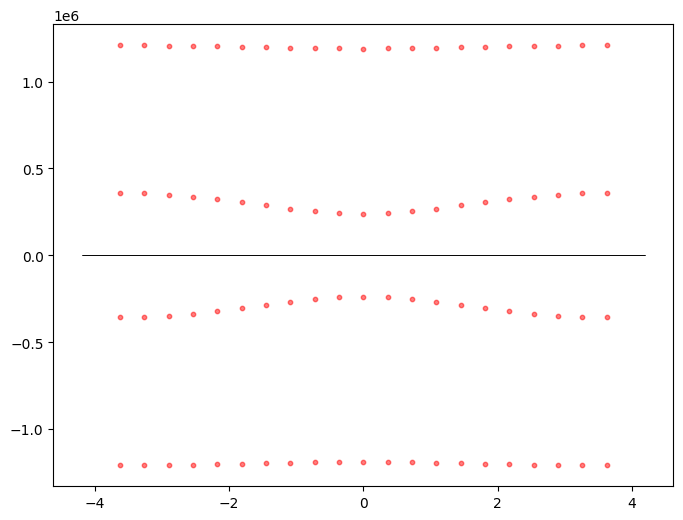

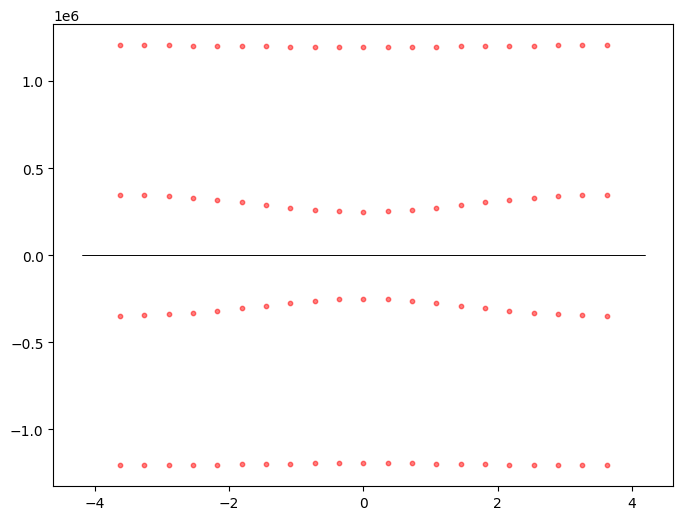

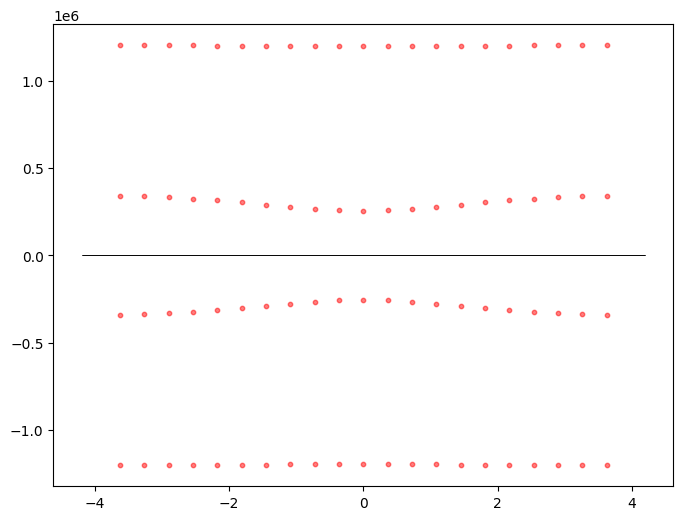

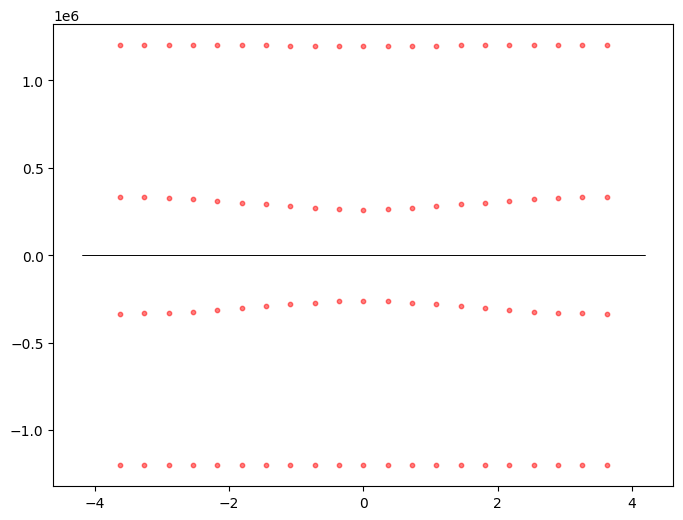

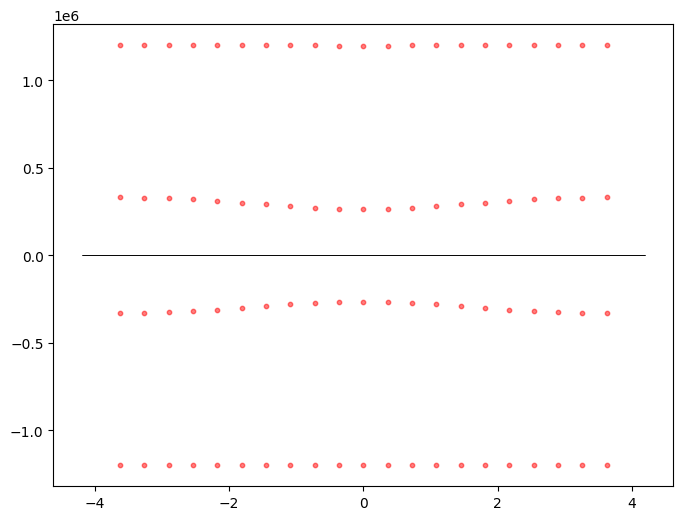

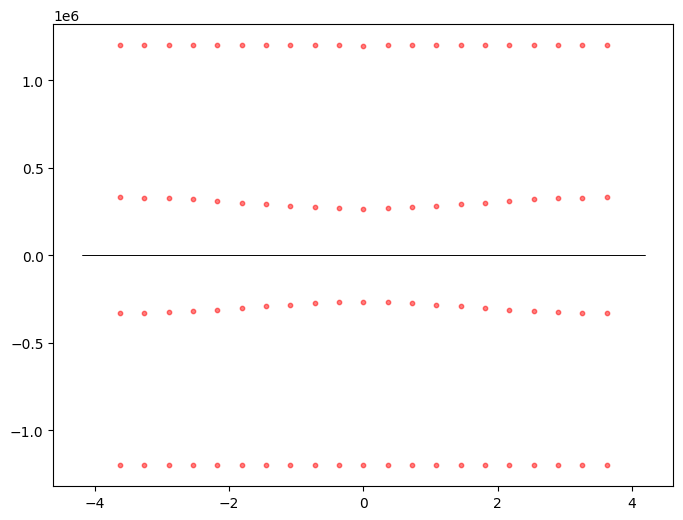

In [ ]:
# fig, ax = plt.subplots(figsize=(8, 6))

k1 = 2*np.pi*np.array([1,0])
grid_size = 20
k_size = grid_size
# def sort_eigenvalues(eigenvalues: np.ndarray,eigenvectors: np.ndarray) -> np.ndarray:
#     """Sort eigenvalues in ascending order."""
#     eigenvectors *= np.conjugate(eigenvectors[0, :])/np.absolute(eigenvectors[0,:])#np.array([np.absolute(eigenvectors[0,i]) for i in range(eigenvectors.shape[1])]) # Normalize the eigenvectors
#     comb = np.column_stack((eigenvalues.T, eigenvectors.T))
#     # return comb
#     sorted_comb = sorted(comb, key=lambda x: x[0])
#     return np.array(sorted_comb)
kx = np.arange(-(k_size//2),k_size//2+1)/k_size*np.linalg.norm(REZI_2)#/k_size * k1[0]
alphas = np.linspace(0, np.pi/2, 20)


def wrap_simple(i,j,grid_sizek,real_grid_size):
    k = i/grid_sizek * k1 
    alpha = alphas[j]
    dmat = D_mat(k,0.5,alpha,bare_interaction,no_onsite_interaction,real_grid_size)
    # print(dmat)
    eigvals, eigvecs = np.linalg.eig(dmat)
    # return sort_eigenvalues(eigvals, eigvecs)
    return sorted(np.real(eigvals[:]))

eigenvals = parallel_for([[-(k_size//2),k_size//2+1],[0,len(alphas)]],wrap_simple,k_size,grid_size).astype(np.complex64)



# for h in range(4):
#     for j in range(len(kx)):
#         ax.scatter(alphas, eigenvals[ j,:,h], color='red', s=10, alpha=0.5)

# plt.show()
# fig, ax = plt.subplots(figsize=(8, 6))
for j in range(len(alphas)):
    fig, ax = plt.subplots(figsize=(8, 6))
    for h in range(4):
        
        ax.scatter(kx, eigenvals[ :,j,h], color='red', s=10, alpha=0.5)
        # ax.hlines(0,-4.2,4.2,colors='0',linewidth=0.4)
        # ax.scatter(kx, eigenvals3[ j,:,h], color='blue', s=10, alpha=0.5)
    plt.show()
# ax.set_xticks([-4.2,0,4.2])


In [78]:
eigenvals[:,:,1]

array([[[-9.55435826e-06+6.1185228e-06j,             nan          +nanj,
                     nan          +nanj,             nan          +nanj,
                     nan          +nanj],
        [-2.27896172e+05-9.6970374e-12j,  4.74031448e-01+3.8146085e-32j,
         -5.24689317e-01-2.9644484e-15j, -2.54392461e-03+4.7416010e-01j,
          2.81427428e-03-5.2455038e-01j],
        [-4.02978000e+05+3.3672398e-11j,  4.50549453e-01+1.7932794e-32j,
         -5.44983983e-01-1.1148467e-15j, -9.65243671e-03+4.5048231e-01j,
          1.16738984e-02-5.4482460e-01j],
        ...,
        [-3.34525969e+05-1.5416132e-11j,  6.97257280e-01+0.0000000e+00j,
         -1.17619395e-01+1.7345915e-17j, -6.74079537e-01+1.7826959e-01j,
          1.13711439e-01-3.0072551e-02j],
        [-3.31531875e+05-3.0710133e-12j,  7.04635799e-01+0.0000000e+00j,
         -5.90716228e-02-1.9717771e-18j, -6.98714316e-01+9.1145739e-02j,
          5.85774370e-02-7.6412978e-03j],
        [-3.30554281e+05-7.0869828e-15j,  7.071